<p style="color: blue; font-size: 45px; text-align: center;"><b>Wypłacalność i zarządzanie ryzykiem w zakładzie ubezpieczeń</b></p>
<p style="color: lightblue; font-size: 30px; text-align: center;">Projekt zaliczeniowy 1: Prognozowanie VaR</p>
<p style="font-size: 20px; text-align: center;">Jakub Pyszniak, Sebastian Rubaj</p>
<p style="font-size: 20px; text-align: center;">Jesień 2025</p>

<p style="font-size: 20px; text-align: center;">Projekt przedstawia oszacowanie i prognozę roczną value at risk dla logarytmicznych stóp zwrotu kursu walutowego EUR/PLN.
Plik przedstawia wstępną analizę danych, badanie efektów ARCH, wybór modelu klasy GARCH, estymację VaR (0.5% oraz 99.5%) in-sample, prognozę VaR (0.5% oraz 99.5%) out-of-sample oraz ostateczną prognozę w horyzoncie rocznym. 
</p>

# Wstęp do analizy

Będziemy estymowali dwa kwantyle ze względu na to, że wzrost EUR/PLN (kwotowanie bezpośrednie) sprawia, że zobowiązania są droższe, ale aktywa w euro wzrastają na wartości. Spadek kursu prowadzi do odwrotnej sytuacji - zobowiązania są tańsze, a aktywa w euro tracą na wartości. Firma zarządzając aktywami i pasywami musi kwantyfikować oba te zachowania kursu, żeby być w stanie lepiej oszacować wpływ na swój portfel

W naszej analizie zajmujemy się estymowaniem VaR dla logarytmicznych stóp zwrotu ze względu na ich pożądane włąściwości matematyczne (addytywność). W sekcji 1 przeprowadzamy eksplorację danych, w sekcji 2 estymujemy adekwatne modele GARCH, w sekcji 3 estymujemy VaR in oraz out-of-sample, w sekcji 4 przeprowadzamy kluczowe prognozy, a w sekcji 5 zwracamy uwagę na najważniejsze ograniczenia badania.




# 0. Załadowanie bibliotek

In [ ]:
# Biblioteki
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Biblioteki statystyczne
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.stats.diagnostic as smd # for Breusch-Godfrey test
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import time

# Modele ARCH/GARCH 
from arch import arch_model
from arch.univariate import ConstantMean, ARX, GARCH, EGARCH, ARCHInMean, StudentsT, Normal

# Styl wykresów
plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_theme(style="whitegrid") # Alternative for seaborn styling

# Opcje wyświetlenia
pd.options.display.float_format = '{:.6f}'.format # pandas DataFrames
np.set_printoptions(suppress=True, precision=6) # numpy arrays

# Ignorowanie ostrzeżeń
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning) # potencjalnie z arch/statsmodels

# 1. Eksploracja danych

**Ważnymi krokami na początku analizy to wybór zakresu danych oraz ich częstotliwości.** Literatura modelowania zmienności kursów walutowych (przy pomocy modeli klasy GARCH) w znacznej części wykorzystuje dane o częstotliwości dziennej. Modele typu GARCH-MIDAS rzeczywiście korzystają z danych makro  o częstotliwości mniejszej (np. miesięcznej), ale odnosi się to do tak zwanych *macro fundamentals* szczególnie *monetary fundemantals* (wspierają analizę poprzez dodanie do estymacji zmiennych innych niż kurs walutowy). Nadal, dane o kursach walutowych w takich modelach pozostają dzienne. 

**Przykładowe prace wykorzystujące dane dzienne:**
* [Sahar Charfi, Farouk Mselmi (2022). Modeling exchange rate volatility: application of GARCH models with a Normal Tempered Stable distribution](https://www.aimspress.com/article/doi/10.3934/QFE.2022009?utm)
* [Yu You, Xiaochun Liu (2020). Forecasting short-run exchange rate volatility with monetary fundamentals: A GARCH-MIDAS approach](https://www.sciencedirect.com/science/article/abs/pii/S0378426620301151?utm)
* [Ozkaya Ata, Altun Omer (2024). Domestic and Global Causes for Exchange Rate Volatility: Evidence From Turkey](https://journals.sagepub.com/doi/10.1177/21582440241243200?icid=int.sj-abstract.citing-articles.1&utm)

**Przykładowa praca wykorzystująca dane miesięczne:**
* [Mubeen Abdur Rehman, Ashfaq Salamat (2021). Modeling exchange rate volatility with GARCH models: A comparison based on a volatility breaks](https://journals.uol.edu.pk/afrj/article/view/886)


Naszym zadaniem jest prognoza VaR w horyzoncie rocznym, ale korzystanie z danych dziennych nie jest przeszkodą. Dzięki łatwej agregacji przy pomocy logarytmicznych stóp zwrotu (*opisane w dalszej części*) będziemy mogli prognozować na rok do przodu (około 251 dni roboczych).

> **Od tej pory analizujemy dane o dziennych kursach walutowych.** 

**Następnie dokonujemy wyboru zakresu danych.**

**Dane o kursach walutowych można znaleźć przeważnie w notowaniach Forex lub w publikacjach banków centralnych (w Polsce NBP).** Ze względu na to, że NBP nie publikuje danych dziennych skorzystamy z bazy danych Stooq, która zbiera notowania Forex.

**Źródło danych: [Strona internetowa Stooq](https://stooq.pl/q/d/?f=19960102&t=20251111&s=eurpln&c=0)**

Dane przedstawiają notowania Forex miesięcznych kursów zamknięcia EURPLN (notowanie bezpośrednie, PLN jako waluta bazowa). Zakres początkowej bazy danych użytej w analizie to 31.01.1996 - 31.10.2025. Analizując kursy walutowe względem PLN zasadne jest skupienie się na szeregach czasowych rozpoczynających się po denominacji złotego w 1995 ze względu na znacząco inną siłę waluty krajowej przed tym wydarzeniem.

## 1.1 Wybór zakresu danych

**Załadowanie danych**

In [1036]:
# Załadowanie dancyh z pliku csv - Stooq
dt_stooq = pd.read_csv('Dane_STOOQ_EUR_dzienny.csv', index_col=0, parse_dates=True)
dt_stooq

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie
Data,,,,
1996-01-02,3.165900,3.165900,3.165900,3.165900
1996-01-03,3.165100,3.165100,3.165100,3.165100
1996-01-04,3.139300,3.139300,3.139300,3.139300
1996-01-05,3.192100,3.192100,3.192100,3.192100
1996-01-08,3.186200,3.186200,3.186200,3.186200
...,...,...,...,...
2025-11-04,4.254580,4.262120,4.253480,4.260770
2025-11-05,4.260730,4.262100,4.250430,4.254860
2025-11-06,4.254850,4.257630,4.248810,4.249760


In [1037]:
# Zmiana nazwy dla wygody

dt_stooq['Kurs']=dt_stooq['Zamkniecie']
dt=dt_stooq

In [1038]:
# Przegląd danych

print("Pierwsze wiersze:")
print(dt.head())
print("\nOstatnie wiersz:")
print(dt.tail())
print("\nStruktura danych:")
print(dt.info())

Pierwsze wiersze:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
1996-01-02  3.165900   3.165900   3.165900    3.165900 3.165900
1996-01-03  3.165100   3.165100   3.165100    3.165100 3.165100
1996-01-04  3.139300   3.139300   3.139300    3.139300 3.139300
1996-01-05  3.192100   3.192100   3.192100    3.192100 3.192100
1996-01-08  3.186200   3.186200   3.186200    3.186200 3.186200

Ostatnie wiersz:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2025-11-04  4.254580   4.262120   4.253480    4.260770 4.260770
2025-11-05  4.260730   4.262100   4.250430    4.254860 4.254860
2025-11-06  4.254850   4.257630   4.248810    4.249760 4.249760
2025-11-07  4.249610   4.250830   4.239470    4.239500 4.239500
2025-11-10  4.241090   4.241770   4.232220    4.235230 4.235230

Struktura danych:
<class 'pandas.core.frame.DataFrame'>
DatetimeInd

Mamy 7676 obserwacji i dobrze rozpoznane daty. Spójrzmy na podstawowe statystyki opisowe.

In [1039]:
print("Statystyki opisowe danych Stooq\n", dt)
print("\nŚrednia:", dt['Kurs'].mean())
print("\nOdchylenie standardowe:", dt['Kurs'].std())
print("\nMinimum:", dt['Kurs'].min())
print("1 percentyl:", dt['Kurs'].quantile(0.01))
print("5 percentyl:", dt['Kurs'].quantile(0.05))
print("10 percentyl:", dt['Kurs'].quantile(0.10))
print("25 percentyl:", dt['Kurs'].quantile(0.25))
print("Mediana (50%):", dt['Kurs'].median())
print("75 percentyl:", dt['Kurs'].quantile(0.75))
print("90 percentyl:", dt['Kurs'].quantile(0.90))
print("95 percentyl:", dt['Kurs'].quantile(0.95))
print("99 percentyl:", dt['Kurs'].quantile(0.99))
print("Maksimum:", dt['Kurs'].max())

print("\nSkośność:", stats.skew(dt['Kurs']))
print("Kurtoza (nadwyżkowa):", stats.kurtosis(dt['Kurs']))

Statystyki opisowe danych Stooq
             Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
1996-01-02  3.165900   3.165900   3.165900    3.165900 3.165900
1996-01-03  3.165100   3.165100   3.165100    3.165100 3.165100
1996-01-04  3.139300   3.139300   3.139300    3.139300 3.139300
1996-01-05  3.192100   3.192100   3.192100    3.192100 3.192100
1996-01-08  3.186200   3.186200   3.186200    3.186200 3.186200
...              ...        ...        ...         ...      ...
2025-11-04  4.254580   4.262120   4.253480    4.260770 4.260770
2025-11-05  4.260730   4.262100   4.250430    4.254860 4.254860
2025-11-06  4.254850   4.257630   4.248810    4.249760 4.249760
2025-11-07  4.249610   4.250830   4.239470    4.239500 4.239500
2025-11-10  4.241090   4.241770   4.232220    4.235230 4.235230

[7676 rows x 5 columns]

Średnia: 4.133950085982282

Odchylenie standardowe: 0.3358919679166177

Minimum: 3.1177
1 percentyl: 3.2434
5

Widzimy, że średni kurs wynosi 4.13. Maksimum sięga prawie 5, a minimum prawie 3, co daje nam duży rozrzut. Niemniej patrząc na 99 percentyl widzimy, że obserwacji powyżej 4.77 było bardzo mało. Środkowe 50% obserwacji znajduje się pomiędzy 3.9, a 4.33. Skośność jest ujemna (ale bliska zeru), a kurtoza jest bardzo bliska zera - trudno określić czy kurs pochodzi z rozkładu normalnego. Niemniej w dalszej części analizy i tak będziemy modelować logarytmiczne stopy zwrotu.

Zastanówmy się nad wyborem okresu analizy

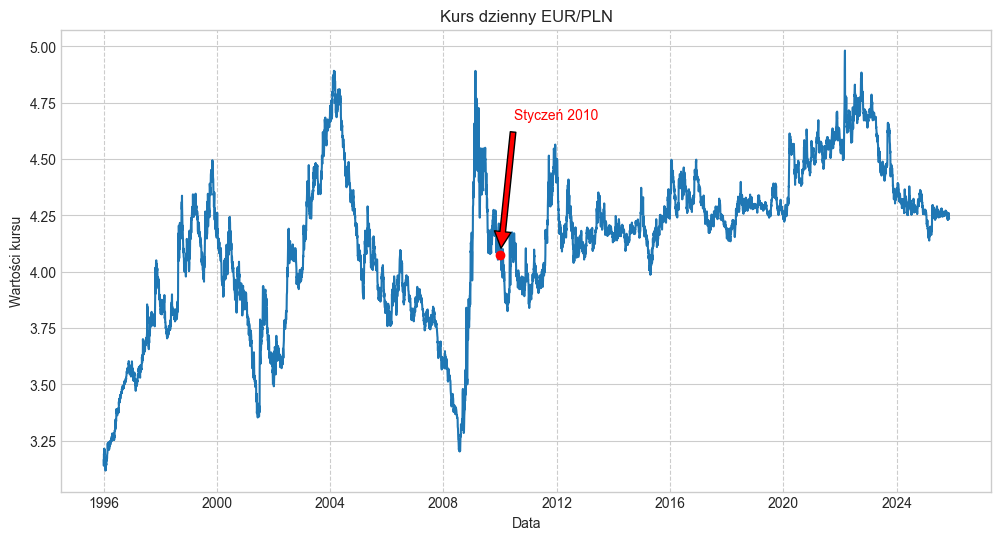

In [1040]:
# Wykres kursu 

# Na wszelki wypadek
dt.index = pd.to_datetime(dt.index)

plt.figure(figsize=(12, 6))
plt.plot(dt.index, dt['Kurs'], label='NBP')

# ----- znacznik 
mask = dt.index.to_period('M') == '2010-01' # odwołujemy się po miesiącu
data_styczen_2010 = dt.index[mask][0]
kurs_styczen_2010 = dt.loc[mask, 'Kurs'].values[0]

# Kropka
plt.scatter(data_styczen_2010, kurs_styczen_2010,
            zorder=5, color='red', label='Wrzesieś 2015')

# Adnotacja ze strzałką
plt.annotate('Styczeń 2010',
             xy=(data_styczen_2010, kurs_styczen_2010),
             xytext=(pd.Timestamp('2010-06-30'), kurs_styczen_2010 + 0.6),
             arrowprops=dict(facecolor='red', shrink=0.05),
             color='red')

plt.title('Kurs dzienny EUR/PLN')
plt.xlabel('Data')
plt.ylabel('Wartości kursu')
#plt.legend(loc='upper left')
plt.grid(True, which='major', axis='x', linestyle='--')
plt.show()


**Denominacja złotego nastąpiła w 1995, dlatego zaczynamy nasz szereg czasowy od 1996.** Szereg ogólnie cechuje się duża zmiennością. Okres od 1996 do 2004 może być mniej reprezentatywny w naszej analizie ze względu na licze transformacje ekonomiczne w Polsce. Widzimy tutaj największą zmienność co do wartości kursu - duże spadki i wzrosty. W 2004 Polska przystąpiła do UE, co możemy określić jako etap stanowczego otwarcia na gospodarki zagraniczne. 

**Widzimy znaczący spadek wartości euro w okresie 2004-2008.** Tego typu spadki nie pojawiały się w ciągu ostatniej dekady w żadnym podobnym stopniu. Trudno uznać ten okres za reprezentatywny. W latach 2004-2008 Polska była atrakcyjną destynacją dla inwestorów zagranicznych do tego panował powszechny optymizm finansowy w zakresie rozwoju gospodarek światowych. Polska w tamtym okresie miała również stosunkowo wysokie stopy procentowe.

**W latach 2008-2010** mamy do czynienia z bezpośrednimi efetkami kryzysu finansowego. Trudno się spodziewać, że tak duże wzrosty jak na wykresie są reprezentatywne pod kątem prognoz na przyszłość.

Dalej możemy spojrzeć na kryzys inflacyjny strefy euro w 2012 czy inne dalsze zdarzenia, ale wydaję się, że nie ma aż tak dużych wskazań do zawężania próbki jeszcze bardziej. Nie uwzględnienie różnorodnych okresów w ogólne w analizie sprawi, że model nie ma podstaw do nauczenia się jak prognozować takie okresy w przyszłości. Pozbywamy się zatem znacząco odstających "starych" okresów.

> **Wybieramy styczeń 2010 jako początek naszego szeregu i październik 2025 jako koniec**

In [1041]:
# Zawężamy zakres danych: 2010.01 - 2025.09

dt = dt.loc['2010-01':'2025-09']

print("Pierwsze wiersze:")
print(dt.head())
print("\nOstatnie wiersz:")
print(dt.tail())
print("\nStruktura danych:")
print(dt.info())

# Mamy 200 obesrwacji

Pierwsze wiersze:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2010-01-04  4.104100   4.115600   4.068400    4.075100 4.075100
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800

Ostatnie wiersz:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2025-09-24  4.258900   4.270830   4.258210    4.268240 4.268240
2025-09-25  4.268240   4.275470   4.258720    4.271500 4.271500
2025-09-26  4.272270   4.274080   4.264140    4.267510 4.267510
2025-09-29  4.268720   4.272390   4.263810    4.269160 4.269160
2025-09-30  4.269210   4.273730   4.261670    4.265890 4.265890

Struktura danych:
<class 'pandas.core.frame.DataFrame'>
DatetimeInd

W zawężonej próbce mamy 4069 obserwacji. Nowy wykres:

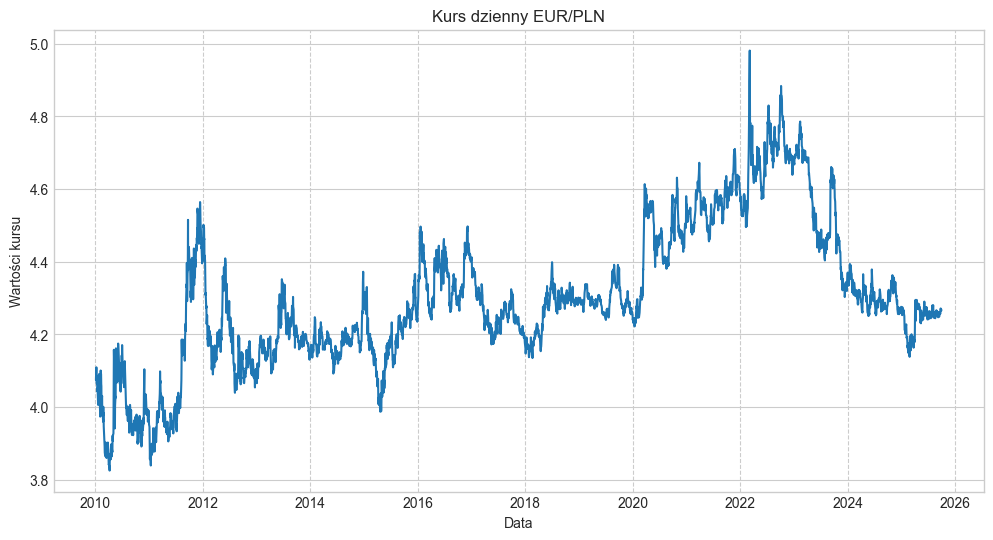

In [1042]:
# Wykres kursu

plt.figure(figsize=(12, 6))
plt.plot(dt.index, dt['Kurs'], label='NBP')

plt.title('Kurs dzienny EUR/PLN')
plt.xlabel('Data')
plt.ylabel('Wartości kursu')
#plt.legend(loc='upper left')
plt.grid(True, which='major', axis='x', linestyle='--')
plt.show()

### 1.1.1 Podział na zbiór treningowy i testowy

**Jako że naszym celem jest prognoza VaR, podzielimy standardowo nasz szereg czasowy na zbiór treningowy i testowy. Skorzystamy z dosyć prostego podziału na 80/20**, gdzie 80% obserwacji (zaczynając od najwcześniejszej) jest zbiorem treningowym, a pozostałe 20% obserwacji jest zbiorem testowym, który będzie nam służył do oceny naszych predykcji.

W dalszej części przy testowaniu out-of-sample modeli przeprowadzimy procedurę *rolling cross-validation* w pewnym zakresie. Będziemy zaczynać od naszej próbki treningowej i zwiększać ją o jedną obserwacje wykonując prognozy każdorazowo estymując wybrany model. Taka procedura sprawdza czy model konsekwentnie prognozuje przy zmieniającej się próbce.

In [1043]:
n = len(dt)
n_train = int(n * 0.8)

# Podział 80/20
dt_train = dt.iloc[:n_train]
dt_test = dt.iloc[n_train:]

print("Rozmiar zbioru treningowego:", len(dt_train))

print("Pierwsze wiersze:")
print(dt_train.head())
print("\nOstatnie wiersz:")
print(dt_train.tail())
print("\nStruktura danych:")
print(dt_train.info())

Rozmiar zbioru treningowego: 3255
Pierwsze wiersze:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2010-01-04  4.104100   4.115600   4.068400    4.075100 4.075100
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800

Ostatnie wiersz:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370

Struktura danych:
<class 'pandas.

In [1044]:
print("Rozmiar zbioru testowego:", len(dt_test))

print("Pierwsze wiersze:")
print(dt_test.head())
print("\nOstatnie wiersz:")
print(dt_test.tail())
print("\nStruktura danych:")
print(dt_test.info())

Rozmiar zbioru testowego: 814
Pierwsze wiersze:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2022-08-08  4.712950   4.714640   4.693580    4.697440 4.697440
2022-08-09  4.696980   4.711330   4.696370    4.700610 4.700610
2022-08-10  4.700980   4.716830   4.669600    4.676820 4.676820
2022-08-11  4.677150   4.688920   4.666240    4.685870 4.685870
2022-08-12  4.685870   4.689940   4.654940    4.659340 4.659340

Ostatnie wiersz:
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs
Data                                                           
2025-09-24  4.258900   4.270830   4.258210    4.268240 4.268240
2025-09-25  4.268240   4.275470   4.258720    4.271500 4.271500
2025-09-26  4.272270   4.274080   4.264140    4.267510 4.267510
2025-09-29  4.268720   4.272390   4.263810    4.269160 4.269160
2025-09-30  4.269210   4.273730   4.261670    4.265890 4.265890

Struktura danych:
<class 'pandas.core

Przy 4069 obserwacjach dostajemy 3255 obserwacji treningowych i 814 testowych.

> **Możemy też od razu sprawdzić czy szereg wartości kursu walutowego jest stacjonarny**, chociaż wykres w tam zakresie jest raczej jednoznaczny. 

W tym celu skorzystamy ze specjalnej funkcji *adf* w pythonie do przeprowadzenia *Augmented Dickey Fuller test*. Funkcja zaczęrpnięta z zajęć *Time Series Analysis* (2025 semestr letni) prowadzonych przez doktora Pawła Sakowskiego i doktora Macieja Świtałę. Implementacje z bibliotek w pythonie zdarza się, że pomijają testowanie autokorelacji na augmentacjach, co prowadzi do błędnego wnioskowania na podstawie testu ADF. Funkcja, z której będziemy korzystać w poprawny sposób prowadzi przez procedurę testowania.

In [1045]:
def adf_test(series, max_aug=15, version='c'):
    
    results = []

    y = series.diff()
    X = pd.DataFrame({'y_lag': series.shift()})

    if version == 'c' or version == 't': # constant to be added optionally 
        X = sm.add_constant(X)
    if version == 't': # (deterministic) trend component to be added optionally
        X['trend'] = range(len(X))

    for i in range(0, max_aug): # iterating through different numbers of augmentations
        
        for aug in range(1, i+1): # adding augmentations max_aug is reached
            X['aug_'+str(aug)] = y.shift(aug)

        model = sm.OLS(series.diff(), X, missing='drop').fit() # fitting a linear regression with OLS

        ts = model.tvalues['y_lag'] # test statistic
        nobs = model.nobs # number of observations

        if version == 'n': # critical values for basic version of ADF
            if nobs > 100:
                cv01 = -2.567; cv05 = -1.941; cv10 = -1.616 # critical values for more than 500 observations
            else:
                cv01 = np.nan; cv05 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually
        if version == 'c': # critical values for version with constant
            if nobs > 100:
                cv01 = -3.434; cv05 = -2.863; cv10 = -2.568 # critical values for more than 500 observations
            else:
                cv01 = np.nan; cv05 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually
        if version == 't': # critical values for version with constant and (deterministic) trend component
            if nobs > 100:
                cv01 = -3.963; cv05 = -3.413; cv10 = -3.128 # critical values for more than 500 observations
            else:
                cv01 = np.nan; cv05 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually

        bg_test01 = smd.acorr_breusch_godfrey(model, nlags=1);  bg_pvalue01 = round(bg_test01[1],4); bg_test01 = round(bg_test01[0],4); 
        bg_test05 = smd.acorr_breusch_godfrey(model, nlags=5);  bg_pvalue05 = round(bg_test05[1],4); bg_test05 = round(bg_test05[0],4); 
        bg_test10 = smd.acorr_breusch_godfrey(model, nlags=10); bg_pvalue10 = round(bg_test10[1],4); bg_test10 = round(bg_test10[0],4);
        bg_test15 = smd.acorr_breusch_godfrey(model, nlags=15); bg_pvalue15 = round(bg_test15[1],4); bg_test15 = round(bg_test15[0],4);

        results.append([i, ts, cv01, cv05, cv10, 
                        bg_test01, bg_pvalue01, bg_test05, bg_pvalue05, bg_test10, bg_pvalue10, bg_test15, bg_pvalue15])

    results_df = pd.DataFrame(results)
    results_df.columns = ['number of augmentations', 
                          'ADF test statistic', 'ADF critical value (1%)', 'ADF critical value (5%)', 'ADF critival value (10%)', 
                          'BG test (1 lag) (statistic)', 'BG test (1 lag) (p-value)', 
                          'BG test (5 lags) (statistic)', 'BG test (5 lags) (p-value)', 
                          'BG test (10 lags) (statistic)', 'BG test (10 lags) (p-value)', 
                          'BG test (15 lags) (statistic)', 'BG test (15 lags) (p-value)']
    
    return results_df

**Interpretacja testów:** 

**Test ADF** 

**H0**: zmienna jest niestacjonarna (co najmniej I(1)) 

**H1**: zmienna jest stacjonarna

Jeśli wartość statystyki testowej ADF jest powyżej (większa) od wartości krytycznej ADF, to nie odrzucamy H0. Zmienna jest niestacjonarna. Jeśli wartość statystyki testowej ADF jest poniżej (mniejsza od) wartości krytycznej ADF, to odrzucamy H0. Zmienna jest stacjonarna.


**Test BG** 

**H0**: nie ma autokorelacji (do liczby równej rzędowi opóźnień reszt) 

**H1**: występuje autokorelacja (do liczby równej rzędowi opóźnień reszt)

W celu uniknięcia uzyskania nieefektywnych estyamtorów w teście ADF, musimy sprawdzić czy pomiędzy resztami nie występuje autokorelacja. Jęsli występuje, dodajemy augmentacje aż usuniemy autokorelacje i wtedy patrzymy na wartość statystyki ADF. Przeważnie też chcemy brać pod uwagę najmniejszą możliwą liczbę augmentacji. Jeśli widzimy, że autokorelacja zanika przy konkretnej liczbie augmentacji a później wraca to wybieramy te najmniejszą liczbę augmentacji, która zapewnia nam brak autokorelacji.

In [1046]:
# Testujemy stacjonarność

adf_test(dt_train['Kurs'])

,number of augmentations,ADF test statistic,ADF critical value (1%),ADF critical value (5%),ADF critival value (10%),BG test (1 lag) (statistic),BG test (1 lag) (p-value),BG test (5 lags) (statistic),BG test (5 lags) (p-value),BG test (10 lags) (statistic),BG test (10 lags) (p-value),BG test (15 lags) (statistic),BG test (15 lags) (p-value)
0,0,-2.557479,-3.434000,-2.863000,-2.568000,-0.510900,1.000000,11.644800,0.040000,18.728400,0.043900,23.681200,0.070700
1,1,-2.544246,-3.434000,-2.863000,-2.568000,0.091400,0.762400,11.669100,0.039600,18.638500,0.045100,23.597600,0.072300
2,2,-2.355094,-3.434000,-2.863000,-2.568000,0.987200,0.320400,7.744400,0.170900,13.574200,0.193300,18.445500,0.240000
3,3,-2.281653,-3.434000,-2.863000,-2.568000,-4.875700,1.000000,5.365300,0.372900,12.115600,0.277400,17.036600,0.316700
4,4,-2.303125,-3.434000,-2.863000,-2.568000,0.060800,0.805200,3.662300,0.599000,10.275800,0.416600,15.398400,0.423100
5,5,-2.323904,-3.434000,-2.863000,-2.568000,0.769300,0.380400,4.317900,0.504600,15.955100,0.100900,19.959200,0.173500
6,6,-2.270926,-3.434000,-2.863000,-2.568000,0.012300,0.911600,5.575700,0.349700,21.114600,0.020300,23.320500,0.077600
7,7,-2.226864,-3.434000,-2.863000,-2.568000,-0.719100,1.000000,10.884700,0.053700,12.606600,0.246500,23.827000,0.068100
8,8,-2.251539,-3.434000,-2.863000,-2.568000,0.958400,0.327600,12.214400,0.032000,17.612700,0.061900,23.751900,0.069400
9,9,-2.171762,-3.434000,-2.863000,-2.568000,-5.882900,1.000000,15.494800,0.008400,19.855700,0.030600,21.948600,0.109200


Widzimy, że potrzebujemy 2 augmentacji, żeby usunąć autokorelacje (p-value większe od poziomu istotności 5% dla wszystkich opóźnień w teście BG). Niestety wszystkie wartości testowe ADF są powyżej wartości krytycznych -> **zmienna jest niestacjonarna**.

In [1047]:
# Sprawdźmy pierwsze różnice

adf_test(dt_train['Kurs'].diff())

,number of augmentations,ADF test statistic,ADF critical value (1%),ADF critical value (5%),ADF critival value (10%),BG test (1 lag) (statistic),BG test (1 lag) (p-value),BG test (5 lags) (statistic),BG test (5 lags) (p-value),BG test (10 lags) (statistic),BG test (10 lags) (p-value),BG test (15 lags) (statistic),BG test (15 lags) (p-value)
0,0,-57.080508,-3.434000,-2.863000,-2.568000,0.157800,0.691200,12.852100,0.024800,20.924100,0.021600,25.682700,0.041500
1,1,-42.795625,-3.434000,-2.863000,-2.568000,1.005600,0.316000,8.099800,0.150800,14.920400,0.135000,19.538300,0.190400
2,2,-34.887095,-3.434000,-2.863000,-2.568000,1.109700,0.292200,5.423500,0.366400,13.149300,0.215400,17.808800,0.272900
3,3,-29.909863,-3.434000,-2.863000,-2.568000,0.040400,0.840800,3.912300,0.562100,11.266500,0.337100,16.157600,0.371700
4,4,-26.363579,-3.434000,-2.863000,-2.568000,0.935500,0.333400,4.747600,0.447500,16.623400,0.083100,20.705000,0.146500
5,5,-24.245558,-3.434000,-2.863000,-2.568000,-10.751300,1.000000,6.035600,0.302800,21.831500,0.016000,23.920200,0.066500
6,6,-22.830961,-3.434000,-2.863000,-2.568000,-0.224800,1.000000,10.128600,0.071700,12.537700,0.250700,24.344400,0.059500
7,7,-21.073913,-3.434000,-2.863000,-2.568000,0.480000,0.488400,12.220100,0.031900,17.301000,0.068000,24.497700,0.057100
8,8,-20.245010,-3.434000,-2.863000,-2.568000,-5.462600,1.000000,13.752100,0.017300,19.560800,0.033700,22.338500,0.099200
9,9,-19.756448,-3.434000,-2.863000,-2.568000,0.313200,0.575700,1.960700,0.854600,16.448400,0.087500,22.907200,0.086100


Tutaj sytuacja jest jasna. Potrzebujemy jedną augmentację (p-value większe od 5% dla testów BG) oraz wartość statysytki ADF jest poniżej poziomu krytycznego (wiersz 1) -> **zmienna jest stacjonarna**. 
>**Zatem nasza zmienna kurs jest zintegrowana poziomu 1. Kurs ~ I(1)**

### 1.1.2 Logarytmiczne stopy zwrotu

**Niemniej w celach analitycznych i porównawczych częściej analizuje się stopy zwrotu kursów walutowych, a  dokładniej logarytmiczne stopy zwrotu.** Logarytmiczne stopy zwrotu w przeciwieństwie do zwykłych stóp zwrotu są addytywne, co ułatwia analizę (kluczowe dla ostatecznej prognozy w horyzoncie rocznym: sekcja 4).

Logarytmiczna stopa zwrotu $r_t$:
$$r_t = \Delta \log P_t = \log P_t - \log P_{t-1} = \log ( \frac{P_{t}} {P_{t-1}})$$
więc (przejście na wartości kursu):
$$P_{t} = P_{t-1} e^{r_t}$$
dodatkowo (addytywność):
$$r_t = \log ( \frac{P_{t}} {P_{t-1}}) = \log ( \frac{P_{t}} {P_{t-1}} \frac{P_{t-1}} {P_{t-2}}...\frac{P_{t-k+1}} {P_{t-k}}) = r_t +r_{t-1} + ... + r_{t-k+1}$$

In [1048]:
# Logarytmiczne stopy zwrotu

dt_train = dt_train.copy() # dla uciszenia warnings

dt_train['r'] = np.log(dt_train['Kurs']).diff()
dt_train

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2010-01-04,4.104100,4.115600,4.068400,4.075100,4.075100,NaN
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953
...,...,...,...,...,...,...
2022-08-01,4.742740,4.752490,4.707540,4.716780,4.716780,-0.004885
2022-08-02,4.716380,4.738870,4.702980,4.731720,4.731720,0.003162
2022-08-03,4.731730,4.736350,4.689230,4.697850,4.697850,-0.007184


In [1049]:
# Usuwamy NaN powstały z utworzenia stóp zwrotu
dt_train=dt_train.dropna()

Spójrzmy na podstawowe statystyki opisowe dla logarytmicznych stóp zwrotu

In [1050]:
print("Statystyki opisowe danych Stooq\n", dt_train)
print("\nŚrednia:", dt_train['r'].mean())
print("\nOdchylenie standardowe:", dt_train['r'].std())
print("\nMinimum:", dt_train['r'].min())
print("1 percentyl:", dt_train['r'].quantile(0.01))
print("5 percentyl:", dt_train['r'].quantile(0.05))
print("10 percentyl:", dt_train['r'].quantile(0.10))
print("25 percentyl:", dt_train['r'].quantile(0.25))
print("Mediana (50%):", dt_train['r'].median())
print("75 percentyl:", dt_train['r'].quantile(0.75))
print("90 percentyl:", dt_train['r'].quantile(0.90))
print("95 percentyl:", dt_train['r'].quantile(0.95))
print("99 percentyl:", dt_train['r'].quantile(0.99))
print("Maksimum:", dt_train['r'].max())

print("\nSkośność:", stats.skew(dt_train['r']))
print("Kurtoza (nadwyżkowa):", stats.kurtosis(dt_train['r']))

Statystyki opisowe danych Stooq
             Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r
Data                                                                     
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100  0.003674
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000  0.000709
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500  0.004023
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800 -0.009953
2010-01-11  4.057400   4.069400   4.040300    4.063300 4.063300 -0.001353
...              ...        ...        ...         ...      ...       ...
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875

[325

Najciekawszą potencjalnie kwestią jest tutaj duża kurtoza, która wskazuje na lepkourtyczność rozkładu empiryczngo logarytmicznych stóp zwrotu, co jest powszechnym zjawiskiem w praktyce dla tego typu danych finansowych. Widzimy, że nasze dane raczej nie będą modelowane dobrze rozkładem normalnym.

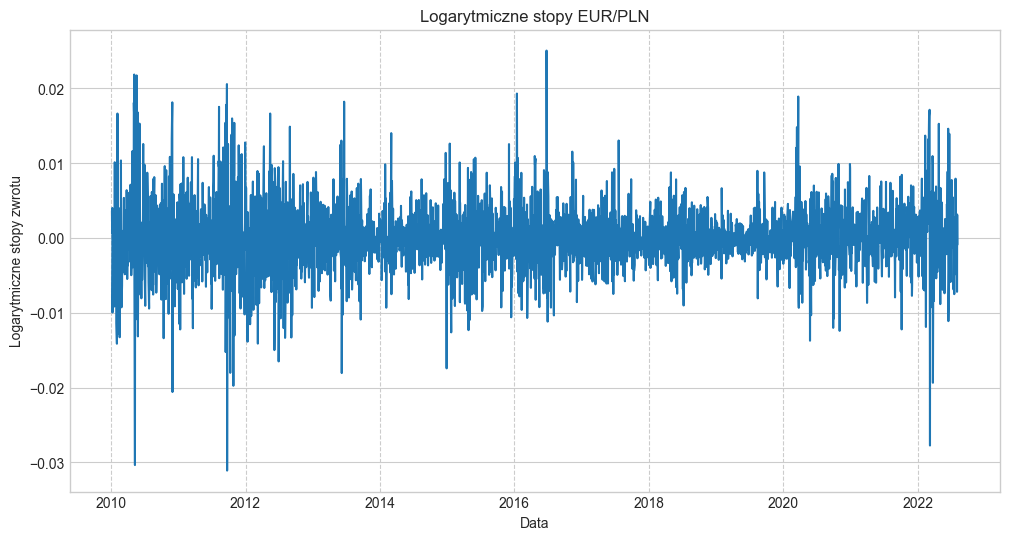

In [1051]:
# Wykres kursu NBP

plt.figure(figsize=(12, 6))
plt.plot(dt_train.index, dt_train['r'], label='NBP')

plt.title('Logarytmiczne stopy EUR/PLN')
plt.xlabel('Data')
plt.ylabel('Logarytmiczne stopy zwrotu')
#plt.legend(loc='upper left')
plt.grid(True, which='major', axis='x', linestyle='--')
plt.show()

**Widzimy wiele skupisk dużej zmienności** (jeden z tak zwanych *ARCH effects*) a pośród nich odstające nagłe "wystrzały" zmienności (przykładowo: 3 takie widzimy pomiędzy 2010 a 2012). Klastry mniejszej zmienności są, przykładowo, pomiędzy 2017 a 2020.


Przetestujmy stacjonarność tego szeregu:

In [1052]:
adf_test(dt_train['r'])

,number of augmentations,ADF test statistic,ADF critical value (1%),ADF critical value (5%),ADF critival value (10%),BG test (1 lag) (statistic),BG test (1 lag) (p-value),BG test (5 lags) (statistic),BG test (5 lags) (p-value),BG test (10 lags) (statistic),BG test (10 lags) (p-value),BG test (15 lags) (statistic),BG test (15 lags) (p-value)
0,0,-56.997796,-3.434000,-2.863000,-2.568000,0.001500,0.968700,14.070400,0.015200,21.212200,0.019700,26.664800,0.031600
1,1,-42.830806,-3.434000,-2.863000,-2.568000,0.964000,0.326200,9.001800,0.109000,15.047000,0.130400,20.440600,0.155700
2,2,-34.987910,-3.434000,-2.863000,-2.568000,0.599400,0.438800,6.078800,0.298600,12.892500,0.229700,18.321200,0.246200
3,3,-30.158075,-3.434000,-2.863000,-2.568000,-0.583000,1.000000,4.307300,0.506100,10.455700,0.401500,16.203400,0.368700
4,4,-26.660729,-3.434000,-2.863000,-2.568000,-63.785300,1.000000,4.904900,0.427600,16.135100,0.095800,21.475400,0.122300
5,5,-24.429455,-3.434000,-2.863000,-2.568000,-6.492000,1.000000,5.912300,0.314800,22.645300,0.012100,25.261400,0.046500
6,6,-22.917902,-3.434000,-2.863000,-2.568000,-0.903200,1.000000,10.982200,0.051700,14.696500,0.143500,26.189700,0.036100
7,7,-21.113820,-3.434000,-2.863000,-2.568000,0.870200,0.350900,13.393200,0.020000,19.298400,0.036600,26.216500,0.035800
8,8,-20.314902,-3.434000,-2.863000,-2.568000,-5.450300,1.000000,16.796000,0.004900,20.830300,0.022300,23.894700,0.066900
9,9,-19.750309,-3.434000,-2.863000,-2.568000,0.373500,0.541100,3.037100,0.694300,19.088900,0.039100,25.489100,0.043700


Widzimy, że potrzebujemy jednej augmentacji (p-value w testach BG jest powyżej 5% dla jednej augmentacji), żeby usunąć autokorelację. Statystyka testowa ADF dla jednej augmentacji jest poniżej wartości krytycznych -> **zmienna jest stacjonarna**. Logarytmiczna stopa zwrotu: **r ~ I(0)**. Zatem możemy korzystać z tej zmiennej do wstępnego budowania modeli GARCH (chcemy uniknąć tak zwanego *spurious regression*). Niemniej w dalszym procesie modelowania i tak będziemy wybierać modele, które są zbieżne algorytmicznie i produkują *sensowne* wariancje.

## 1.2 Efekty GARCH
<a id="efekty-garch"></a>

Standardowo wyróżnia się tak zwane **GARCH effects** widoczne w szeregu czasowym, które wskazują na problem z warunkową heteroskedastycznością składnika losowego (przykładowo w bazowym modelu typu ARIMA). 

* Do tej pory spojrzeliśmy na **klastrowanie** (skupiska) - małe i duże zmiany w cenie aktywa (u nas kurs walutowy) grupują się. Powinniśmy zauważyć wiele małych zmian blisko siebie i oddzielnie wiele dużych zmian blisko siebie. Częściowo nasz szereg wykazuje takie zachowanie.

* Kolejnym efektem jest **leverage effect** - tendencja wariancji do większego wzrostu przy spadku wartości aktywa niż przy takim samym wzroście (co do wartości bezweględnej) wartości aktywa. W przypadku kursów walutowych sytuacja jest nieco utrudniona, ponieważ gdy jedna waluta względnie się umacnia to druga względnie się osłabia. W naszej analizie *leverage effect* będziemy badali przypomocy rozszerzeń modeli GARCH, które uwzględniają **asymetryczną warunkową wariancję.**

* Trzecim efektem jest **leptokurtoza** rozkładu stóp zwrotu. Powinniśmy widzieć więcej wartości skupionych przy średniej i grubsze ogony w porównaniu do rozkładu normalnego. Badaniem tego efektu zajmujemy się poniżej.

**Dalej spojrzymy też na wykresy autokorelacji reszt i kwadratów reszt.**

In [1053]:
dt_train

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353
...,...,...,...,...,...,...
2022-08-01,4.742740,4.752490,4.707540,4.716780,4.716780,-0.004885
2022-08-02,4.716380,4.738870,4.702980,4.731720,4.731720,0.003162
2022-08-03,4.731730,4.736350,4.689230,4.697850,4.697850,-0.007184


In [1054]:
# Przypomnijmy podstawowe statystyki opisowe

print("Podstawowe statystyki opisowe:")
print(dt_train['r'].describe())
print("\nSkewness:", stats.skew(dt_train['r']))
print("Kurtosis:", stats.kurtosis(dt_train['r'])) #excess kurtosis

Podstawowe statystyki opisowe:
count   3254.000000
mean       0.000044
std        0.004508
min       -0.031085
25%       -0.002271
50%       -0.000087
75%        0.002323
max        0.025064
Name: r, dtype: float64

Skewness: 0.06205057338426668
Kurtosis: 4.1269409278505975


Widzimy **dodatnią skośność oraz dodatnią nadwyżkową kurtozę** - oba parametry są równe 0 dla rozkładu normalnego. Prawdopodobnie naszych zwrotów nie da się dobrze modelować rozkładem normalnych. Przetestujmy to testem Jarque-Bery. Najpierw spójrzmy na histogram zwrotów.

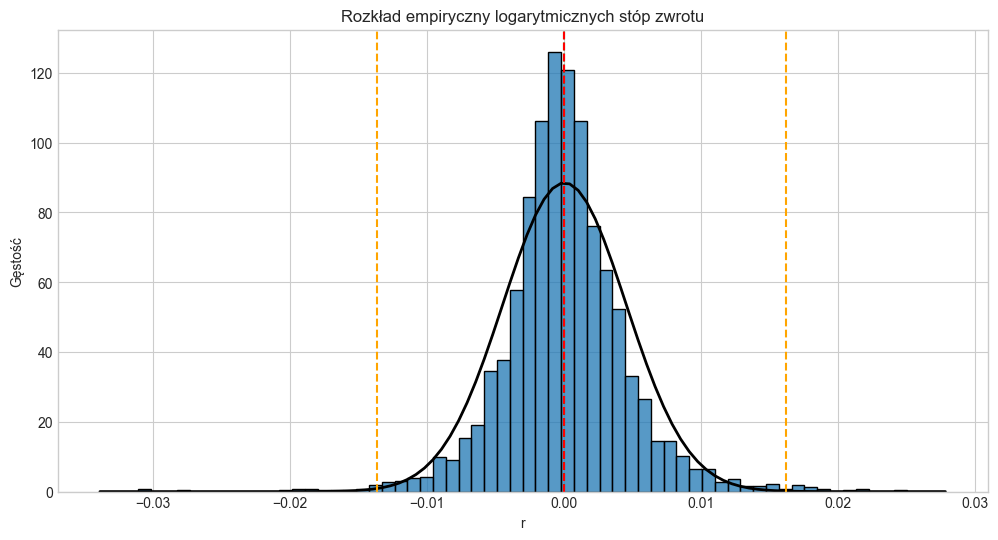

In [1055]:
# Histogram logarytmicznych stóp zwrotu
plt.figure(figsize=(12, 6))
sns.histplot(dt_train['r'], stat="density", bins = 60)

# Krzywa gęstości rozkładu normalnego
mu, std = dt_train['r'].mean(), dt_train['r'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('r')
plt.ylabel('Gęstość')
plt.axvline(x=0, linestyle='--', color='green')
plt.axvline(x=dt_train['r'].mean(), linestyle='--', color='red')
plt.axvline(x=dt_train['r'].quantile(0.005), linestyle='--', color='orange')
plt.axvline(x=dt_train['r'].quantile(0.995), linestyle='--', color='orange')
plt.title('Rozkład empiryczny logarytmicznych stóp zwrotu')
plt.show()

Przerywane linie pomarańczowe wyznaczają kwantyle empiryczne 0.005 i 0.995. Przerywana linia czerwona wskazuje średnią empiryczna, a zielona wskazuje wartość 0 (średnią standardowego rozkładu normalnego). Czarna krzywa obrazuje rozkład normalny a histogram nasz empiryczny rozkład logarytmicznych stóp zwrotu.

Widzimy dosyć znaczącą leptokurtozę rozkładu empirycznego. Dodatkowo, średnie dla obu rozkładów są prawie takie same.

Dla porównania poniżej mamy próbkę wylosowaną z rozkład normalnego:

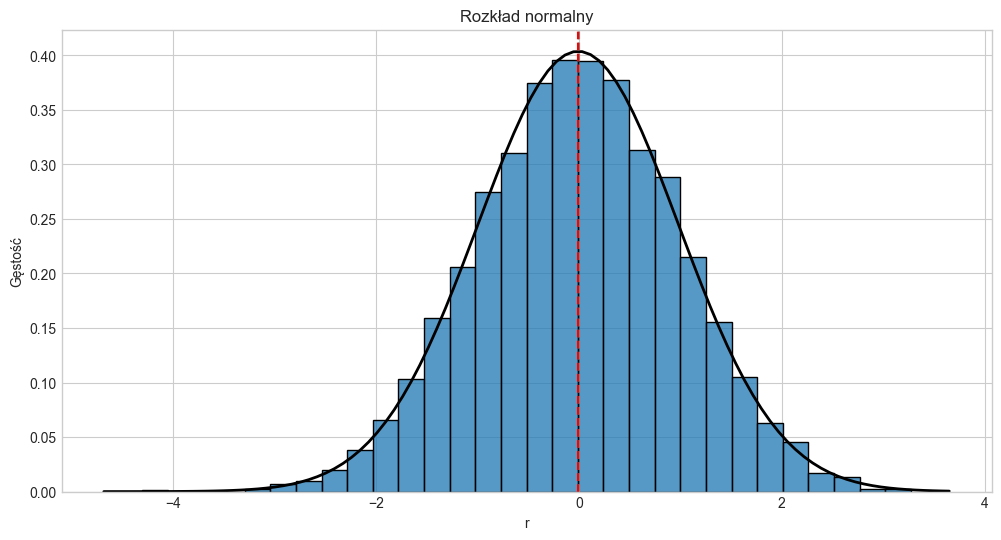

Średnia: -0.006082973365815351 
Odchylenie standardowe: 0.9880460755430074


In [1164]:
N = dt_train.shape[0]
z = stats.norm.rvs(size=N)
plt.figure(figsize=(12, 6))
sns.histplot(z, stat="density", bins = 30)

# add normal distribution curve
mu, std = z.mean(), z.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('r')
plt.ylabel('Gęstość')
plt.axvline(x=0, linestyle='--', color='gray')
plt.axvline(x=z.mean(), linestyle='--', color='red')
plt.title('Rozkład normalny')
plt.show()


print("Średnia:", z.mean(), "\nOdchylenie standardowe:", z.std())

Widzimy jak wygląda wygenerowany rozkład normalny. Skorzystajmy z testu JB.

**Interpretacja testu:** 

**Test Jarque-Bery** 

**H0**: próbka pochodzi z rozkładu normalnego (skośność i nadwyżkowa kurtoza równa 0)

**H1**: próka nie pochodzi z rozkładu normalnego

Jeśli p-value jest mniejsze od zadanego poziomu istotności, to odrzucamy H0 -> rozkład nie jest normalny. Jeśli p-value jest większe od zadanego poziomu istotności, to nie odrzucamy H0 -> rozkład jest normalny.



In [1057]:
# Test Jarque-Bera
jb_test = stats.jarque_bera(dt_train['r'].dropna())
print(f"Statystyka testowa Jarque-Bera: {jb_test[0]:.2f}")
print(f"p-value: {jb_test[1]:.2e}")


jb_test_z = stats.jarque_bera(z)
print(f"Statystyka testowa Jarque-Bera dla ~N(0,1): {jb_test_z[0]:.2f}")
print(f"p-value: {jb_test_z[1]:.2e}")


Statystyka testowa Jarque-Bera: 2311.29
p-value: 0.00e+00
Statystyka testowa Jarque-Bera dla ~N(0,1): 2.34
p-value: 3.11e-01


Test jest przeprowadzany na ostatnim losowaniu zmiennej *z*, więc należy uważać na wywoływanie kodu. Celowo nie ustawiamy ziarna losowania w celu sprawdzenia czułości testu na różne losowania. 

**Widzimy, że dla naszych stóp zwrotu test JB odrzuca H0 na poziomie istotności 5% -> stopy zwrotu nie pochodzą z rozkładu normalnego. Test nie odrzuca H0 dla próbki, która została wylosowana z rozkładu normalnego** (taka sama wielkość próbki jak stóp zwrotu dla lepszego porównania działania testu). Test potwierdza nasze oczekiwania.

Przy tak dużej próbce raczej nasz test JB nie powinien się cechować małą mocą (większy problem przy małych próbkach), ale można sprawdzić poniżej jak zmienia się p-value dla przy różnych losowaniach próbki z rozkładu normalnego. Spodziewamy się nieodrzucenia H0.

In [1058]:
# Próbujemy losować od nowa. Ze względu na nienajlepszą moc testu możemy popełniać Type I error
    # i odrzucać H0, kiedy jest prawdziwa
# Wartość krytyczna to około 6

z = stats.norm.rvs(size=N)
jb_test_z = stats.jarque_bera(z)
print(f"Jarque-Bera test statistic for ~N(0,1): {jb_test_z[0]:.2f}")
print(f"p-value: {jb_test_z[1]:.2e}")

# Może się zdarzyć, że odrzucimy H0 dla niektórych losowań:
    # Jarque-Bera test statistic for ~N(0,1): 6.15
    # p-value: 4.61e-02


Jarque-Bera test statistic for ~N(0,1): 0.56
p-value: 7.57e-01


Dla kompletności spójrzmy jeszcze na QQ-ploty

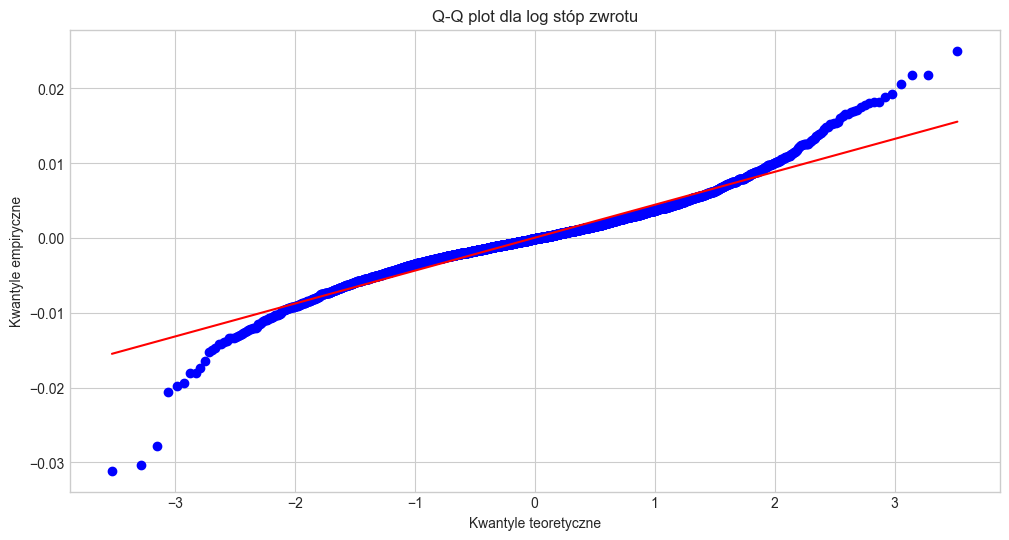

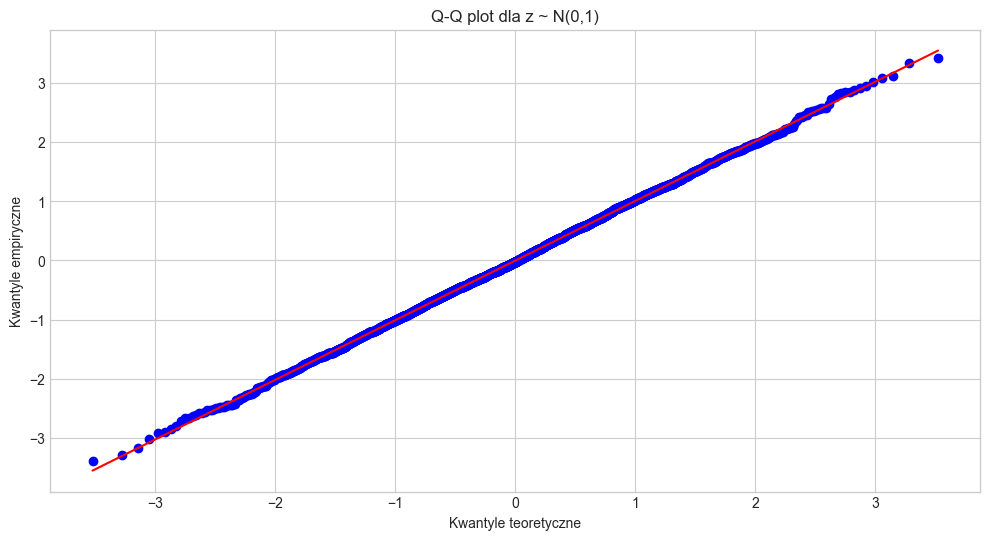

In [1059]:
## QQ plot dla log stóp zwrotu
plt.figure(figsize=(12, 6))
stats.probplot(dt_train['r'], dist="norm", plot=plt)
plt.title('Q-Q plot dla log stóp zwrotu')
plt.xlabel('Kwantyle teoretyczne')
plt.ylabel('Kwantyle empiryczne')
plt.grid(True)
plt.show()

# Q-Q plot dla z (dla porównania)
plt.figure(figsize=(12, 6))
stats.probplot(z, dist="norm", plot=plt)
plt.title('Q-Q plot dla z ~ N(0,1)')
plt.xlabel('Kwantyle teoretyczne')
plt.ylabel('Kwantyle empiryczne')
plt.grid(True)
plt.show()

Widzimy znaczące odstępstwo obserwacji od linii dopasowania do rozkładu normalnego (przed wszystkim w ogonach), co potwierdza nasze dotychczasowe wnioski

### 1.3.1 Autokorelacja reszt i kwadratów reszt

Ostatecznie możemy spojrzeć na wykresy autokorelacji reszt. **Autokorelacja reszt wskazuje na efekty AR(I)MA, z kolei autokorelacja kwadratów reszt wskazuje na efekty GARCH. Kwadratami reszt przybliżamy wariancję składnika losowego i wykorzystujemy je do modelowania GARCH.**

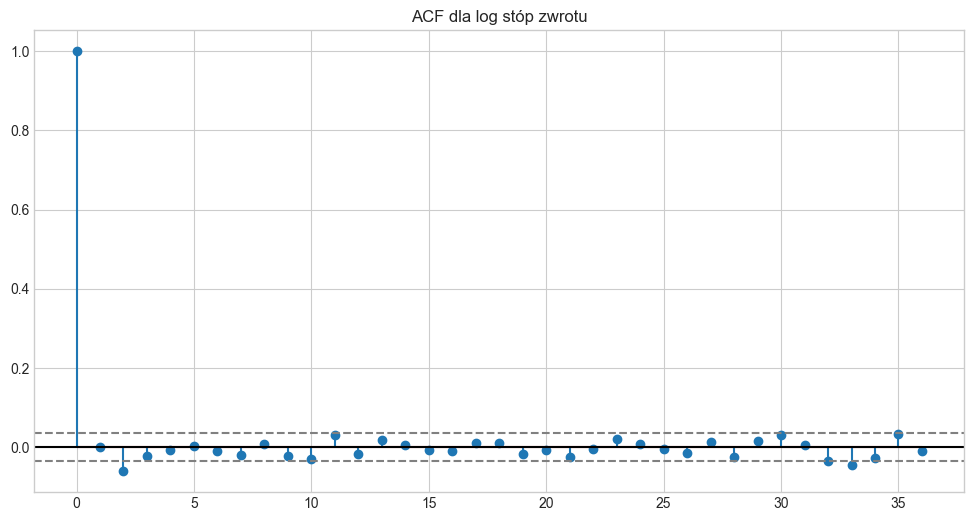

In [1060]:
# Funkcja ACF
acf_values = acf(dt_train['r'], nlags=36)
plt.figure(figsize=(12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.title('ACF dla log stóp zwrotu')
plt.show()

Na 0 i 3 opóźnieniu widać statystycznie istotne zależności. Ewentualnie na bardzo odległym opóźnieniu 33.

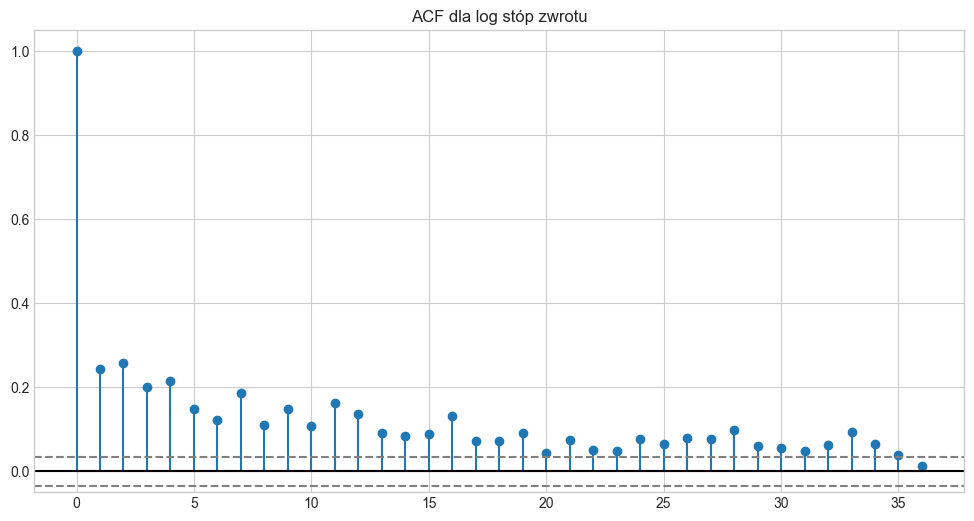

In [1061]:
# Funkcja ACF
acf_values = acf(dt_train['r']**2, nlags=36)
plt.figure(figsize=(12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.title('ACF dla log stóp zwrotu')
plt.show()

**Widzimy znaczącą (malejącą) autokorelacje na wielu opóźnieniach**. Dokładnie to czego byśmy się spodziewali przy zjawisku warunkowej hetereoskedastyczności.

Standardowy test na *ARCH effects* to test LM Engle'a. Test polega na sprawdzeniu istotności opóźnień kwadratów reszt z równania średniej (np. ARIMA) w regresji wariancji. A więc badamy czy reszty wykazują warunkową heteroskedastyczność w czasie.


**Interpretacja testu:** 

**Test LM Engle'a** 

**H0**: brak efektów ARCH

**H1**: efekty ARCH są istotne

Jeśli p-value jest mniejsze od zadanego poziomu istotności, to odrzucamy H0 -> efekty ARCH są istotne. Jeśli p-value jest większe od zadanego poziomu istotności, to nie odrzucamy H0 -> brak efektów ARCH.


In [1062]:
from statsmodels.stats.diagnostic import het_arch

returns_for_arch_test = dt_train['r']

arch_test_results = het_arch(returns_for_arch_test, nlags=5)

print("Test dla 5 opóźnień")
print(f"\nLM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

arch_test_results = het_arch(returns_for_arch_test, nlags=10) 

print("\nTest dla 10 opóźnień")
print(f"\nLM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

arch_test_results = het_arch(returns_for_arch_test, nlags=15) 

print("\nTest dla 15 opóźnień")
print(f"\nLM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

Test dla 5 opóźnień

LM Statistic: 406.770
p-value: 0.000
F-statistic: 92.825
F p-value: 0.000

Test dla 10 opóźnień

LM Statistic: 448.616
p-value: 0.000
F-statistic: 51.885
F p-value: 0.000

Test dla 15 opóźnień

LM Statistic: 470.837
p-value: 0.000
F-statistic: 36.547
F p-value: 0.000


> Stanowczo odrzucamy H0 -> efekty ARCH są istotne. Możemy przejść do modelowania

Statystyka F to wersja alternatywna testu LM. [Dokumentacja](https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.het_arch.html)

# 2. Modele GARCH

**W tej części wyestymujemy możliwie najlepsze modele klasy GARCH z rozszerzeniami. Na końcu porównamy moc predykcyjną modeli na zbiorze testowym *dt_test***

**Zaczynamy od prostych modeli (mało opóźnień) i dodajemy opóźnienia w celu eliminacji autokorelacji standaryzowanych kwadratów reszt. Analogicznie do procedury Box-Jenkinsa dla modeli ARIMA.**

Moglibyśmy zacząć od najprostszego modelu ARCH(1), który estymuje wariancję na podstawie tylko kwadratów reszt. Niemniej często w praktyce modele ARCH wymagają wielu opóźnień, żeby dobrze prognozowały. To z kolei utrudnia zapewnienie kluczowych założen dotyczacych parametrów:
* suma parametrów musi być mniejsza od 1, żeby proces ARCH estymował skończoną wariancję
* parametry muszą być nieujemne, żeby estymacja wariancji była nieujemna (nie dla wszystkich modeli, np. nie dla EGARCH)

Z tego powodu naszym modelem bazowym będzie standardowy model GARCH(1,1). Nie będziemy poświęcać czasu na rozwjianie modeli ARCH(q). Dla modeli GARCH również występują analogiczne założenia co do parametrów, ale w przypadku tych modeli często mała liczba opóźnienia daje pożądane dopasowanie. Nie jest też naszym celem przedstawianie wyczerpującej listy modeli klasy GARCH czy kompletnej diagnostyki dla każdego z modeli. Będziemy starali się estymować modele możliwie najlepsze biorąc po uwagę ograniczenia projektu. Ostatecznie najważniejszym zadaniem będzie estymacja i prognoza VaR, i to na tej podstawie będziemy głównie oceniać modele.

**Zacznijmy od prostego modelu GARCH(1,1)**

## 2.1 GARCH(1,1)

In [1063]:
# GARCH(1,1)
model_garch11 = arch_model(dt_train['r'].dropna(), vol='GARCH', mean='zero', p=1,q=1, rescale=False) # rescale=False dla wyłączenia ostrzeżeń
results_garch11 = model_garch11.fit(disp='off')
print(results_garch11.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      r   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13403.2
Distribution:                  Normal   AIC:                          -26800.4
Method:            Maximum Likelihood   BIC:                          -26782.1
                                        No. Observations:                 3254
Date:                Sun, Nov 16 2025   Df Residuals:                     3254
Time:                        17:14:35   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      3.9977e-07  1.715e-09    233.070      0.000 [3.

Jest to bardzo prosty model, który bazuje na **zerowej średniej** (przy stałej średniej występują problemy ze zbieżnością w modelu) - nie jest ona estymowana nawet prostym modelem ARIMA (rozluźnimy to założenie przy pomocy rozszerzeń AR(q)-GARCH(q,p)). Powyższy model można zapisać nastepująco:

* omega - $\omega$: stała w równaniu wariancji
* alpha[1] - $\alpha_1$: parametr przy pierwszym opóźnieniu kwadratów reszt (z równania średniej) w równaniu wariancji
* beta[1] - $\beta_1$: parametr przy pierwszym opóźnieniu wariancji w równaniu wariancji (analogicznie do części AR w modelach ARIMA)

> Równanie średniej: 
$$y_t =  u_t$$
$$u_t \sim N(0,\sigma^2_t)$$

> Równanie wariancji:
$$\sigma^2_t = \omega + \alpha_1u^2_{t-1} + \beta_1\sigma^2_{t-1}$$

Omega, alpha[1] oraz beta[1] są istotne. Widzimy, że suma parametrów jest mniejsza od 1 i parametry są dodatnie. Popatrzmy na wykresy standaryzowanych (kwadratów) reszt.

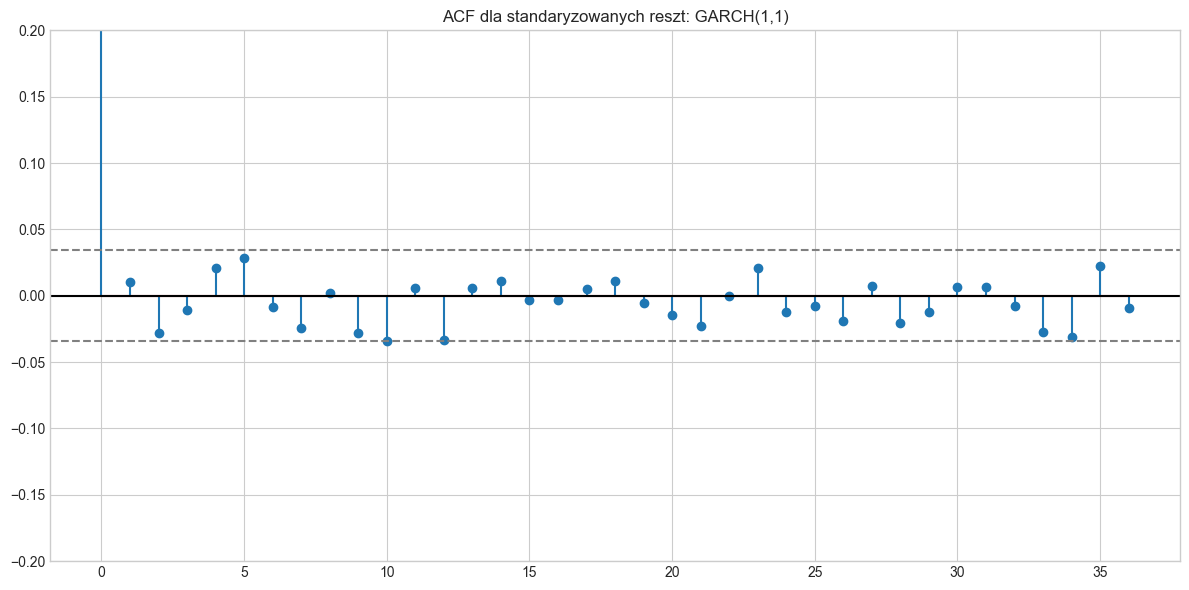

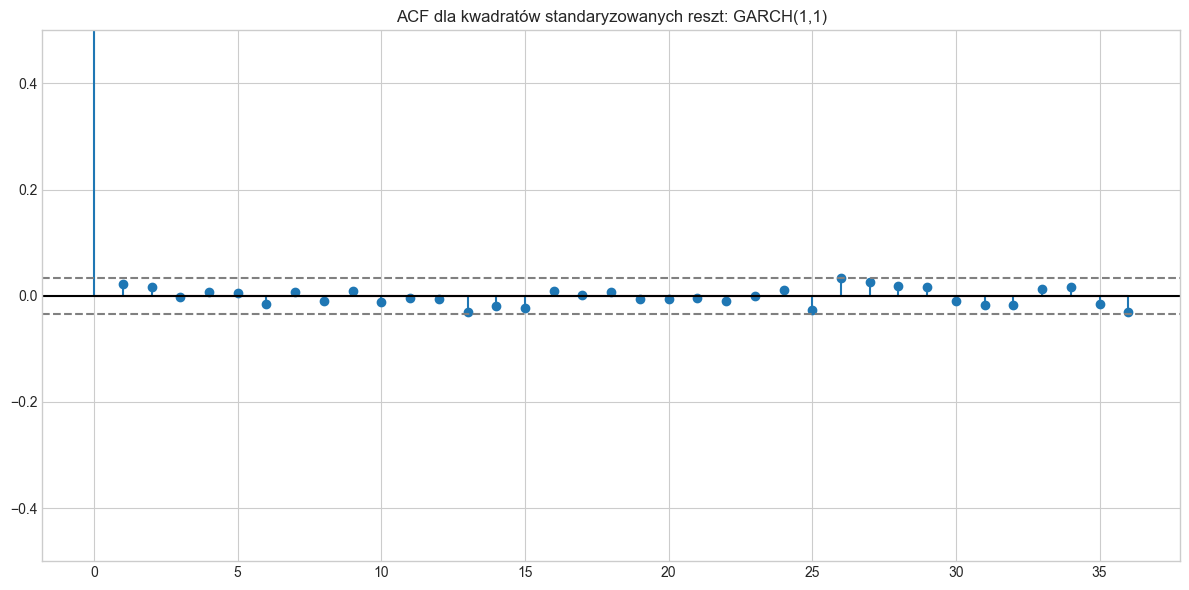


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.345911   0.556437
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 15.680617   0.109147
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 19.956665   0.173601
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 21.236006   0.383360

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 1.587918   0.207624
Wyniki testu Ljung-Box'a (10 opóźnień):
    lb_stat  lb_pvalue
10 4.685551   0.911170
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 10.843499   0.763608
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 11.599531   0.929171


In [1064]:
# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_garch11.resid / results_garch11.conditional_volatility, nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: GARCH(1,1)')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_garch11.resid / results_garch11.conditional_volatility)**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: GARCH(1,1)')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility)**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility)**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility)**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garch11.resid / results_garch11.conditional_volatility)**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

Widzimy na podstawie wykresów, że udało nam się usunąć autokorelację z modelu, co sugeruje dobre dopasowanie modelu GARCH(1,1) do naszych danych. Sprawdźmy to bardziej formalnie testem Ljung-Box'a na autokorelację reszt.

**Interpretacja testu:** 

**Test Ljung-Box'a** 

**H0**: brak autokorelacji reszt

**H1**: reszty wykazują autokorelację

Jeśli p-value jest mniejsze od zadanego poziomu istotności, to odrzucamy H0 ->  reszty wykazują autokorelację. Jeśli p-value jest większe od zadanego poziomu istotności, to nie odrzucamy H0 -> brak autokorelacji reszt.

Standaryzowane reszty - p-value są większe od 5% na wszystkich (analizowanych) opóźnieniach reszt. Nie ma podstaw do odrzucenia H0, więc udało nam się wyeliminować autokorelację reszt z modelu. Standaryzowane kwadraty reszt - p-value są większe od 5% dla wszystkich (analizowanych) opóźnień. Tutaj również wydaje się, że model jest dobrze dopasowany.

Można też spojrzeć na normalność standaryzowanych reszt.

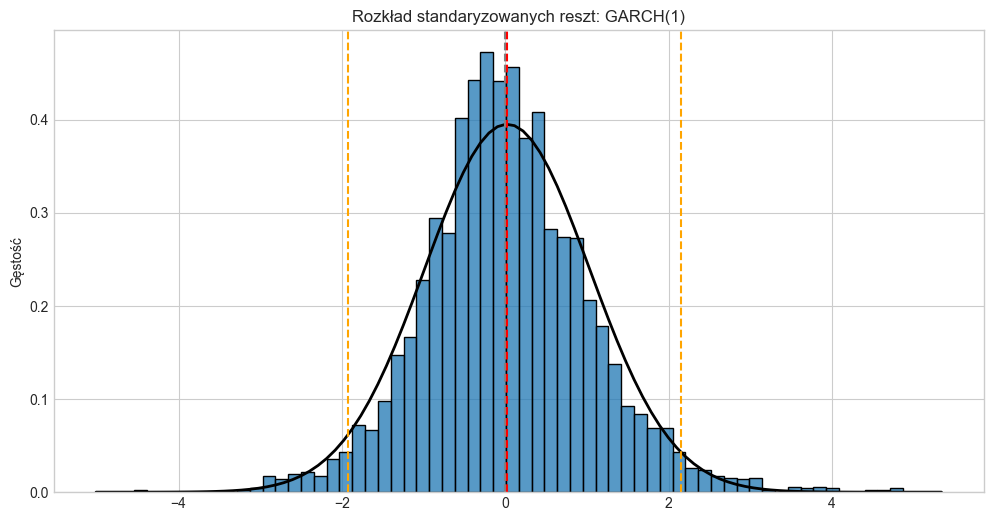

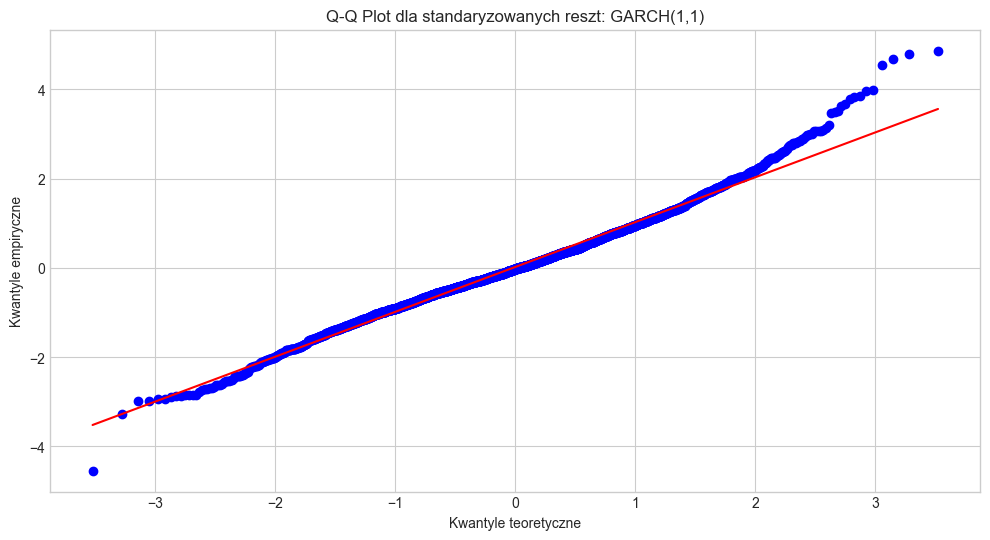

Statystyka testowa JB: 256.67
p-value: 1.84e-56


In [1065]:
# --- Wykresy
resid_std = (results_garch11.resid / results_garch11.conditional_volatility)

# Histogram 
plt.figure(figsize=(12, 6))
sns.histplot(resid_std, stat="density", bins = 60)
# krzywa rozkładu normalnego
mu, std = resid_std.mean(), resid_std.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.axvline(x=0, linestyle='--', color='gray')
plt.axvline(x=resid_std.mean(), linestyle='--', color='red')
plt.axvline(x=resid_std.quantile(0.025), linestyle='--', color='orange')
plt.axvline(x=resid_std.quantile(0.975), linestyle='--', color='orange')
plt.ylabel('Gęstość')
plt.title('Rozkład standaryzowanych reszt: GARCH(1)')
plt.show()

## Q-Q plot
plt.figure(figsize=(12, 6))
stats.probplot(resid_std, dist="norm", plot=plt)
plt.title('Q-Q Plot dla standaryzowanych reszt: GARCH(1,1)')
plt.xlabel('Kwantyle teoretyczne')
plt.ylabel('Kwantyle empiryczne')
plt.grid(True)
plt.show()

# --- Test JB
jb_test = stats.jarque_bera(resid_std)
print(f"Statystyka testowa JB: {jb_test[0]:.2f}")
print(f"p-value: {jb_test[1]:.2e}")

Widzimy na pierwszym wykresie ponownie większą kurtozę rozkład empirycznego niż normalnego. QQ plot wskazuje na znaczące odstępstwa w ogonach rozkładu. Rozkład reszt nie przypomina normalnego.

Mocno odrzucamy H0 testem JB o normalności reszt. Taka sytuacja może być problematyczna ze względu na założenia modelu. Z tego względu w dalszej części analizy estymujemy model *GARCH-t* w celu sprawdzenia czy rozkład reszy jest bliższy rozkładowi t-Studenta.

Jako, że celem modelu jest estymacja zmienności kursu walutowego, możemy zestawić na wykresie estymacje naszego modelu i wartości kursu walutowego w celu lepszego zrozumienia jak różnice w zmienności są odzwierciedlane w wartościach kursu. Niemniej jest to bardzie ilustracyjne i nie będziemy tego robić dla każdego modelu.

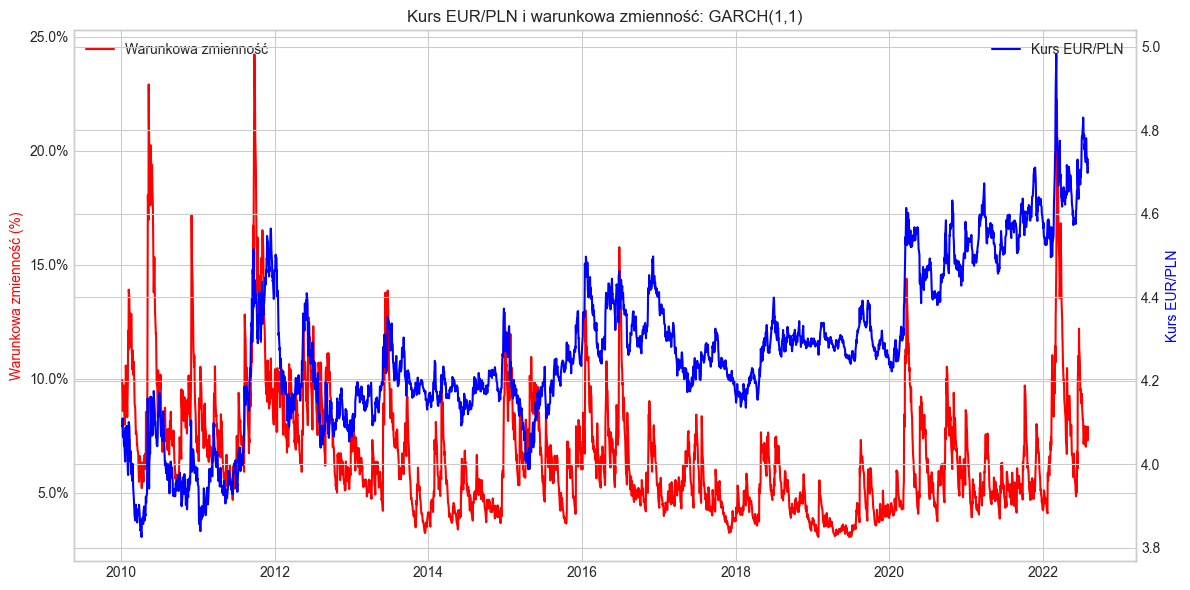

In [1066]:
# Wykres kursu i zmienności - dwie różne osie
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Na procent -> mnożymy przez 100
ax1.plot(results_garch11.conditional_volatility*np.sqrt(252)*100, color='red', label='Warunkowa zmienność')
ax2.plot(dt_train['Kurs'].dropna(), color='blue', label='Kurs EUR/PLN')
ax1.set_ylabel('Warunkowa zmienność (%)', color='red')
ax2.set_ylabel('Kurs EUR/PLN', color='blue')

# Formatowanie osi y w celu dodania symbolu %
from matplotlib.ticker import PercentFormatter
ax1.yaxis.set_major_formatter(PercentFormatter())

# Legenda
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_title('Kurs EUR/PLN i warunkowa zmienność: GARCH(1,1)')
ax1.grid(True)
fig.tight_layout()
plt.show()

Widzimy, że tam gdzie była największa zmienność (czerwona krzywa), tam kurs (niebieska krzywa) mocno wzrastał (np. 2012) lub malał (np. 2015). Przeważnie dochodziło do bardziej gwałtowynch wzrostów kursu (złoty deprecjonował) niż spadków.

## 2.2 EGARCH(1,1,1)

Wspomnieliśmy już o kwesti *asymetrii zmienności* (1.3 Efekty GARCH). W przypadku naszych danych widzimy (na podstawie analizy wykresów), że wariancja zmienia się bardziej przy wzroście kursu niż przy jego spadku. Zwykły model GARCH nie uchwyci dobrze takiej zależności, dlatego powstały modele, które modelują asymetrię szoków jak np. EGARCH. Równanie do estymacji wygląda następująco:


$$ \ln(\sigma^2_t) = \omega + \sum^k_{q=1} \beta \ln(\sigma^2_{t-q}) +\sum^o_{j=1} \gamma \frac{u_{t-j}}{\sqrt{\sigma^2_{t-j}}} + \sum^p_{i=1} \alpha_i [ \frac{|u_{t-i}|}{\sqrt{\sigma^2_{t-i}}} - \sqrt{\frac{2}{\pi}}]$$

Wartość absolutna reszty daję obsługę szoków pozytywnych jak i znak parametrów $\gamma$ i $\alpha$. Nie będziemy głebiej analizować matematycznych właściwości modelu. Nasza analiza skupia sie na wykorzystaniu modeli i wyboru najlepszgo pod kątem trafności prognoz. [Dokumentacja](https://arch.readthedocs.io/en/stable/univariate/generated/arch.univariate.EGARCH.html)


In [1067]:
model_egarch111 = arch_model(dt_train['r'], mean='zero', vol='EGARCH', dist='StudentsT', p=1, o=1, q=1, rescale=False)# p, o, q odpowiadają oznaczeniom z równania wyżej

results_egarch111 = model_egarch111.fit(disp='off')
print("Model EGARCH(1,1):")
print(results_egarch111.summary())

Model EGARCH(1,1):
                          Zero Mean - EGARCH Model Results                          
Dep. Variable:                            r   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:                13414.8
Distribution:      Standardized Student's t   AIC:                          -26819.6
Method:                  Maximum Likelihood   BIC:                          -26789.2
                                              No. Observations:                 3254
Date:                      Sun, Nov 16 2025   Df Residuals:                     3254
Time:                              17:14:36   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
------------------------------------------------------------------

Problemy ze zbieżnością algorytmu i nierealnymi estymacjami parametrów rozwiązujemy poprzez ustawienie parametru `mean=0` (równanie średnie) oraz wybór rozkładu t-Studenta dla naszych danych (co w gruncie rzeczy daje nam model EGARCH-t). Należy zaznaczyć, że w tym modelu modelujemy $\ln(\sigma^2_t)$

Widzimy, że wszystkie parametry są istotne na poziomie 5%. Parametr $\gamma$ ma znak pozytywny, co wskazuje bardziej na to, że wariancja rośnie bardziej przy wzroście kursu walutowego niż przy jego spadku. Potwierdza to nasz wcześniejsze wnioski, ale jest też ciekawe z tego względu, że przeważnie dla, przkładowo, cen akcji znak parametru jest odwrotny.

Parametr $\nu$ w sekcji *Distribution* określa liczbę stopni swobody w rozkładzie t-Studenta. Widzimy, że jest mała, więc mamy grubsze ogony niż w rozkładzie normalnym.

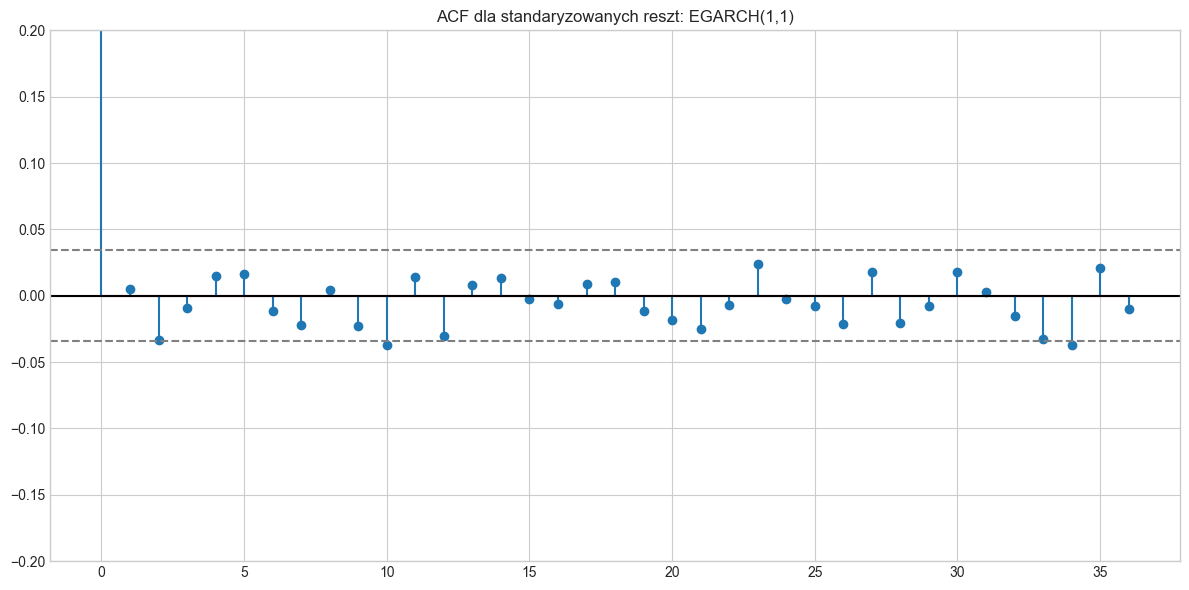

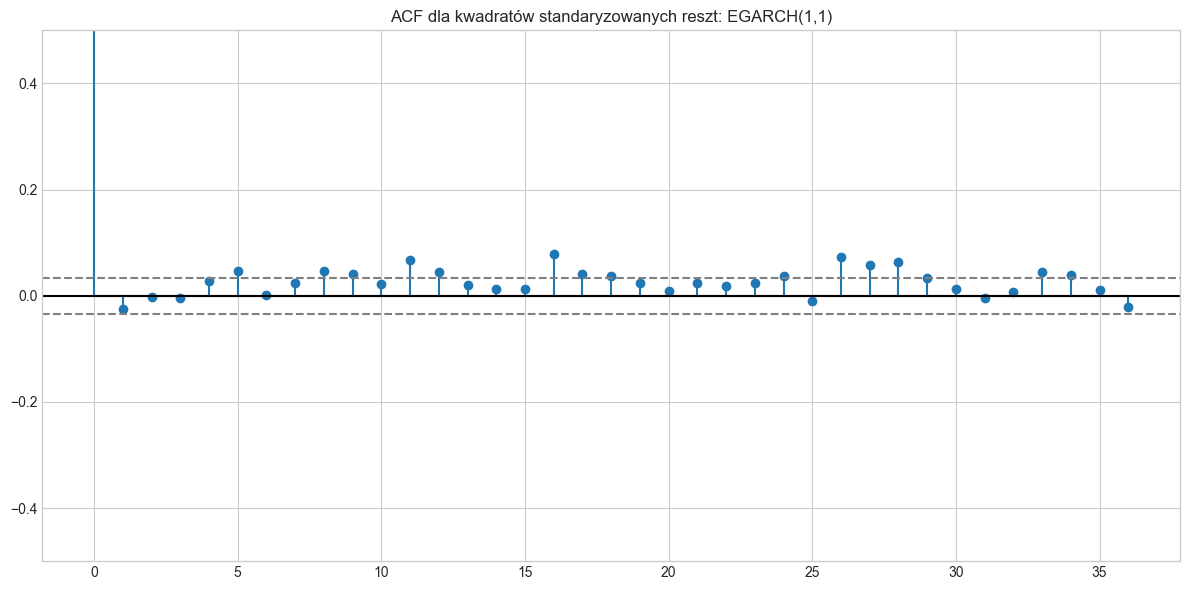


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.086130   0.769156
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 13.990190   0.173440
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 18.499048   0.237338
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 20.806801   0.408582

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 1.996072   0.157707
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 27.305311   0.002330
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 51.403348   0.000007
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 83.691289   0.000000


In [1068]:
# --- Wykresy ACF ---

# .conditional volatility już przeskalowuje log wariancję na wariancję -> możemy porównywać wyniki modeli

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_egarch111.resid / results_egarch111.conditional_volatility, nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: EGARCH(1,1)')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_egarch111.resid / results_egarch111.conditional_volatility)**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'])), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: EGARCH(1,1)')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility)**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility)**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility)**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_egarch111.resid / results_egarch111.conditional_volatility)**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

Niestety wydaję się, że specyfikacja modelu nie jest idealna. Mamy zauważalną autokorelację na dalszych opóźnieniach (wykres i wyniki testu). Korzystając z wcześniej przedstawionej procedury analizy poprawności modelu sprawdziliśmy model EGARCH z większą liczbą różnych opóźnień. Niestety dawało to absurdalne oszacowania lub problemy z zbieżnością. Zostajemy przy powyższej specyfikacji modelu EGARCH.

## 2.3 AR(1)-GARCH(1,1)

Przy okazji estymacji modelu GARCH(1,1) zauważyliśmy, że modelowanie równania średniej korzystając tylko ze stałej może być niezadowalające. Możemy skorzystać ze standardowego modelu ARIMA jako równanie naszej średniej i skorzystać z reszt z tego modelu do estymacji GARCH. Zatem nasze równania, przykładowo, dla AR(1)-GARCH(1,1), to:

> Równanie średniej: 
$$y_t = \mu + \nu_1y_{t-1} + u_t$$
$$u_t \sim N(0,\sigma^2_t)$$

> Równanie wariancji:
$$\sigma^2_t = \omega + \alpha_1u^2_{t-1} + \beta_1\sigma^2_{t-1}$$


In [1069]:
model_ar1garch11 = arch_model(dt_train['r'].dropna(), mean='AR', lags = 1, vol='GARCH', p=1, q=1, rescale=False)
results_ar1garch11 = model_ar1garch11.fit(disp='off')
print("AR(1)-GARCH(1, 1):")
print(results_ar1garch11.summary())

AR(1)-GARCH(1, 1):
                           AR - GARCH Model Results                           
Dep. Variable:                      r   R-squared:                      -0.000
Mean Model:                        AR   Adj. R-squared:                 -0.000
Vol Model:                      GARCH   Log-Likelihood:                13397.5
Distribution:                  Normal   AIC:                          -26785.0
Method:            Maximum Likelihood   BIC:                          -26754.5
                                        No. Observations:                 3253
Date:                Sun, Nov 16 2025   Df Residuals:                     3251
Time:                        17:14:37   Df Model:                            2
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const      -1.4747e-05  5.610e-05

Widzimy, że jakkolwiek zmienne w równaniu wariancji są istotne to opóźnienie w równaniu średniej nie jest istotne. Parametr rescale=True nie zmienia istotnie wniosków.

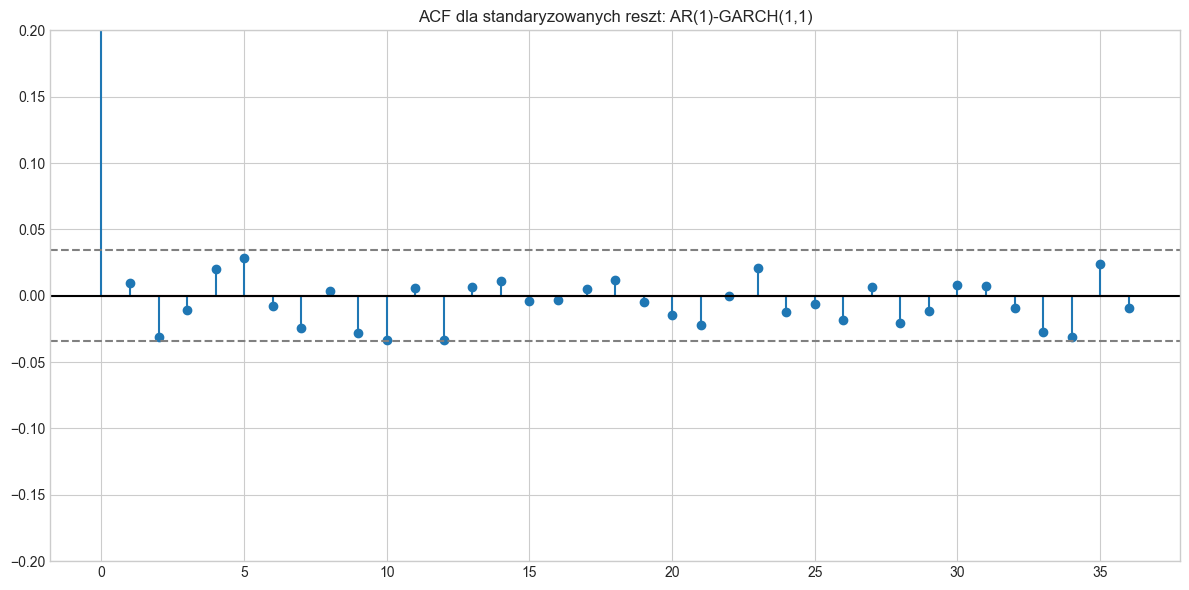

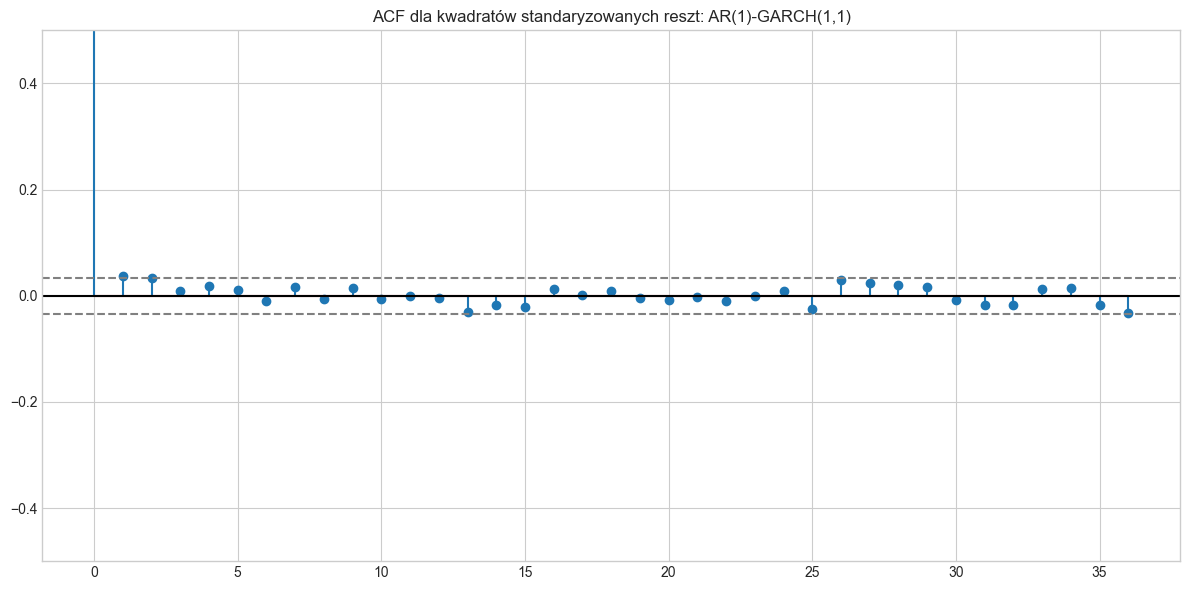


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.310401   0.577434
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 16.224952   0.093371
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 20.640802   0.148704
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 21.932869   0.344164

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 4.689559   0.030346
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 12.314542   0.264557
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 17.630289   0.282601
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 18.582624   0.549086


In [1070]:
# Pojawił się problem z NaN -> trzeba było wszędzie włożyć .dropna()

# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna(), nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: AR(1)-GARCH(1,1)')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna())**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: AR(1)-GARCH(1,1)')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna()), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna()), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna()), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna()), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna())**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna())**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna())**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch11.resid.dropna() / results_ar1garch11.conditional_volatility.dropna())**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

Patrząc na wykres widzimy, że udało się wyeliminować autokorelację na opóźnieniach. Test LB potwierdza ten wniosek dla standaryzowanych reszt. Dla kwadratowych standaryzowanych reszt test też odrzuca H0 poza pierwszym opóźnieniem.

Spróbujmy dodać opóźnienie i stworzyć model AR(1)-GARCH(1,2)

In [1071]:
model_ar1garch21 = arch_model(dt_train['r'].dropna(), mean='AR', lags = 1, vol='GARCH', p=2, q=1, rescale=False)
results_ar1garch21 = model_ar1garch21.fit(disp='off')
print("AR(1)-GARCH(2, 1):")
print(results_ar1garch21.summary())

AR(1)-GARCH(2, 1):
                           AR - GARCH Model Results                           
Dep. Variable:                      r   R-squared:                    -220.480
Mean Model:                        AR   Adj. R-squared:               -220.548
Vol Model:                      GARCH   Log-Likelihood:                4080.87
Distribution:                  Normal   AIC:                          -8149.73
Method:            Maximum Likelihood   BIC:                          -8113.21
                                        No. Observations:                 3253
Date:                Sun, Nov 16 2025   Df Residuals:                     3251
Time:                        17:14:37   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0.0670  1.940e-03     34

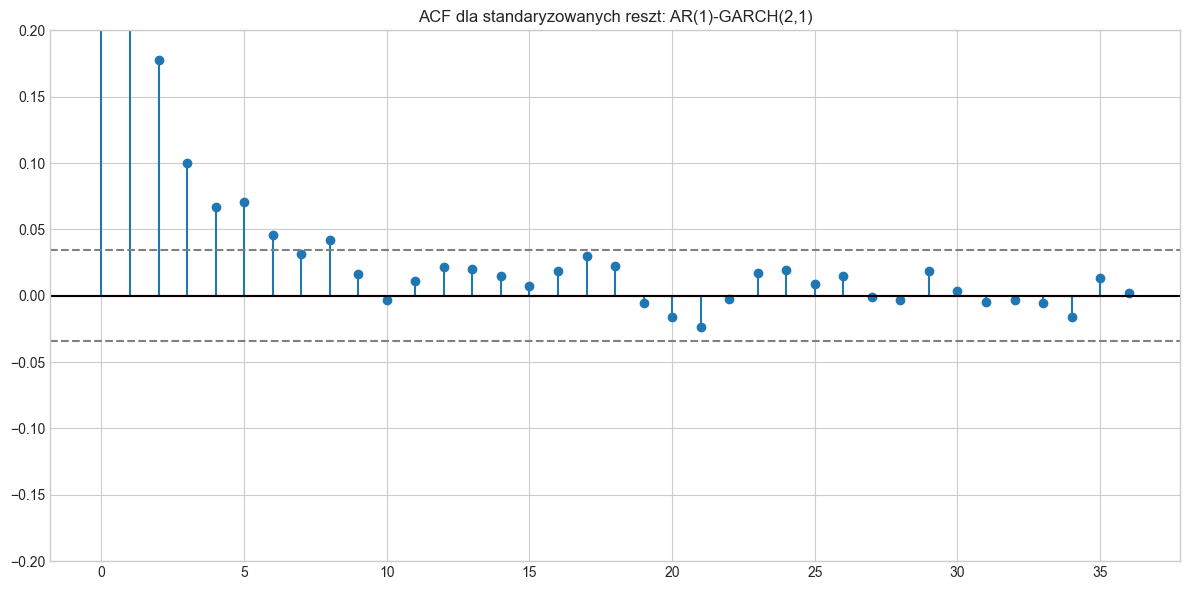

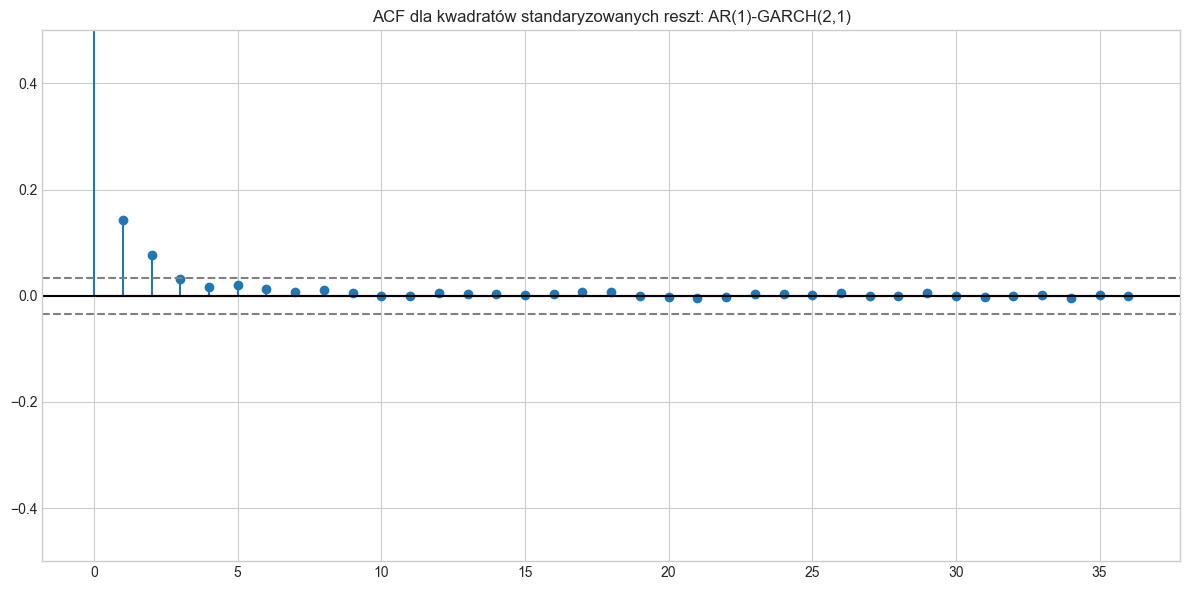


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
     lb_stat  lb_pvalue
1 286.604453   0.000000
Wyniki testu Ljung-Box'a (10 opóźnień):
      lb_stat  lb_pvalue
10 469.801939   0.000000
Wyniki testu Ljung-Box'a (15 opóźnień):
      lb_stat  lb_pvalue
15 473.913441   0.000000
Wyniki testu Ljung-Box'a (20 opóźnień):
      lb_stat  lb_pvalue
20 480.639037   0.000000

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
    lb_stat  lb_pvalue
1 65.713305   0.000000
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 92.302161   0.000000
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 92.478174   0.000000
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 92.874332   0.000000


In [1072]:
# Pojawił się problem z NaN -> trzeba było wszędzie włożyć .dropna()

# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna(), nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: AR(1)-GARCH(2,1)')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna())**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: AR(1)-GARCH(2,1)')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna()), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna()), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna()), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna()), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna())**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna())**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna())**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_ar1garch21.resid.dropna() / results_ar1garch21.conditional_volatility.dropna())**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

**Ten model raczej nie sprawdzi się w praktyce.**

Teraz jest problem z równaniem średniej - mamy duże autokorelacje w standaryzowanych resztach. **Niestety inne specyfikacje prowadziły do nieralnych oszacowań** (łamiących założenia modelu -> niestacjonarne oszacowania) lub problemów ze zbieżnością algorytmu obliczeniowego czy znaczącą nieistotnością zmiennych. **Ewentualnie, inne modele (klasy AR-GARCH), które testowaliśmy estymowały bardzo zawyżone VaR względem innych modeli, więc nie uwzględniliśmy ich w ostatecznej analizie.**

Podobnie możemy skorzystać z części AR w modelu EGARCH. Modele tej klasy można generalnie łączyć z innymi rozszerzeniami. 

**Niestety w przypadku naszych danych modele klasy AR-EGARCH dla sensownej liczby opóźnień miały problemy ze zbieżnością, dlatego nie uwzględniamy ich w analizie**

## 2.4 GARCH-in-mean

W celu wykrycia zjawiska *risk premium* możemy spojrzeć czy estymowana przez nas wariancja jest istotnym predyktorem w równaniu średniej. Zatem chcemy wyestymować GARCH-in-mean. Poniżej przedstawiamy prosty przykład:

> Równanie średniej: 
$$y_t = \mu + \nu_1y_{t-1} + u_t + \kappa_t\sigma^2_t$$
$$u_t \sim N(0,\sigma^2_t)$$

> Równanie wariancji - standardowy GARCH(1,1):
$$\sigma^2_t = \omega + \alpha_1u^2_{t-1} + \beta_1\sigma^2_{t-1}$$

Premia za ryzyko istnieje jeśli parametr $\kappa_t$ jest dodatni i istotny statystycznie.

In [1073]:
model_garchm11 = ARCHInMean(dt_train['r'].dropna(), lags=[1], volatility=GARCH(),rescale=False)
results_garchm11 = model_garchm11.fit(disp='off')

print("GARCH-M(1, 1):")
print(results_garchm11.summary())

GARCH-M(1, 1):
                      ARCH-in-mean - GARCH Model Results                      
Dep. Variable:                      r   R-squared:                      -0.117
Mean Model:              ARCH-in-mean   Adj. R-squared:                 -0.118
Vol Model:                      GARCH   Log-Likelihood:                13141.3
Distribution:                  Normal   AIC:                          -26270.6
Method:            Maximum Likelihood   BIC:                          -26234.1
                                        No. Observations:                 3253
Date:                Sun, Nov 16 2025   Df Residuals:                     3250
Time:                        17:14:38   Df Model:                            3
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
Const      -1.5011e-03  6.250e-07 

Inne warianty tego modelu wykazywały problemy ze zbieżnością.

**Powyższy model jakkolwiek wydaje się najlepszy tej klasy to widzimy, że $\kappa$ jest dodatnia, ale nieistotna, więc odrzucamy hipotezę, że mamy do czynienia ze zjawiskiem *risk premium*.** Parametr rescale=True pogarsza jakość modelu.

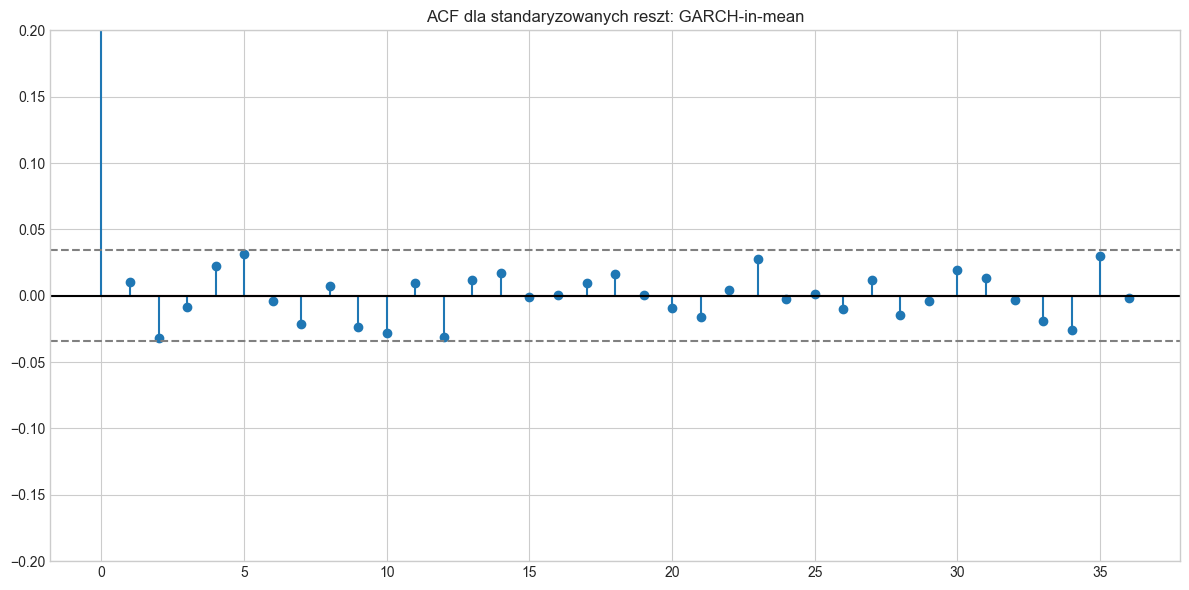

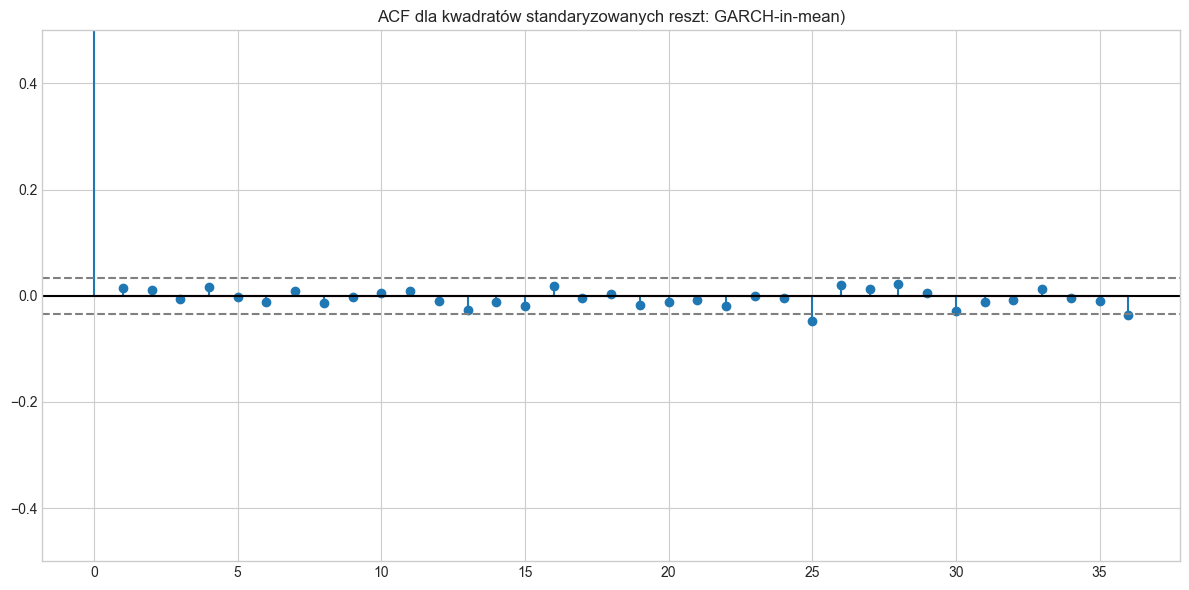


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.359394   0.548843
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 15.099921   0.128461
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 19.939827   0.174253
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 21.380803   0.375031

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.762988   0.382395
Wyniki testu Ljung-Box'a (10 opóźnień):
    lb_stat  lb_pvalue
10 3.794591   0.956138
Wyniki testu Ljung-Box'a (15 opóźnień):
    lb_stat  lb_pvalue
15 8.201988   0.915430
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 10.764339   0.952106


In [1074]:
# Pojawił się problem z NaN -> trzeba było wszędzie włożyć .dropna()

# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna(), nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: GARCH-in-mean')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna())**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: GARCH-in-mean)')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna()), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna()), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna()), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna()), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna())**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna())**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna())**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garchm11.resid.dropna() / results_garchm11.conditional_volatility.dropna())**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

**Kwestia autokorelacji wygląda lepiej. Niemniej ze względu na to, że $\kappa$ jest nieistotna (nie mamy do czynienia z efektem *risk premium*) to nie będziemy dalej analizować tego modelu.**

## 2.5 GARCH-t

Zobaczyliśmy już przy okazji modelu EGARCH, że potencjalnie lepszym rozkładem do modelowania naszych reszt jest rozkład t-Studenta. Dotychczas (chyba, że w modelu było zaznaczone inaczej) korzystaliśmy z założenia, że reszty mają rozkład normalny. Możemy spróbować wyestymować model GARCH (który do tej pory przedstawiał dobry balans pomiędzy dopasowaniem a skomplikowaniem), ale zakładając rozkład t-Studenta: GARCH-t.

Poniżej przedstawiamy już gotowy model (pomijając ukazanie wszystkich kroków procedury):

In [1075]:
# Fit a GARCH-t(2,2) model
model_garcht22 = arch_model(dt_train['r'].dropna(), mean='zero', vol='garch', p=2, q=2, dist='t', rescale=False)
results_garcht22 = model_garcht22.fit(disp='off')
print("GARCH-t(2, 2):")
print(results_garcht22.summary())

GARCH-t(2, 2):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            r   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                13449.3
Distribution:      Standardized Student's t   AIC:                          -26886.6
Method:                  Maximum Likelihood   BIC:                          -26850.1
                                              No. Observations:                 3254
Date:                      Sun, Nov 16 2025   Df Residuals:                     3254
Time:                              17:14:38   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------------------------------------

Parametr $\nu$ w sekcji *Distribution* podaje ile stopni swobody ma użyty przez nas rozkład t-Studenta. Wszystkie zmienne są mocno istotne na poziomie 5% (poza beta[1]). Parametr rescale=True pogarsza jakość modelu.

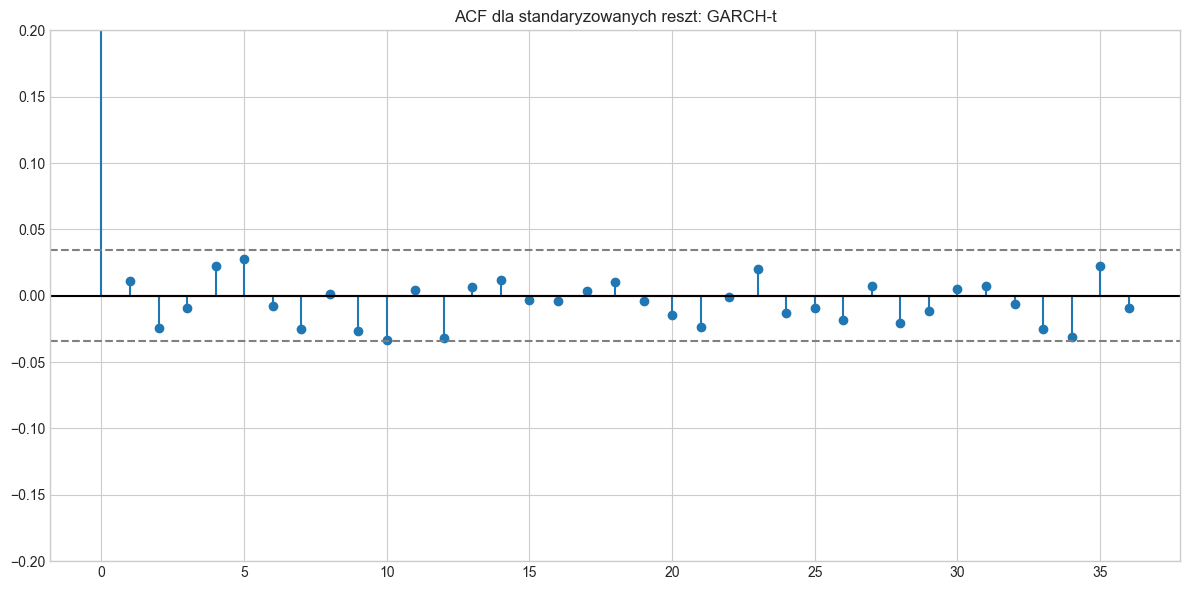

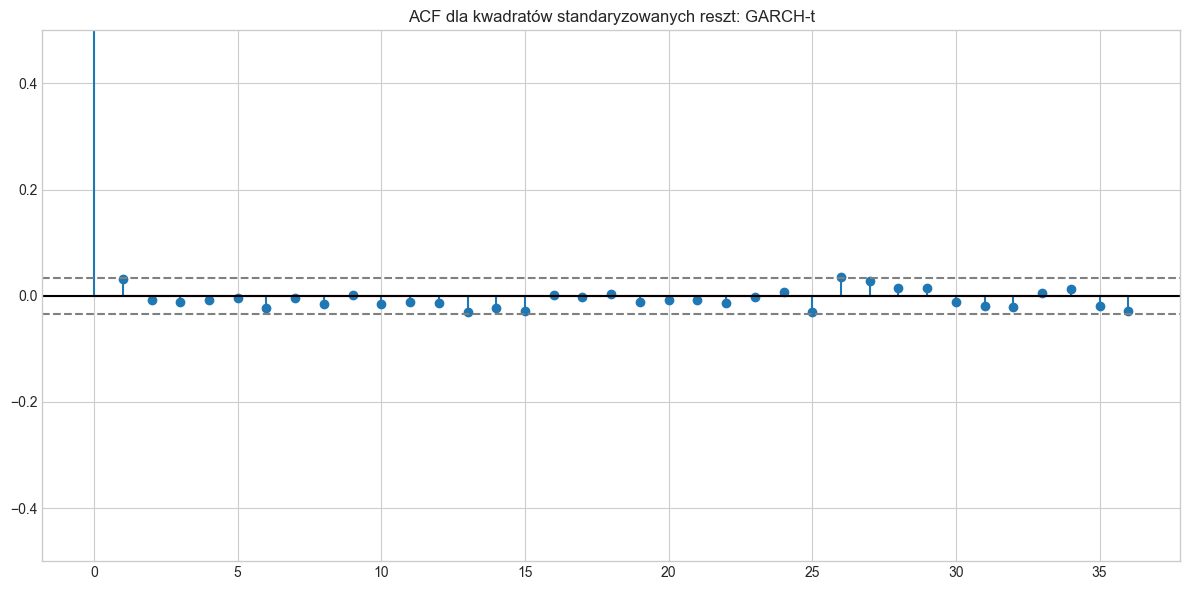


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.426940   0.513494
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 14.994182   0.132274
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 19.063681   0.210863
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 20.274559   0.440877

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 3.330826   0.067993
Wyniki testu Ljung-Box'a (10 opóźnień):
    lb_stat  lb_pvalue
10 7.614105   0.666473
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 16.358078   0.358661
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 17.020451   0.651645


In [1076]:
# Pojawił się problem z NaN -> trzeba było wszędzie włożyć .dropna()

# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna(), nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: GARCH-t')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna())**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt_train['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: GARCH-t')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna()), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna()), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna()), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna()), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna())**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna())**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna())**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_garcht22.resid.dropna() / results_garcht22.conditional_volatility.dropna())**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

Udało nam się wyeliminować autokorelację z reszt i kwadratów reszt

## 2.6 Podsumowanie modeli

Funkcja do porównania modeli pod kątem kryteriów informacyjnych. Im mniejsza wartość kryterium, tym lepszy model

In [ ]:
def compare_ICs_arch_models(model_results_dict):
    """
    Placeholder function to compare Information Criteria (AIC, BIC, etc.)
    for a dictionary of fitted arch model results.

    Args:
        model_results_dict (dict): A dictionary where keys are model names (str)
                                   and values are fitted arch model result objects.
    
    Returns:
        pandas.DataFrame: A DataFrame with models as rows and ICs as columns.
    """
    if not model_results_dict:
        print("No model results provided.")
        return pd.DataFrame()

    ic_data = []
    for name, res in model_results_dict.items():
        if hasattr(res, 'aic') and hasattr(res, 'bic'):
            ic_data.append({
                'Model': name,
                'AIC': res.aic,
                'BIC': res.bic,
                'LogLikelihood': res.loglikelihood,
                'Num Params': len(res.params)
            })
        else:
            print(f"Warning: Model {name} does not have standard IC attributes.")
            ic_data.append({
                'Model': name,
                'AIC': np.nan,
                'BIC': np.nan,
                'LogLikelihood': np.nan,
                'Num Params': np.nan
            })
            
    ic_df = pd.DataFrame(ic_data)
    if not ic_df.empty:
      ic_df = ic_df.set_index('Model')
    return ic_df

In [1132]:
# dictionary of fitted models
fitted_arch_models = {
    'GARCH(1,1)': results_garch11,
    'EGARCH(1,1,1)': results_egarch111,
    'AR(1)-GARCH(1,1)': results_ar1garch11,
    'GARCH-in-mean': results_garchm11,
    'GARCH-t': results_garcht22
}
valid_fitted_models = {name: model for name, model in fitted_arch_models.items() if model is not None}

ic_comparison_table = compare_ICs_arch_models(valid_fitted_models)
print("\nKryteria informacyjne (sortowanie: AIC):")
print(ic_comparison_table.sort_values(by='AIC')) 

print("\nKryteria informacyjne (sortowanie: BIC):")
print(ic_comparison_table.sort_values(by='BIC')) 


Kryteria informacyjne (sortowanie: AIC):
                           AIC           BIC  LogLikelihood  Num Params
Model                                                                  
GARCH-t          -26886.625831 -26850.099989   13449.312915           6
EGARCH(1,1,1)    -26819.626085 -26789.187884   13414.813043           5
GARCH(1,1)       -26800.396304 -26782.133384   13403.198152           3
AR(1)-GARCH(1,1) -26784.959459 -26754.522794   13397.479729           5
GARCH-in-mean    -26270.635150 -26234.111153   13141.317575           6

Kryteria informacyjne (sortowanie: BIC):
                           AIC           BIC  LogLikelihood  Num Params
Model                                                                  
GARCH-t          -26886.625831 -26850.099989   13449.312915           6
EGARCH(1,1,1)    -26819.626085 -26789.187884   13414.813043           5
GARCH(1,1)       -26800.396304 -26782.133384   13403.198152           3
AR(1)-GARCH(1,1) -26784.959459 -26754.522794   13397

Widzimy, że pod względem wszystkich kryteriów modele **AR(1)-GARCH(1,1) i GARCH-in-mean są najgorsze** (kluczowe parametry również były nieistotne). `Z tego powodu nie będziemy dalej brali pod uwagę.` Dodatkowo, w testach, które przeprowadziliśmy (nie są ukazane w analizie) oba modele wykazywały znaczące problemy z jakością prognoz i zbieżnością algorytmów. Zmiany, które należałoby wprowadzić musiałby drastycznie zmienić formę modelu lub wprowadzić zupełnie odrębne metody prognozowania (kwestie fixed, rolling, recursive prognozowania oraz symulacyjne). To utrudniało porównanie modeli, a prognozy pomimo wielu modyfikacji kodu były mniej niż zadowalające.

Na tym etapie kończymy proces estymacji modeli i przechodzimy do estymacji i prognozowania VaR.

>**Modele, których użyjemy do estymacji to wcześniej przedstawione:**
* GARCH(1,1)
* EGARCH(1,1,1)
* GARCH-t

# 3. Estymacja VaR

Dodatkowe przekształcenia danych przed estymacją

In [1079]:
print(dt_train)

            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r
Data                                                                     
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100  0.003674
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000  0.000709
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500  0.004023
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800 -0.009953
2010-01-11  4.057400   4.069400   4.040300    4.063300 4.063300 -0.001353
...              ...        ...        ...         ...      ...       ...
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875

[3254 rows x 6 columns]


In [1133]:
dt_train=dt_train.copy() # usunięcie ostrzeżeń
dt_train['obs'] = range(1, len(dt_train) + 1)
print("dt_train z liczbami obserwacji:")
dt_train

dt_train z liczbami obserwacji:


,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,obs,rstd,VaR_IS005_garch11,VaR_IS005_egarch111,VaR_IS005_garcht22,VaR_IS995_garch11,VaR_IS995_egarch111,VaR_IS995_garcht22,Data_helper
Data,,,,,,,,,,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674,1,0.852552,-0.019004,-0.018004,-0.019001,0.022485,0.021302,0.022483,2010-01-05
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709,2,0.162353,-0.018155,-0.017048,-0.018320,0.021481,0.020172,0.021677,2010-01-06
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023,3,0.933791,-0.016976,-0.014427,-0.016981,0.020086,0.017070,0.020092,2010-01-07
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953,4,-2.319278,-0.016422,-0.014913,-0.016201,0.019430,0.017645,0.019169,2010-01-08
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353,5,-0.317456,-0.018559,-0.016754,-0.018018,0.021960,0.019823,0.021319,2010-01-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,4.742740,4.752490,4.707540,4.716780,4.716780,-0.004885,3250,-1.139728,-0.014421,-0.014572,-0.014443,0.017062,0.017242,0.017089,2022-08-01
2022-08-02,4.716380,4.738870,4.702980,4.731720,4.731720,0.003162,3251,0.733446,-0.014456,-0.014186,-0.014458,0.017104,0.016784,0.017106,2022-08-02
2022-08-03,4.731730,4.736350,4.689230,4.697850,4.697850,-0.007184,3252,-1.674681,-0.013952,-0.014103,-0.014064,0.016508,0.016686,0.016641,2022-08-03


Standaryzacja logarytmicznych stóp zwrotu

In [1081]:
# Usunięcie Na
r_clean_dt_train = dt_train['r'].dropna()
mean_r_dt_train = r_clean_dt_train.mean()
std_r_dt_train = r_clean_dt_train.std()

# Standaryzowane reszty
dt_train=dt_train.copy()
dt_train['rstd'] = (dt_train['r'] - mean_r_dt_train) / std_r_dt_train
print("dt_train ze standaryzowanymi resztami (ostatnie obserwacje):")
dt_train.tail()

dt_train ze standaryzowanymi resztami (ostatnie obserwacje):


,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,obs,rstd
Data,,,,,,,,
2022-08-01,4.742740,4.752490,4.707540,4.716780,4.716780,-0.004885,3250,-1.093553
2022-08-02,4.716380,4.738870,4.702980,4.731720,4.731720,0.003162,3251,0.691648
2022-08-03,4.731730,4.736350,4.689230,4.697850,4.697850,-0.007184,3252,-1.603382
2022-08-04,4.698310,4.735780,4.696410,4.712490,4.712490,0.003111,3253,0.680349
2022-08-05,4.710870,4.718630,4.702720,4.708370,4.708370,-0.000875,3254,-0.203865


Podstawowe statystyki opisowe

In [1082]:
print("Statystyki opisowe danych Stooq\n", dt_train)
print("\nŚrednia:", dt_train['rstd'].mean())
print("\nOdchylenie standardowe:", dt_train['rstd'].std())
print("\nMinimum:", dt_train['rstd'].min())
print("1 percentyl:", dt_train['rstd'].quantile(0.01))
print("5 percentyl:", dt_train['rstd'].quantile(0.05))
print("10 percentyl:", dt_train['rstd'].quantile(0.10))
print("25 percentyl:", dt_train['rstd'].quantile(0.25))
print("Mediana (50%):", dt_train['rstd'].median())
print("75 percentyl:", dt_train['rstd'].quantile(0.75))
print("90 percentyl:", dt_train['rstd'].quantile(0.90))
print("95 percentyl:", dt_train['rstd'].quantile(0.95))
print("99 percentyl:", dt_train['rstd'].quantile(0.99))
print("Maksimum:", dt_train['rstd'].max())

print("\nSkośność:", stats.skew(dt_train['rstd']))
print("Kurtoza (nadwyżkowa):", stats.kurtosis(dt_train['rstd']))

Statystyki opisowe danych Stooq
             Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100  0.003674   
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000  0.000709   
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500  0.004023   
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800 -0.009953   
2010-01-11  4.057400   4.069400   4.040300    4.063300 4.063300 -0.001353   
...              ...        ...        ...         ...      ...       ...   
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720 

Mamy średnią i odchylenie bliskie 0 i 1 (czego należy się spodziewać po standaryzacji). Widzimy również, że skośność jest nieznacznie dodatnia i kurtoza jest równa około 4.

## 3.1 Kwantyle empiryczne

Zbliżając się do estymacji VaR (przede wszystkim 99,5% oraz 0,5%) spójrzmy na wybrane empiryczne kwantyle naszego rozkładu standaryzowanych logarytmicznych zwrotów: 0.5% oraz 99.5%.

In [1083]:
print("Kwantyle log stóp zwrotu")
q005_empirical_dt_train = dt_train['rstd'].dropna().quantile(0.005)
print(f"0.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: {q005_empirical_dt_train:.4f}")

q995_empirical_dt_train = dt_train['rstd'].dropna().quantile(0.995)
print(f"99.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: {q995_empirical_dt_train:.4f}")

# Dla porównania rozkład normalny
print("\nDla porównania rozkład normalny")
qnorm_005_theoretical = stats.norm.ppf(0.005, 0, 1)
print(f"0.5% kwantyl dla standardowego rozkładu normalnego: {qnorm_005_theoretical:.4f}")

qnorm_995_theoretical = stats.norm.ppf(0.995, 0, 1)
print(f"99.5% kwantyl dla standardowego rozkładu normalnego: {qnorm_995_theoretical:.4f}")

Kwantyle log stóp zwrotu
0.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: -3.0342
99.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: 3.5901

Dla porównania rozkład normalny
0.5% kwantyl dla standardowego rozkładu normalnego: -2.5758
99.5% kwantyl dla standardowego rozkładu normalnego: 2.5758


Ponownie widzimy zdecydowanie grubsze ogony w rozkładzie empirycznym

**W następnych sekcjach przedstawimy oszacowania VaR in-sample rzędu 0.5% i 99.5%.** Dzięki estymacji modeli GARCH możemy uwzględnić warunkową heteroskedastyczność i wyprowadzić VaR w następujący sposób:

$$ 
VaR_{{t+1}_{0.5\%}} = q^{emp}_{0.5\%}  \cdot \sigma^{cond}_{{t+1}_{0.5\%}}
$$ 

oraz

$$ 
VaR_{{t+1}_{99.5\%}} = q^{emp}_{99.5\%}  \cdot \sigma^{cond}_{{t+1}_{99.5\%}}
$$ 

Naszym oszacowaniem jest iloczyn kwantyla empirycznego i oszacowania zmienności z wybranego modelu. Jest to standardowe podejście ([wykład noblowski Engle'a](https://www.nobelprize.org/uploads/2018/06/engle-lecture.pdf)) do wykorzystania wyników modeli GARCH w estymacji VaR. 

**Podstawową diagnostyką będzie liczba przekroczeń.** Definiujemy ją jako liczba razy kiedy wartość badanej zmiennej (log stopy zwrotu) przekroczyły odpowiedni VaR. Dla $VaR_{0.5\%}$ patrzymy na to ile obserwacji jest mniejszych od $VaR_{0.5\%}$ , a dla $VaR_{99.5\%}$ ile obserwacji jest większych od $VaR_{99.5\%}$. Jest to ważne z tego względu, że nasze modele powinny estymować $VaR$ tak, żeby nie więcej niż 0.5% naszych obserwacji go przekraczało. W przeciwnym przypadku mamy model, który nieodpowiednio szacuje ryzyko. Innym probleme też jest taka sytuacja, w której model przeszacowuje ryzyko i podaje nierealnie wysokie wartości $VaR$ i nie widzimy żadnych przekroczeń. W takiej sytuacji estymacje nie mają specjalnej wartości analitycznej, jeśli pokazujemy, że $VaR$ może być dowolnie duży.

**Nasza diagnostyka nie jest wyczerpująca i stosuje się powszechnie wiele funkcji straty do oceny prognoz** [(praca badawcza ukazująca bogatszą diagnostykę)](https://link.springer.com/content/pdf/10.1007/s43546-022-00329-9.pdf). My korzystamy z liczby przekroczeń, bo jest to najbardziej intuicyjna metryka i potencjalnie najważniejsza. Jeśli nasze estymacje $VaR$ są za małe lub za duże (szczególnie dla "ogonowych" kwantyli) a rzeczywiste zwroty są powyżej lub poniżej naszych oszacowań to konsekwencje mogą być katastrofalne.

## 3.2 VaR in-sample 0.5%

### 3.2.1 GARCH(1,1)

VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  
Data                                           
2022-08-01  3250 -1.093553          -0.014421  
2022-08-02  3251  0.691648          -0.014456  
2022-08-03  3252 -1.603382          -0.013952  
2022-08-04  3253  0.680349          -0.015095  
2022-08-05  3254 -0.203865          -0.014512  


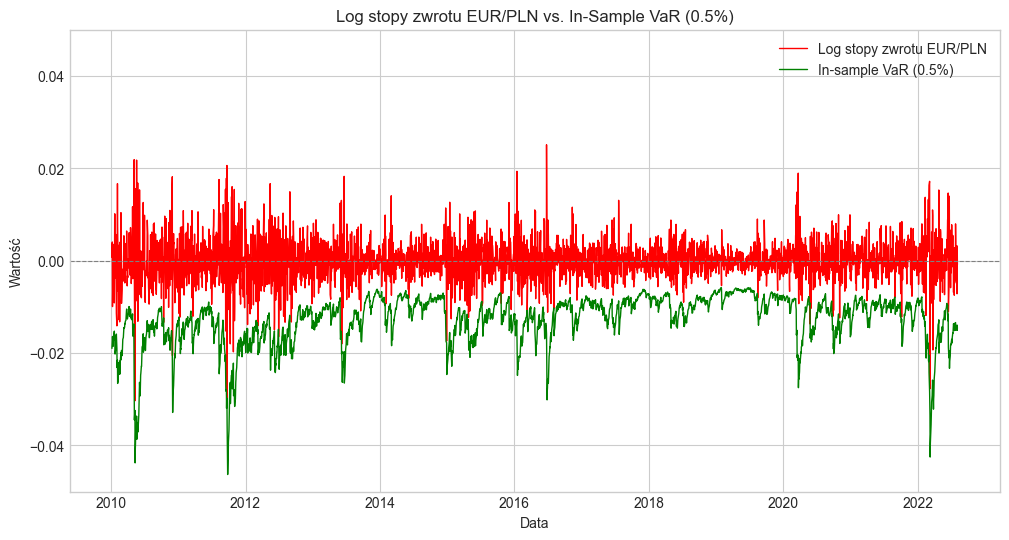

Liczba przekroczeń in-sample: 2
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.0615%


In [1084]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_garch11 = results_garch11.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS005_garch11'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_garch11.index, 'VaR_IS005_garch11'] = q005_empirical_dt_train * conditional_sigma_t_garch11

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS005_garch11'], color='green', linewidth=1, label='In-sample VaR (0.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.05, 0.05]) # skala
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS005_garch11']].dropna()
breaches_in_sample_IS005garch11 = (valid_comparison_in_sample['r'] < valid_comparison_in_sample['VaR_IS005_garch11']).sum()
num_obs_in_sample_var_IS005garch11 = len(valid_comparison_in_sample['VaR_IS005_garch11'])

if num_obs_in_sample_var_IS005garch11 > 0:
    breach_rate_in_sample_IS005garch11 = breaches_in_sample_IS005garch11 / num_obs_in_sample_var_IS005garch11
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS005garch11}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS005garch11}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS005garch11:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Spodziewamy się liczby przekroczeń nie większej niż 0.5%. Widzimy, że nasz model bardzo dobrze estymuje VaR in-sample - mamy tylko 2 przekroczenia.

### 3.2.1 EGARCH(1,1,1)

VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  
Data                                                                
2022-08-01  3250 -1.093553          -0.014421            -0.014572  
2022-08-02  3251  0.691648          -0.014456            -0.014186  
2022-08-03  3252 -1.603382          -0.013952            -0.014103  
2022-08-04  3253  0.680349          -0.015095            -0.014897  
2022-08-0

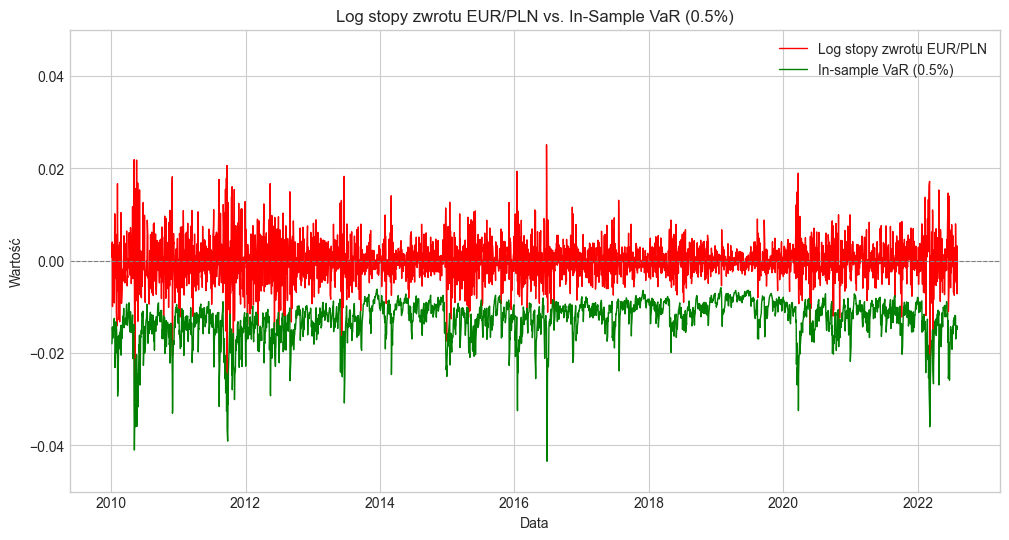

Liczba przekroczeń in-sample: 6
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.1844%


In [1085]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_egarch111 = results_egarch111.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS005_egarch111'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_egarch111.index, 'VaR_IS005_egarch111'] = q005_empirical_dt_train * conditional_sigma_t_egarch111

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS005_egarch111'], color='green', linewidth=1, label='In-sample VaR (0.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.05, 0.05]) 
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS005_egarch111']].dropna()
breaches_in_sample_IS005egarch111 = (valid_comparison_in_sample['r'] < valid_comparison_in_sample['VaR_IS005_egarch111']).sum()
num_obs_in_sample_var_IS005egarch111 = len(valid_comparison_in_sample['VaR_IS005_egarch111'])

if num_obs_in_sample_var_IS005egarch111 > 0:
    breach_rate_in_sample_IS005egarch111 = breaches_in_sample_IS005egarch111 / num_obs_in_sample_var_IS005egarch111
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS005egarch111}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS005egarch111}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS005egarch111:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Trochę więcej przekroczeń, ale nadal sytuacja wygląda dobrze (0.1844% < 0.5%).

### 3.2.5 GARCH-t

VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  \
Data                                                                 
2022-08-01  3250 -1.093553          -0.014421            -0.014572   
2022-08-02  3251  0.691648          -0.014456            -0.014186   
2022-08-03  3252 -1.603382          -0.013952            -0.014103   
2022-08-04  3253  0.680349          -0.015095            -0.014897   
202

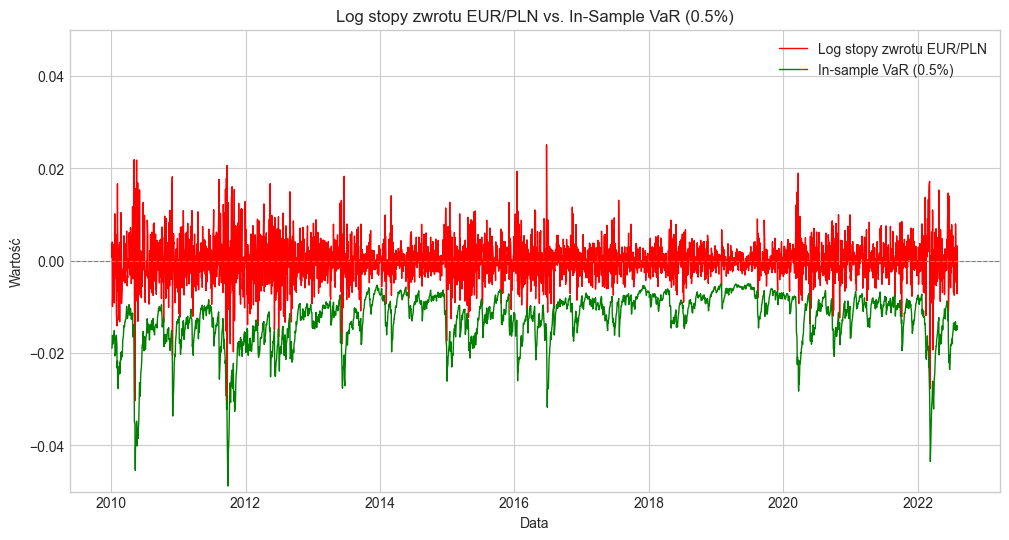

Liczba przekroczeń in-sample: 6
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.1844%


In [1086]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_garcht22 = results_garcht22.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS005_garcht22'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_garcht22.index, 'VaR_IS005_garcht22'] = q005_empirical_dt_train * conditional_sigma_t_garcht22

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS005_garcht22'], color='green', linewidth=1, label='In-sample VaR (0.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.05, 0.05]) 
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS005_garcht22']].dropna()
breaches_in_sample_IS005garcht22 = (valid_comparison_in_sample['r'] < valid_comparison_in_sample['VaR_IS005_garcht22']).sum()
num_obs_in_sample_var_IS005garcht22 = len(valid_comparison_in_sample['VaR_IS005_garcht22'])

if num_obs_in_sample_var_IS005garcht22 > 0:
    breach_rate_in_sample_IS005garcht22 = breaches_in_sample_IS005garcht22 / num_obs_in_sample_var_IS005garcht22
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS005garcht22}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS005garcht22}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS005garcht22:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Ten model wypada nieco gorzej

## 3.3 VaR in-sample 99.5%

Proces analizy jest taki sam jak dla $VaR_{0.5\%}$


Ważna uwaga: nieznacznie zmieniona skala na poniższych wykresach (z $\pm$ 0.5 do $\pm$ 0.6)

### 3.3.1 GARCH(1,1)

VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  \
Data                                                                 
2022-08-01  3250 -1.093553          -0.014421            -0.014572   
2022-08-02  3251  0.691648          -0.014456            -0.014186   
2022-08-03  3252 -1.603382          -0.013952            -0.014103   
2022-08-04  3253  0.680349          -0.015095            -0.014897   
202

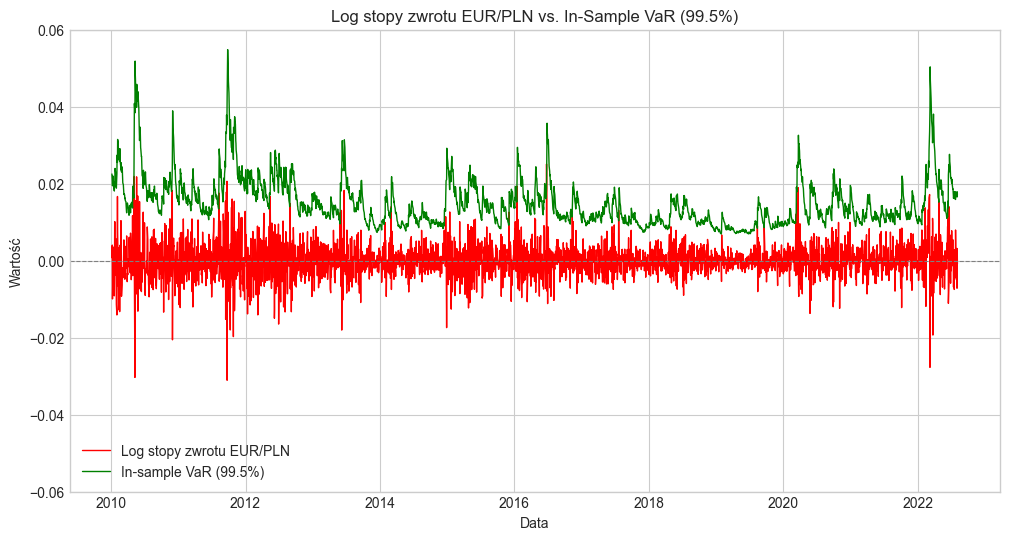

Liczba przekroczeń in-sample: 11
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.3380%


In [1087]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_garch11 = results_garch11.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS995_garch11'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_garch11.index, 'VaR_IS995_garch11'] = q995_empirical_dt_train * conditional_sigma_t_garch11

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS995_garch11'], color='green', linewidth=1, label='In-sample VaR (99.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.06, 0.06]) 
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (99.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS995_garch11']].dropna()
breaches_in_sample_IS995garch11 = (valid_comparison_in_sample['r'] > valid_comparison_in_sample['VaR_IS995_garch11']).sum()
num_obs_in_sample_var_IS995garch11 = len(valid_comparison_in_sample['VaR_IS995_garch11'])

if num_obs_in_sample_var_IS995garch11 > 0:
    breach_rate_in_sample_IS995garch11 = breaches_in_sample_IS995garch11 / num_obs_in_sample_var_IS995garch11
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS995garch11}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS995garch11}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS995garch11:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Widzimy znacząco większą liczbę przekroczeń niż przy $VaR_{0.5\%}$ dla tego samego modelu. Może to wskazywać na to, że gorzej estymowany jest prawy ogon rozkładu, czyli wzrosty log stóp zwrotu. Wzrost kursu oznacza deprecjację złotego względem euro. 

Niemniej nadal wskaźnik naruszeń jest niższy niż 0.5%.

### 3.3.2 EGARCH (1,1,1)


VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  \
Data                                                                 
2022-08-01  3250 -1.093553          -0.014421            -0.014572   
2022-08-02  3251  0.691648          -0.014456            -0.014186   
2022-08-03  3252 -1.603382          -0.013952            -0.014103   
2022-08-04  3253  0.680349          -0.015095            -0.014897   
202

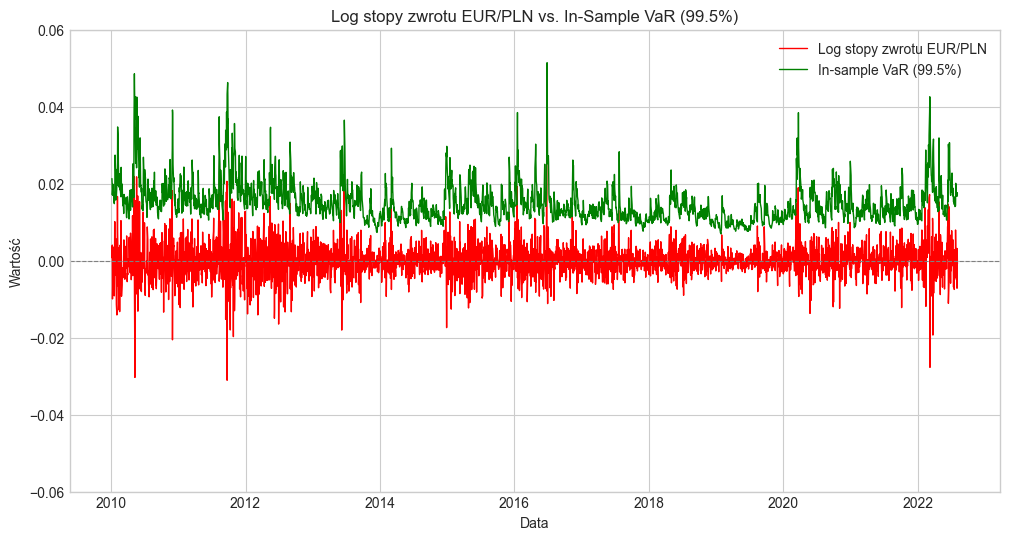

Liczba przekroczeń in-sample: 8
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.2459%


In [1088]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_egarch111 = results_egarch111.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS995_egarch111'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_egarch111.index, 'VaR_IS995_egarch111'] = q995_empirical_dt_train * conditional_sigma_t_egarch111

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS995_egarch111'], color='green', linewidth=1, label='In-sample VaR (99.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.06, 0.06]) 
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (99.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS995_egarch111']].dropna()
breaches_in_sample_IS995egarch111 = (valid_comparison_in_sample['r'] > valid_comparison_in_sample['VaR_IS995_egarch111']).sum()
num_obs_in_sample_var_IS995egarch111 = len(valid_comparison_in_sample['VaR_IS995_egarch111'])

if num_obs_in_sample_var_IS995egarch111 > 0:
    breach_rate_in_sample_IS995egarch111 = breaches_in_sample_IS995egarch111 / num_obs_in_sample_var_IS995egarch111
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS995egarch111}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS995egarch111}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS995egarch111:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Ponownie mamy gorszą precyzję oszacowań niż dla $VaR_{0.5\%}$

### 3.3.5 GARCH-t

VaR in-sample (ostatnie obserwacje):
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2022-08-01  4.742740   4.752490   4.707540    4.716780 4.716780 -0.004885   
2022-08-02  4.716380   4.738870   4.702980    4.731720 4.731720  0.003162   
2022-08-03  4.731730   4.736350   4.689230    4.697850 4.697850 -0.007184   
2022-08-04  4.698310   4.735780   4.696410    4.712490 4.712490  0.003111   
2022-08-05  4.710870   4.718630   4.702720    4.708370 4.708370 -0.000875   

             obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  \
Data                                                                 
2022-08-01  3250 -1.093553          -0.014421            -0.014572   
2022-08-02  3251  0.691648          -0.014456            -0.014186   
2022-08-03  3252 -1.603382          -0.013952            -0.014103   
2022-08-04  3253  0.680349          -0.015095            -0.014897   
202

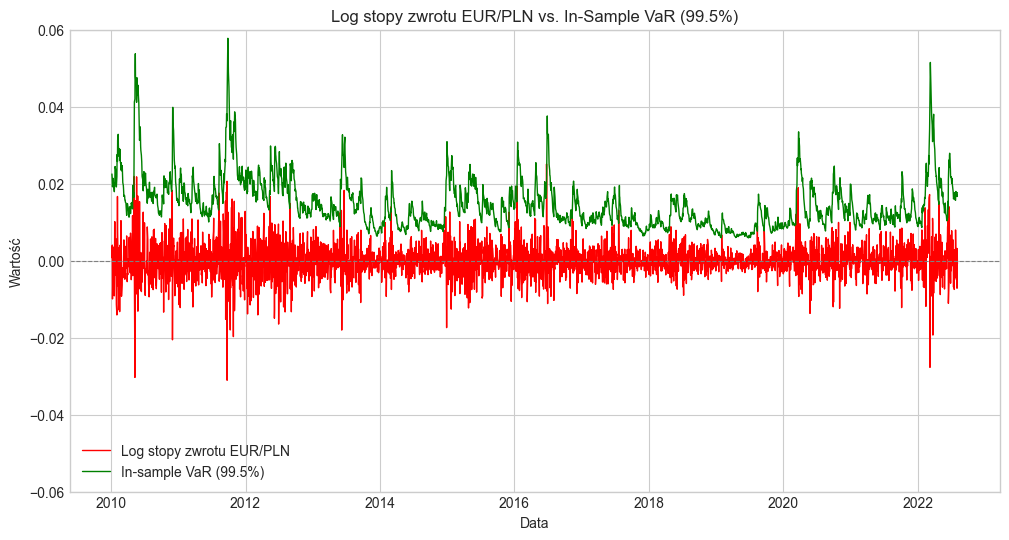

Liczba przekroczeń in-sample: 12
Liczba obserwacji dla VaR in-sample: 3254
Wskaźnik naruszeń in-sample: 0.3688%


In [1089]:
# Kwantyle empiryczne już mamy obliczone

# Warunkowa zmienność z wcześniej oszacowanego modelu
conditional_sigma_t_garcht22 = results_garcht22.conditional_volatility

# Kopiujemy, żeby usunąć warningi
dt_train = dt_train.copy()
# Ustawienie indeksów zmiennych
dt_train['VaR_IS995_garcht22'] = np.nan # inicjalizacja kolumny
dt_train.loc[conditional_sigma_t_garcht22.index, 'VaR_IS995_garcht22'] = q995_empirical_dt_train * conditional_sigma_t_garcht22

print("VaR in-sample (ostatnie obserwacje):")
print(dt_train.tail())

# Wykres
plt.figure(figsize=(12, 6))
plt.plot( dt_train['r'], color='red', linewidth=1, label='Log stopy zwrotu EUR/PLN')
plt.plot( dt_train['VaR_IS995_garcht22'], color='green', linewidth=1, label='In-sample VaR (99.5%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.06, 0.06]) 
plt.title('Log stopy zwrotu EUR/PLN vs. In-Sample VaR (99.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()

# Tylko nie-NaN i korespondujące wartości
valid_comparison_in_sample = dt_train[['r', 'VaR_IS995_garcht22']].dropna()
breaches_in_sample_IS995garcht22 = (valid_comparison_in_sample['r'] > valid_comparison_in_sample['VaR_IS995_garcht22']).sum()
num_obs_in_sample_var_IS995garcht22 = len(valid_comparison_in_sample['VaR_IS995_garcht22'])

if num_obs_in_sample_var_IS995garcht22 > 0:
    breach_rate_in_sample_IS995garcht22 = breaches_in_sample_IS995garcht22 / num_obs_in_sample_var_IS995garcht22
    print(f"Liczba przekroczeń in-sample: {breaches_in_sample_IS995garcht22}")
    print(f"Liczba obserwacji dla VaR in-sample: {num_obs_in_sample_var_IS995garcht22}")
    print(f"Wskaźnik naruszeń in-sample: {breach_rate_in_sample_IS995garcht22:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR in-sample.")

Stosunkowo wiele przekroczeń, ale nadal wskaźnik poniżej 0.5%

## 3.4 Podsumowanie VaR in-sample

Zestawienie przekroczeń dla powyższych modeli. Najpierw dla $VaR_{0.5\%}$

In [1090]:
print("Przekroczenia VaR(0.5%) dla GARCH(1,1):", breaches_in_sample_IS005garch11)
print(f"Wskaźnik naruszeń VaR(0.5%) dla GARCH(1,1): {breach_rate_in_sample_IS005garch11:.4%}")

print("\nPrzekroczenia VaR(0.5%) dla EGARCH(1,1,1):", breaches_in_sample_IS005egarch111)
print(f"Wskaźnik naruszeń VaR(0.5%) dla EGARCH(1,1,1): {breach_rate_in_sample_IS005egarch111:.4%}")

print("\nPrzekroczenia VaR(0.5%) dla GARCH-t:", breaches_in_sample_IS005garcht22)
print(f"Wskaźnik naruszeń VaR(0.5%) dla GARCH-t: {breach_rate_in_sample_IS005garcht22:.4%}")

Przekroczenia VaR(0.5%) dla GARCH(1,1): 2
Wskaźnik naruszeń VaR(0.5%) dla GARCH(1,1): 0.0615%

Przekroczenia VaR(0.5%) dla EGARCH(1,1,1): 6
Wskaźnik naruszeń VaR(0.5%) dla EGARCH(1,1,1): 0.1844%

Przekroczenia VaR(0.5%) dla GARCH-t: 6
Wskaźnik naruszeń VaR(0.5%) dla GARCH-t: 0.1844%


Widzimy, że najlepszy model to GARCH(1,1)

Zestawienie przekroczeń dla $VaR_{0.5\%}$

In [1091]:
print("Przekroczenia VaR(99.5%) dla GARCH(1,1):", breaches_in_sample_IS995garch11)
print(f"Wskaźnik naruszeń VaR(99.5%) dla GARCH(1,1): {breach_rate_in_sample_IS995garch11:.4%}")

print("\nPrzekroczenia VaR(99.5%) dla EGARCH(1,1,1):", breaches_in_sample_IS995egarch111)
print(f"Wskaźnik naruszeń VaR(99.5%) dla EGARCH(1,1,1): {breach_rate_in_sample_IS995egarch111:.4%}")

print("\nPrzekroczenia VaR(99.5%) dla GARCH-t:", breaches_in_sample_IS995garcht22)
print(f"Wskaźnik naruszeń VaR(99.5%) dla GARCH-t: {breach_rate_in_sample_IS995garcht22:.4%}")

Przekroczenia VaR(99.5%) dla GARCH(1,1): 11
Wskaźnik naruszeń VaR(99.5%) dla GARCH(1,1): 0.3380%

Przekroczenia VaR(99.5%) dla EGARCH(1,1,1): 8
Wskaźnik naruszeń VaR(99.5%) dla EGARCH(1,1,1): 0.2459%

Przekroczenia VaR(99.5%) dla GARCH-t: 12
Wskaźnik naruszeń VaR(99.5%) dla GARCH-t: 0.3688%


Tu z kolei widzimy pogorszenie oszacowania dla wszystkich modeli. Szczególnie jest to zauważalne dla GARCH(1,1). Najlepszym model w tym przypadku jest EGARCH(1,1,1)

## 3.4 VaR out-of-sample 0.5%

Będziemy korzystać z prognoz modeli dotyczących warunkowych zmienności. W diagnostyce często patrzy się na bezwarunkową zmienność (uzależniona od struktury modelu), warunkową zmienność i jej prognozę. W naszej analizie nie będziemy się skupiać na badaniu prognoz samych zmienności, ale przejdziemy od razu do wykorzystania wyników modeli przy prognozach VaR.

Metodą prognozy jest *rolling-window*. Mając zbiór treningowy będziemy poszerzać go o obserwacje ze zbioru testowego, każdorazowo estymując model i przeprowadzając prognozę aż wyczerpiemy cały zbiór testowy. To podejście sprawdza jak stabilne są prognozy modelu przy zmieniającej się próbce, ale przejawia ryzyko *data leakage*.

Dodajmy to zbioru testowego i pełnego log zwroty

In [1092]:
# Logarytmiczne stopy zwrotu
dt = dt.copy() # dla uciszenia warnings
dt['r'] = np.log(dt['Kurs']).diff()
dt

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2010-01-04,4.104100,4.115600,4.068400,4.075100,4.075100,NaN
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953
...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935


In [1093]:
# Usuwamy NaN powstały z utworzenia stóp zwrotu
dt=dt.dropna()
dt

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353
...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935


In [1094]:
# Logarytmiczne stopy zwrotu

dt_test = dt_test.copy() # dla uciszenia warnings

dt_test['r'] = np.log(dt_test['Kurs']).diff()
dt_test

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2022-08-08,4.712950,4.714640,4.693580,4.697440,4.697440,NaN
2022-08-09,4.696980,4.711330,4.696370,4.700610,4.700610,0.000675
2022-08-10,4.700980,4.716830,4.669600,4.676820,4.676820,-0.005074
2022-08-11,4.677150,4.688920,4.666240,4.685870,4.685870,0.001933
2022-08-12,4.685870,4.689940,4.654940,4.659340,4.659340,-0.005678
...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935


In [1095]:
# Usuwamy NaN powstały z utworzenia stóp zwrotu
dt_test=dt_test.dropna()
dt_test

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r
Data,,,,,,
2022-08-09,4.696980,4.711330,4.696370,4.700610,4.700610,0.000675
2022-08-10,4.700980,4.716830,4.669600,4.676820,4.676820,-0.005074
2022-08-11,4.677150,4.688920,4.666240,4.685870,4.685870,0.001933
2022-08-12,4.685870,4.689940,4.654940,4.659340,4.659340,-0.005678
2022-08-15,4.662190,4.694140,4.658630,4.684390,4.684390,0.005362
...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935


In [1096]:
print("dt_train.head()")
print(dt_train.head())

print("\ndt_train.tail()")
print(dt_train.tail())

print("\ndt_test.tail()")
print(dt_test.head())

print("\ndt_test.tail()")
print(dt_test.tail())

dt_train.head()
            Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Kurs         r  \
Data                                                                        
2010-01-05  4.070600   4.095500   4.064800    4.090100 4.090100  0.003674   
2010-01-06  4.090200   4.101500   4.086800    4.093000 4.093000  0.000709   
2010-01-07  4.095700   4.126700   4.089900    4.109500 4.109500  0.004023   
2010-01-08  4.107900   4.115800   4.065000    4.068800 4.068800 -0.009953   
2010-01-11  4.057400   4.069400   4.040300    4.063300 4.063300 -0.001353   

            obs      rstd  VaR_IS005_garch11  VaR_IS005_egarch111  \
Data                                                                
2010-01-05    1  0.805160          -0.019004            -0.018004   
2010-01-06    2  0.147376          -0.018155            -0.017048   
2010-01-07    3  0.882584          -0.016976            -0.014427   
2010-01-08    4 -2.217706          -0.016422            -0.014913   
2010-01-11    5 -0.309899     

In [1097]:
dt = dt.copy()
dt_train = dt_train.copy()
dt_test = dt_test.copy()

dt['Data_helper'] = dt.index
dt_train['Data_helper'] = dt_train.index
dt_test['Data_helper'] = dt_test.index

In [1098]:
dt

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,Data_helper
Data,,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674,2010-01-05
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709,2010-01-06
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023,2010-01-07
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953,2010-01-08
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353,2010-01-11
...,...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317,2025-09-24
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763,2025-09-25
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935,2025-09-26


### 3.4.1 GARCH(1,1)

In [ ]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll005_garch11 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH(1,1) VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std()
    q005_rolling_empirical = tmp_r_std_rolling.quantile(0.005)

    garch11_input_rolling = tmp_r_clean 
    if len(garch11_input_rolling) < 50:
        continue

    try:
        model_garch11_rolling = arch_model(garch11_input_rolling,
                                           vol='GARCH', mean='zero',
                                           p=1, q=1, rescale=False)
        results_garch11_rolling = model_garch11_rolling.fit(disp='off', show_warning=False) 
       
        forecast_garch11_rolling = results_garch11_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_garch11_rolling = np.sqrt(forecast_garch11_rolling.variance.iloc[-1, 0])

        VaR_OOSroll005_garch11[i] = q005_rolling_empirical * sigma_forecast_garch11_rolling

    except Exception as e:
        # Można dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll005_garch11'] = VaR_OOSroll005_garch11


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH(1,1) VaR 0.5%: 100%|██████████| 813/813 [00:14<00:00, 55.91it/s]


Out-of-sample VaR zakończony w 14.55 sekund.


Inna skala wykresu w stosunku do in-sample

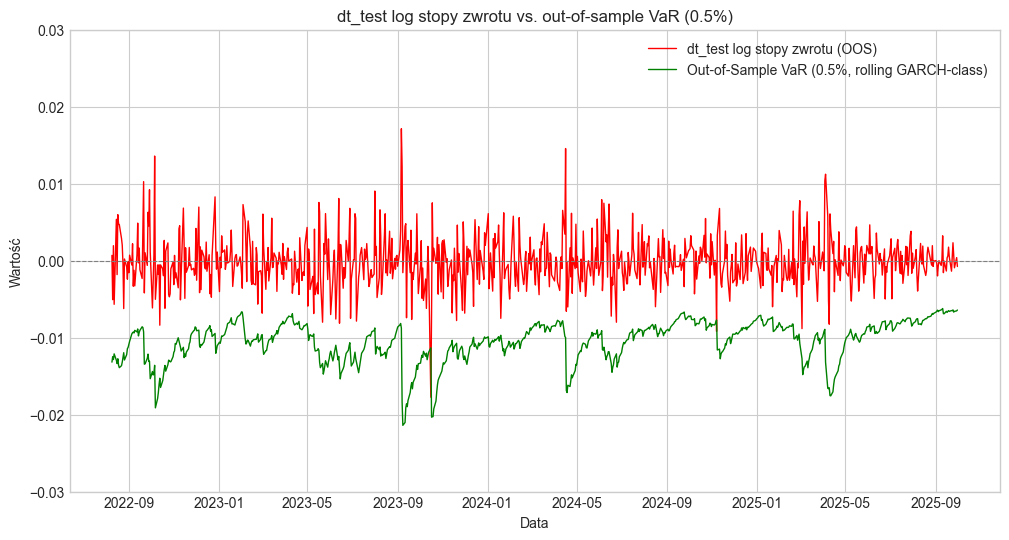

Liczba przekroczeń out-of-sample: 2
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 0.2460%


In [1100]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll005_garch11'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll005_garch11']].dropna()
breaches_oos_OOSroll005_garch11 = (valid_comparison_oos['r'] < valid_comparison_oos['VaR_OOSroll005_garch11']).sum()
num_observations_oos_var_OOSroll005_garch11 = len(valid_comparison_oos['VaR_OOSroll005_garch11'])

if num_observations_oos_var_OOSroll005_garch11 > 0:
    breach_rate_oos_OOSroll005_garch11 = breaches_oos_OOSroll005_garch11 / num_observations_oos_var_OOSroll005_garch11
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll005_garch11}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll005_garch11}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll005_garch11:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

Widzimy, że liczba przekroczeń jest niska, co wskazuje na dobrą jakość prognoz.

In [1102]:
dt_test['Data'] = dt_test['Data_helper']
dt_test['Data']= pd.to_datetime(dt_test['Data'])
dt_test = dt_test.set_index('Data')
dt_test

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,Data_helper,VaR_OOSroll005_garch11
Data,,,,,,,,
2022-08-09,4.696980,4.711330,4.696370,4.700610,4.700610,0.000675,2022-08-09,-0.013188
2022-08-10,4.700980,4.716830,4.669600,4.676820,4.676820,-0.005074,2022-08-10,-0.012489
2022-08-11,4.677150,4.688920,4.666240,4.685870,4.685870,0.001933,2022-08-11,-0.012850
2022-08-12,4.685870,4.689940,4.654940,4.659340,4.659340,-0.005678,2022-08-12,-0.012116
2022-08-15,4.662190,4.694140,4.658630,4.684390,4.684390,0.005362,2022-08-15,-0.012945
...,...,...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317,2025-09-24,-0.006406
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763,2025-09-25,-0.006692
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935,2025-09-26,-0.006596


### 3.4.2 EGARCH(1,1,1)

In [1103]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll005_egarch111 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH(1,1) VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    #tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std() # braki zbieżności
    q005_rolling_empirical = tmp_r_clean.quantile(0.005)

    egarch111_input_rolling = tmp_r_clean 
    if len(egarch111_input_rolling) < 50:
        continue

    try:
        model_egarch111_rolling = arch_model(egarch111_input_rolling,mean='zero', vol='EGARCH', dist='StudentsT', p=1, o=1, q=1, rescale=True)# p, o, q odpowiadają oznaczeniom z równania wyżej
        
            ##model_egarch111 = arch_model(dt_train['r'], mean='zero', vol='EGARCH', dist='StudentsT', p=1, o=1, q=1, rescale=False)# p, o, q odpowiadają oznaczeniom z równania wyżej

        results_egarch111_rolling = model_egarch111_rolling.fit(disp='off', show_warning=False) 
       
        forecast_egarch111_rolling = results_egarch111_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_egarch111_rolling = np.sqrt(forecast_egarch111_rolling.variance.iloc[-1, 0])

        VaR_OOSroll005_egarch111[i] = q005_rolling_empirical * sigma_forecast_egarch111_rolling

    except Exception as e:
        # Możesz dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll005_egarch111'] = VaR_OOSroll005_egarch111


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH(1,1) VaR 0.5%: 100%|██████████| 813/813 [00:38<00:00, 21.38it/s]


Out-of-sample VaR zakończony w 38.03 sekund.


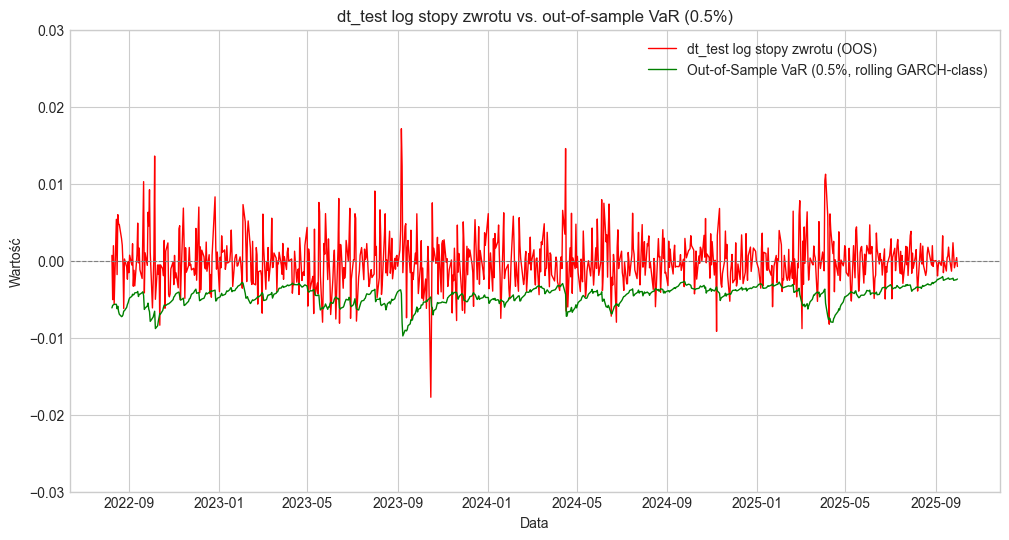

Liczba przekroczeń out-of-sample: 50
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 6.1501%


In [1104]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll005_egarch111'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll005_egarch111']].dropna()
breaches_oos_OOSroll005_egarch111 = (valid_comparison_oos['r'] < valid_comparison_oos['VaR_OOSroll005_egarch111']).sum()
num_observations_oos_var_OOSroll005_egarch111 = len(valid_comparison_oos['VaR_OOSroll005_egarch111'])

if num_observations_oos_var_OOSroll005_egarch111 > 0:
    breach_rate_oos_OOSroll005_egarch111 = breaches_oos_OOSroll005_egarch111 / num_observations_oos_var_OOSroll005_egarch111
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll005_egarch111}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll005_egarch111}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll005_egarch111:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

W tym podejściu musieliśmy skorzystać z `rescale=True` ze względu na problemy ze zbieżnością modelu. Zapewne wskazuje to na nie najlepiej dopasowane dane do tego modelu. Widzimy, że przy zmieniającej się próbce i dużej liczbie prognoz model analitycznie skomplikowany jak EGARCH nie jest stabilny. Mamy zdecydowanie większą liczbę przekroczeń niż in-sample.

### 3.4.5 GARCH-t

In [1105]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll005_garcht22 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH-in-mean VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std()
    q005_rolling_empirical = tmp_r_std_rolling.quantile(0.005)

    garcht22_input_rolling = tmp_r_clean 
    if len(garcht22_input_rolling) < 50:
        continue

    try:
        model_garcht22_rolling = arch_model(garcht22_input_rolling,mean='zero', vol='garch', p=2, q=2, dist='t', rescale=False)


        results_garcht22_rolling = model_garcht22_rolling.fit(disp='off', show_warning=False) 

        forecast_garcht22_rolling = results_garcht22_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_garcht22_rolling = np.sqrt(forecast_garcht22_rolling.variance.iloc[-1, 0])

        VaR_OOSroll005_garcht22[i] = q005_rolling_empirical * sigma_forecast_garcht22_rolling

    except Exception as e:
        # Możesz dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll005_garcht22'] = VaR_OOSroll005_garcht22


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH-in-mean VaR 0.5%: 100%|██████████| 813/813 [00:15<00:00, 51.08it/s]


Out-of-sample VaR zakończony w 15.92 sekund.


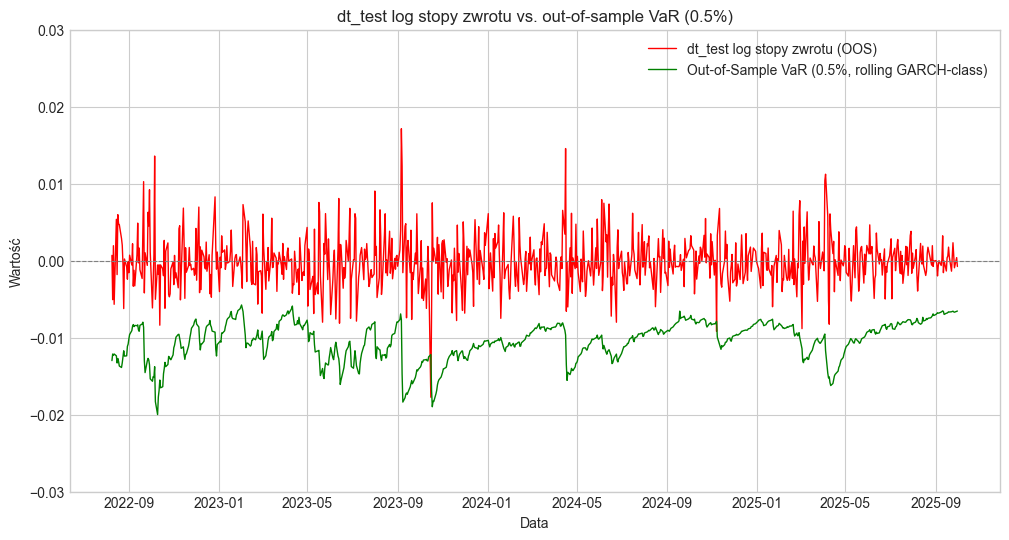

Liczba przekroczeń out-of-sample: 2
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 0.2460%


In [1106]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll005_garcht22'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll005_garcht22']].dropna()
breaches_oos_OOSroll005_garcht22 = (valid_comparison_oos['r'] < valid_comparison_oos['VaR_OOSroll005_garcht22']).sum()
num_observations_oos_var_OOSroll005_garcht22 = len(valid_comparison_oos['VaR_OOSroll005_garcht22'])

if num_observations_oos_var_OOSroll005_garcht22 > 0:
    breach_rate_oos_OOSroll005_garcht22 = breaches_oos_OOSroll005_garcht22 / num_observations_oos_var_OOSroll005_garcht22
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll005_garcht22}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll005_garcht22}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll005_garcht22:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

Model prognozuje bardzo dobrze relatywnie do innych modeli

## 3.5 VaR out-of-sample 99.5%

### 3.5.1 GARCH(1,1)

In [1107]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll995_garch11 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH(1,1) VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std()
    q995_rolling_empirical = tmp_r_std_rolling.quantile(0.995)

    garch11_input_rolling = tmp_r_clean 
    if len(garch11_input_rolling) < 50:
        continue

    try:
        model_garch11_rolling = arch_model(garch11_input_rolling,
                                           vol='GARCH', mean='zero',
                                           p=1, q=1, rescale=False)
        results_garch11_rolling = model_garch11_rolling.fit(disp='off', show_warning=False) 
       
        forecast_garch11_rolling = results_garch11_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_garch11_rolling = np.sqrt(forecast_garch11_rolling.variance.iloc[-1, 0])

        VaR_OOSroll995_garch11[i] = q995_rolling_empirical * sigma_forecast_garch11_rolling

    except Exception as e:
        # Możesz dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll995_garch11'] = VaR_OOSroll995_garch11


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH(1,1) VaR 0.5%: 100%|██████████| 813/813 [00:14<00:00, 57.13it/s]


Out-of-sample VaR zakończony w 14.23 sekund.


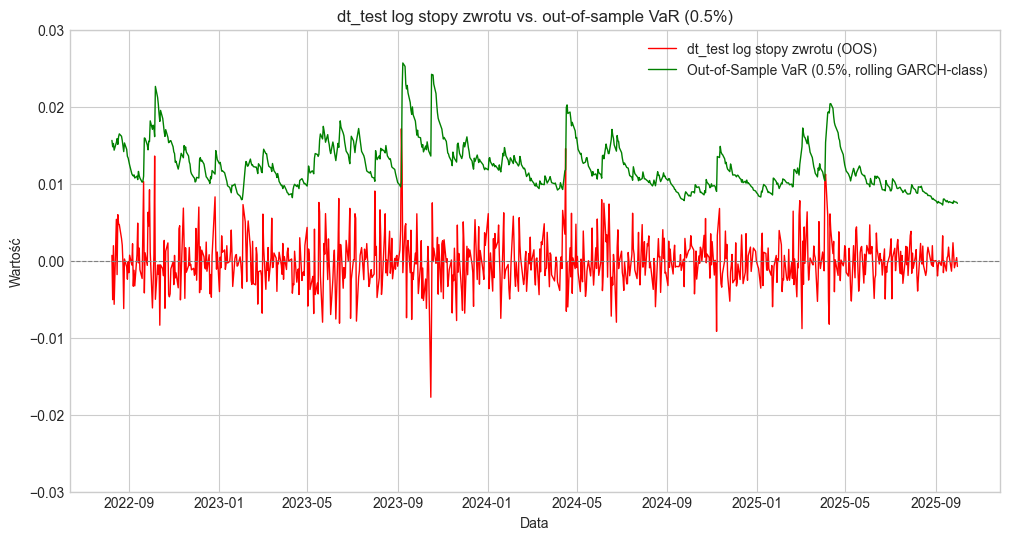

Liczba przekroczeń out-of-sample: 3
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 0.3690%


In [1108]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll995_garch11'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll995_garch11']].dropna()
breaches_oos_OOSroll995_garch11 = (valid_comparison_oos['r'] > valid_comparison_oos['VaR_OOSroll995_garch11']).sum()
num_observations_oos_var_OOSroll995_garch11 = len(valid_comparison_oos['VaR_OOSroll995_garch11'])

if num_observations_oos_var_OOSroll995_garch11 > 0:
    breach_rate_oos_OOSroll995_garch11 = breaches_oos_OOSroll995_garch11 / num_observations_oos_var_OOSroll995_garch11
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll995_garch11}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll995_garch11}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll995_garch11:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

Ponownie widzimy dobrą jakość prognoz

### 3.5.2 EGARCH(1,1,1)

In [1109]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll995_egarch111 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH(1,1) VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    #tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std() # braki zbieżności
    q995_rolling_empirical = tmp_r_clean.quantile(0.995)

    egarch111_input_rolling = tmp_r_clean 
    if len(egarch111_input_rolling) < 50:
        continue

    try:
        model_egarch111_rolling = arch_model(egarch111_input_rolling,mean='zero', vol='EGARCH', dist='StudentsT', p=1, o=1, q=1, rescale=True)# p, o, q odpowiadają oznaczeniom z równania wyżej
        
            ##model_egarch111 = arch_model(dt_train['r'], mean='zero', vol='EGARCH', dist='StudentsT', p=1, o=1, q=1, rescale=False)# p, o, q odpowiadają oznaczeniom z równania wyżej

        results_egarch111_rolling = model_egarch111_rolling.fit(disp='off', show_warning=False) 
       
        forecast_egarch111_rolling = results_egarch111_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_egarch111_rolling = np.sqrt(forecast_egarch111_rolling.variance.iloc[-1, 0])

        VaR_OOSroll995_egarch111[i] = q995_rolling_empirical * sigma_forecast_egarch111_rolling

    except Exception as e:
        # Możesz dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll995_egarch111'] = VaR_OOSroll995_egarch111


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH(1,1) VaR 0.5%: 100%|██████████| 813/813 [00:39<00:00, 20.71it/s]


Out-of-sample VaR zakończony w 39.26 sekund.


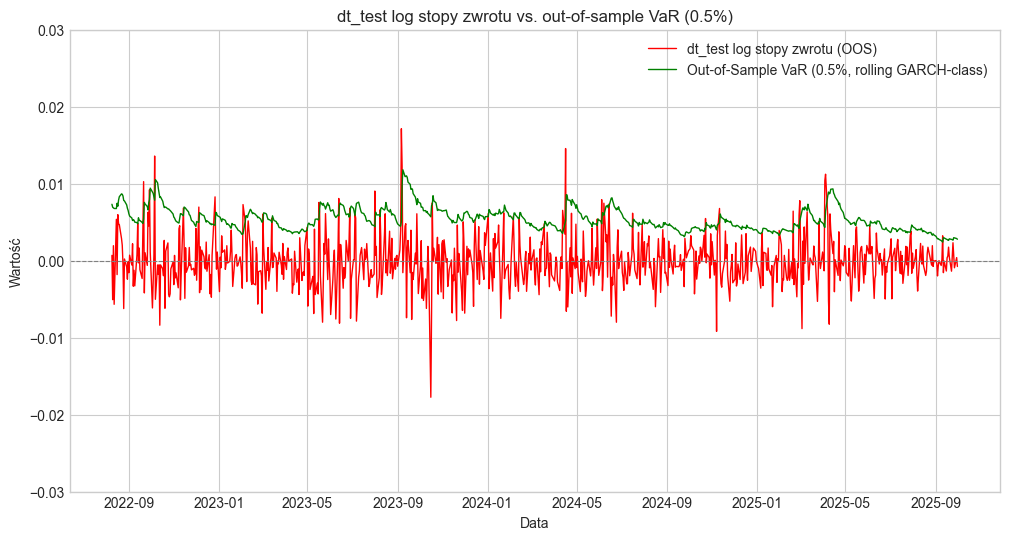

Liczba przekroczeń out-of-sample: 43
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 5.2891%


In [1110]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll995_egarch111'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll995_egarch111']].dropna()
breaches_oos_OOSroll995_egarch111 = (valid_comparison_oos['r'] > valid_comparison_oos['VaR_OOSroll995_egarch111']).sum()
num_observations_oos_var_OOSroll995_egarch111 = len(valid_comparison_oos['VaR_OOSroll995_egarch111'])

if num_observations_oos_var_OOSroll995_egarch111 > 0:
    breach_rate_oos_OOSroll995_egarch111 = breaches_oos_OOSroll995_egarch111 / num_observations_oos_var_OOSroll995_egarch111
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll995_egarch111}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll995_egarch111}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll995_egarch111:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

Lepiej niż dla kwantyla 0.5%, ale widać, że problemy numeryczne modelu nie skutkują stabilnymi prognozami. Zapewna warto by było dokładniej zbadać dostępne rozwiązania w takich sytuacjach, czy ingerować w kod źródłowy.

### 3.5.5 GARCH-t

In [1111]:

dt_test = dt_test.copy()
dt_test.reset_index(drop=True, inplace=True)

num_oos_days = len(dt_test)
VaR_OOSroll995_garcht22 = np.full(num_oos_days, np.nan)

estimation_window_start_date = pd.to_datetime("2010-01-05") 

print(f"Rozpoczęcie out-of-sample VaR estymacji dla {num_oos_days} dni (podejście rolling window)...")
start_time_loop = time.time()

for i in tqdm(range(num_oos_days), desc="Rolling GARCH-in-mean VaR 0.5%"):
    
    current_forecast_target_date = dt_test['Data_helper'].iloc[i]
    
    tmp_estimation_data = dt[
        (dt['Data_helper'] < current_forecast_target_date) &
        (dt['Data_helper'] >= estimation_window_start_date)
    ].copy()

    if len(tmp_estimation_data) < 50:
        continue

    tmp_r_clean = tmp_estimation_data['r'].dropna()
    if len(tmp_r_clean) < 50: 
        continue
    
    tmp_r_std_rolling = (tmp_r_clean - tmp_r_clean.mean()) / tmp_r_clean.std()
    q995_rolling_empirical = tmp_r_std_rolling.quantile(0.995)

    garcht22_input_rolling = tmp_r_clean 
    if len(garcht22_input_rolling) < 50:
        continue

    try:
        model_garcht22_rolling = arch_model(garcht22_input_rolling,mean='zero', vol='garch', p=2, q=2, dist='t', rescale=False)


        results_garcht22_rolling = model_garcht22_rolling.fit(disp='off', show_warning=False) 

        forecast_garcht22_rolling = results_garcht22_rolling.forecast(horizon=1, reindex=False)
        sigma_forecast_garcht22_rolling = np.sqrt(forecast_garcht22_rolling.variance.iloc[-1, 0])

        VaR_OOSroll995_garcht22[i] = q995_rolling_empirical * sigma_forecast_garcht22_rolling

    except Exception as e:
        # Możesz dopisać debug do loga jeśli coś się sypie, ale tqdm nie lubi printów
        pass

end_time_loop = time.time()
print(f"\nOut-of-sample VaR zakończony w {end_time_loop - start_time_loop:.2f} sekund.")

dt_test['VaR_OOSroll995_garcht22'] = VaR_OOSroll995_garcht22


Rozpoczęcie out-of-sample VaR estymacji dla 813 dni (podejście rolling window)...


Rolling GARCH-in-mean VaR 0.5%: 100%|██████████| 813/813 [00:16<00:00, 49.22it/s]


Out-of-sample VaR zakończony w 16.52 sekund.


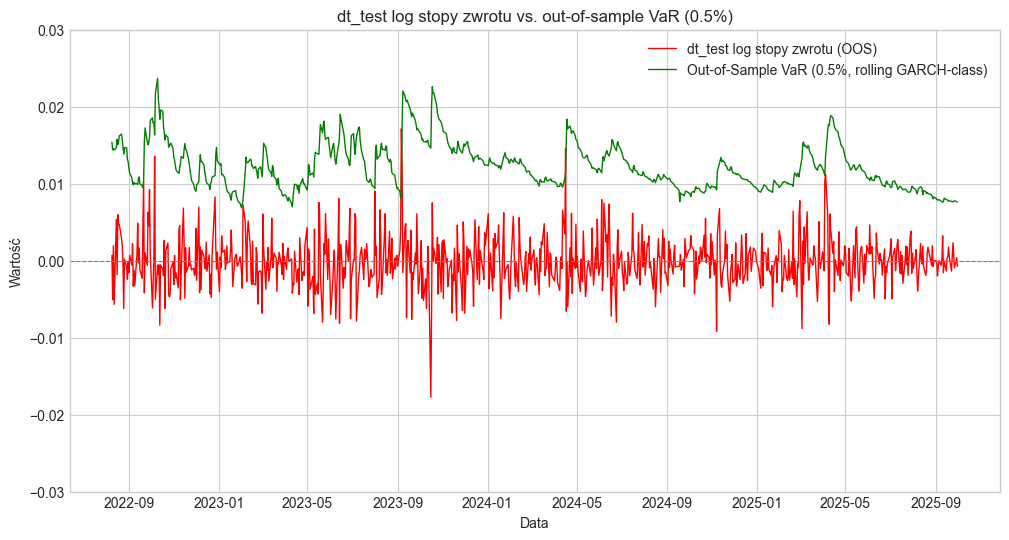

Liczba przekroczeń out-of-sample: 2
Liczba obserwacji dla VaR out-of-sample: 813
Wskaźnik naruszeń out-of-sample: 0.2460%


In [1112]:
plt.figure(figsize=(12, 6))
plt.plot(dt_test['Data_helper'], dt_test['r'], color='red', linewidth=1, label='dt_test log stopy zwrotu (OOS)')
plt.plot(dt_test['Data_helper'], dt_test['VaR_OOSroll995_garcht22'], color='green', linewidth=1, label='Out-of-Sample VaR (0.5%, rolling GARCH-class)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.ylim([-0.03, 0.03]) 
plt.title('dt_test log stopy zwrotu vs. out-of-sample VaR (0.5%)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.legend()
plt.show()


# Tylko non-NaN i odpowiednie indeksy
valid_comparison_oos = dt_test[['r', 'VaR_OOSroll995_garcht22']].dropna()
breaches_oos_OOSroll995_garcht22 = (valid_comparison_oos['r'] > valid_comparison_oos['VaR_OOSroll995_garcht22']).sum()
num_observations_oos_var_OOSroll995_garcht22 = len(valid_comparison_oos['VaR_OOSroll995_garcht22'])

if num_observations_oos_var_OOSroll995_garcht22 > 0:
    breach_rate_oos_OOSroll995_garcht22 = breaches_oos_OOSroll995_garcht22 / num_observations_oos_var_OOSroll995_garcht22
    print(f"Liczba przekroczeń out-of-sample: {breaches_oos_OOSroll995_garcht22}")
    print(f"Liczba obserwacji dla VaR out-of-sample: {num_observations_oos_var_OOSroll995_garcht22}")
    print(f"Wskaźnik naruszeń out-of-sample: {breach_rate_oos_OOSroll995_garcht22:.4%}")
else:
    print("Brak odpowiednich obserwacji dla porównania z VaR out-of-sample.")

Model ponownie ma bardzo dobre prognozy

## 3.6 Podsumowanie VaR out-of-sample

Spójrzmy na liczbę przekroczeń dla obu estymowanych $VaR$

In [1113]:
print("Przekroczenia VaR(0.5%) dla GARCH(1,1):", breaches_oos_OOSroll005_garch11)
print(f"Wskaźnik naruszeń VaR(0.5%) dla GARCH(1,1): {breach_rate_oos_OOSroll005_garch11:.4%}")

print("\nPrzekroczenia VaR(0.5%) dla EGARCH(1,1,1):", breaches_oos_OOSroll005_egarch111)
print(f"Wskaźnik naruszeń VaR(0.5%) dla EGARCH(1,1,1): {breach_rate_oos_OOSroll005_egarch111:.4%}")

print("\nPrzekroczenia VaR(0.5%) dla GARCH-t:", breaches_oos_OOSroll005_garcht22)
print(f"Wskaźnik naruszeń VaR(0.5%) dla GARCH-t: {breach_rate_oos_OOSroll005_garcht22:.4%}")

Przekroczenia VaR(0.5%) dla GARCH(1,1): 2
Wskaźnik naruszeń VaR(0.5%) dla GARCH(1,1): 0.2460%

Przekroczenia VaR(0.5%) dla EGARCH(1,1,1): 50
Wskaźnik naruszeń VaR(0.5%) dla EGARCH(1,1,1): 6.1501%

Przekroczenia VaR(0.5%) dla GARCH-t: 2
Wskaźnik naruszeń VaR(0.5%) dla GARCH-t: 0.2460%


In [1114]:
print("Przekroczenia VaR(99.5%) dla GARCH(1,1):", breaches_oos_OOSroll995_garch11)
print(f"Wskaźnik naruszeń VaR(99.5%) dla GARCH(1,1): {breach_rate_oos_OOSroll995_garch11:.4%}")

print("\nPrzekroczenia VaR(99.5%) dla EGARCH(1,1,1):", breaches_oos_OOSroll995_egarch111)
print(f"Wskaźnik naruszeń VaR(99.5%) dla EGARCH(1,1,1): {breach_rate_oos_OOSroll995_egarch111:.4%}")

print("\nPrzekroczenia VaR(99.5%) dla GARCH-t:", breaches_oos_OOSroll995_garcht22)
print(f"Wskaźnik naruszeń VaR(99.5%) dla GARCH-t: {breach_rate_oos_OOSroll995_garcht22:.4%}")

Przekroczenia VaR(99.5%) dla GARCH(1,1): 3
Wskaźnik naruszeń VaR(99.5%) dla GARCH(1,1): 0.3690%

Przekroczenia VaR(99.5%) dla EGARCH(1,1,1): 43
Wskaźnik naruszeń VaR(99.5%) dla EGARCH(1,1,1): 5.2891%

Przekroczenia VaR(99.5%) dla GARCH-t: 2
Wskaźnik naruszeń VaR(99.5%) dla GARCH-t: 0.2460%


Widzimy, że EGARCH(1,1,1) wypada zdecydowanie najgorzej. Tutaj zapewne problemy są techniczne (kwestia *rescale*)

GARCH(1,1) i GARCH-t mają bardzo podobną jakość prognoz. Nieznacznie lepszy jest GARCH-t, który dzięki rozkładowi t-Studenta lepiej modeluje naszą leptokurtyczną badaną zmienną.

> Ze względu na te wyniki skorzystamy z **GARCH-t** do prognozy obu $VaR$ w następnej sekcji

# 4. Prognoza VaR

Estymujemy jeszcze raz model GARCH-t - teraz na całym dostępnym zbiorze danych. Chcemy mieć możliwie najwięcej obserwacji zanim przejdziemy do prognozy na przyszłość.

Bazujemy na standardowych procedurach opisanych np. w [Elements of Financial Risk Management](https://unidel.edu.ng/focelibrary/books/Elements%20of%20Financial%20Risk%20Management.pdf), [Quantitative Risk Management](https://dn720002.ca.archive.org/0/items/quant_books/Quantitative%20Risk%20Management%20-%20A.%20J.%20McNeil%2C%20R.%20Frey.pdf) oraz [Analysis of financial time series](https://agorism.dev/book/finance/time-series/Ruey%20S.%20Tsay%20-%20Analysis%20of%20Financial%20Time%20Series%2C%20Third%20Edition%20%28Wiley%20Series%20in%20Probability%20and%20Statistics%29-John%20Wiley%20%26%20Sons%20%282010%29.pdf)

In [ ]:
# Tworzymy model
model_forecast_garcht22 = arch_model(dt['r'].dropna(), mean='zero', vol='garch', p=2, q=2, dist='t', rescale=False)
results_forecast_garcht22 = model_forecast_garcht22.fit(disp='off')
print("GARCH-t(2, 2):")
print(results_forecast_garcht22.summary())

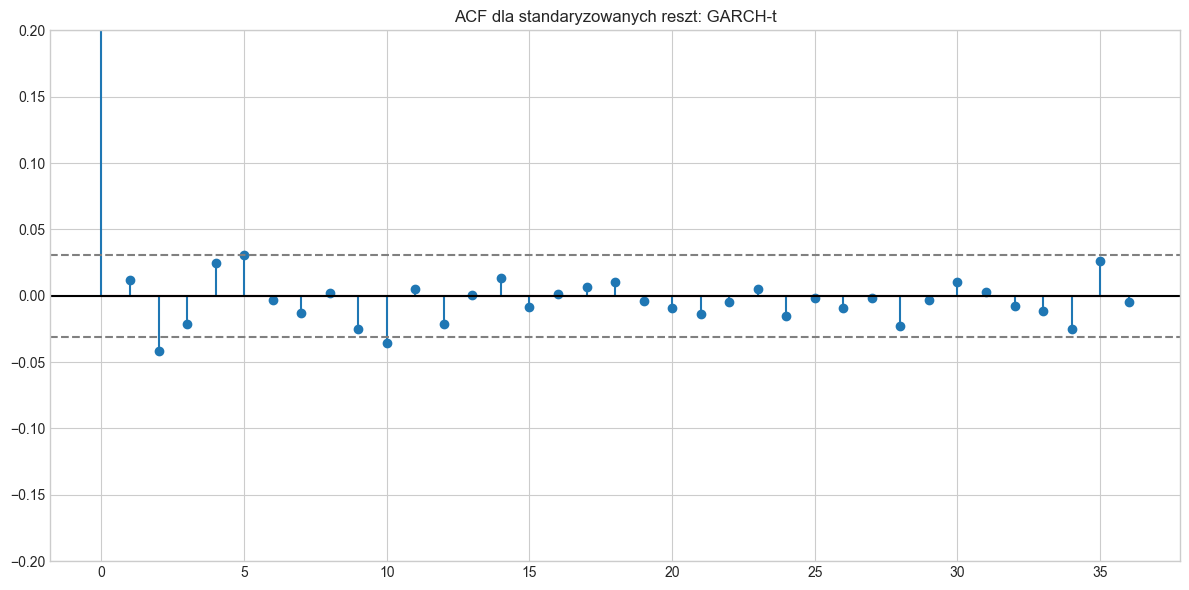

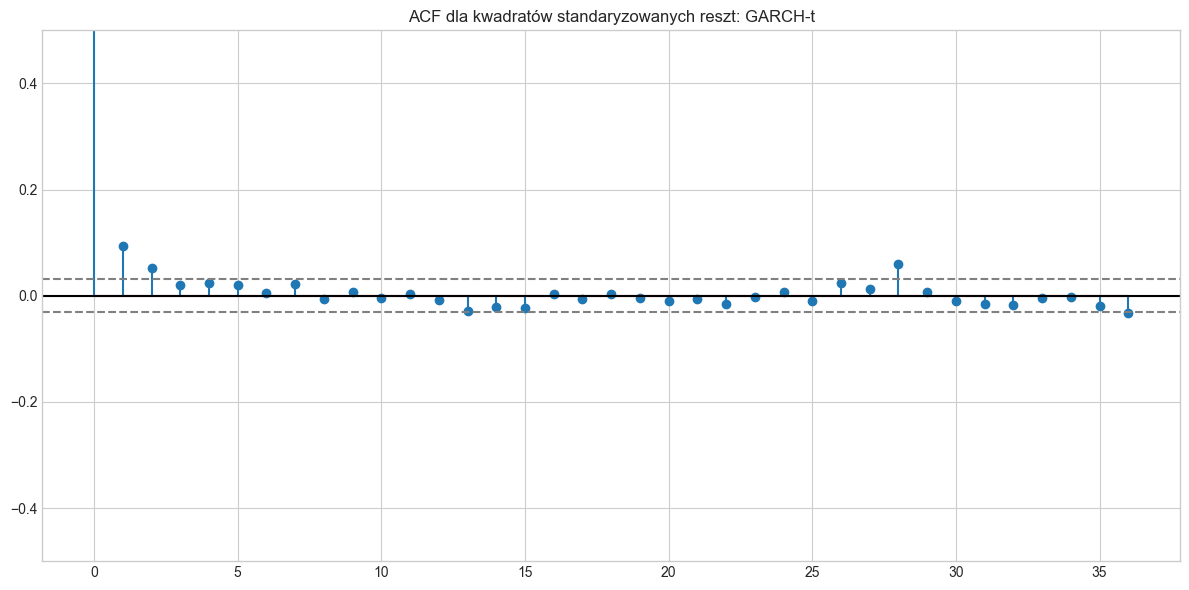


Test Ljung-Box'a dla autokorelacji standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
   lb_stat  lb_pvalue
1 0.577074   0.447461
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 24.476151   0.006432
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 27.437125   0.025370
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 28.478780   0.098541

Test Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:

Wyniki testu Ljung-Box'a (1 opóźnienie):
    lb_stat  lb_pvalue
1 35.303314   0.000000
Wyniki testu Ljung-Box'a (10 opóźnień):
     lb_stat  lb_pvalue
10 54.625999   0.000000
Wyniki testu Ljung-Box'a (15 opóźnień):
     lb_stat  lb_pvalue
15 62.445449   0.000000
Wyniki testu Ljung-Box'a (20 opóźnień):
     lb_stat  lb_pvalue
20 63.097090   0.000002


In [1138]:
# Pojawił się problem z NaN -> trzeba było wszędzie włożyć .dropna()

# --- Wykresy ACF ---

# ACF dla standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf(results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna(), nlags=36)) # standaryzacja reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.2, 0.2) 
plt.title('ACF dla standaryzowanych reszt: GARCH-t')
plt.tight_layout()
plt.show()

#  ACF dla kwadratów standaryzowanych reszt (95% CI)
plt.figure(figsize=(12, 6))
plt.stem(acf((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna())**2, nlags=36))  # standaryzacja kwadratów reszt
plt.axhline(y=0, linestyle='-', color='black')
plt.axhline(y=-1.96/np.sqrt(len(dt['r'].dropna())), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(dt['r'].dropna())), linestyle='--', color='gray')
plt.ylim(-0.5, 0.5) 
plt.title('ACF dla kwadratów standaryzowanych reszt: GARCH-t')
plt.tight_layout()
plt.show()

# --- Test Ljung-Box'a ---

# Test Ljung-Box'a dla autokorelacji standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna()), lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna()), lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna()), lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna()), lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)


# Test Ljung-Box'a dla autokorelacji kwadratów standarzyowanych reszt
print("\nTest Ljung-Box'a dla autokorelacji kwadratów standaryzowanych reszt:")
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna())**2, lags=[1], return_df=True)
print("\nWyniki testu Ljung-Box'a (1 opóźnienie):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna())**2, lags=[10], return_df=True)
print("Wyniki testu Ljung-Box'a (10 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna())**2, lags=[15], return_df=True)
print("Wyniki testu Ljung-Box'a (15 opóźnień):")
print(ljung_box_results)
ljung_box_results = acorr_ljungbox((results_forecast_garcht22.resid.dropna() / results_forecast_garcht22.conditional_volatility.dropna())**2, lags=[20], return_df=True)
print("Wyniki testu Ljung-Box'a (20 opóźnień):")
print(ljung_box_results)

Model wygląda nieidealnie z diagnostycznego punktu widzenia, ale nie chcemy też dojść do sytuacji, w której robimy *overfitting*. Wybraliśmy ten model w procesie ocen prognoz out-of-sample, więc przy nim zostajemy. Wyniki tego modelu też nie są katastrofalnie złe. Przykładowo, suma parametrów nadal jest poniżej 1. Przejdźmy do prognozy

W naszej prognozie zakładamy 252 rok roboczy. Przygotowanie do prognozy:

In [1139]:
# --- 252-dniowa prognoza zmienności ---
horizon = 252
forecasts = results_forecast_garcht22.forecast(
    horizon=horizon,
    reindex=False,      # żeby nie przeindeksowywać po dacie
    method='analytic'   # dla GARCH-t wystarczy analitycznie
)

# ostatni wiersz = prognozy z końca próby
sigma_forecast = np.sqrt(forecasts.variance.iloc[-1].values)  # array długości 252

In [1140]:
sigma_forecast

array([0.002093, 0.002126, 0.002175, 0.002214, 0.002256, 0.002294,
       0.002333, 0.002369, 0.002405, 0.00244 , 0.002474, 0.002507,
       0.00254 , 0.002571, 0.002602, 0.002631, 0.002661, 0.002689,
       0.002717, 0.002744, 0.00277 , 0.002796, 0.002822, 0.002846,
       0.00287 , 0.002894, 0.002917, 0.00294 , 0.002962, 0.002984,
       0.003005, 0.003026, 0.003047, 0.003067, 0.003086, 0.003106,
       0.003124, 0.003143, 0.003161, 0.003179, 0.003197, 0.003214,
       0.003231, 0.003247, 0.003263, 0.003279, 0.003295, 0.00331 ,
       0.003325, 0.00334 , 0.003355, 0.003369, 0.003383, 0.003397,
       0.003411, 0.003424, 0.003437, 0.00345 , 0.003463, 0.003475,
       0.003487, 0.003499, 0.003511, 0.003523, 0.003534, 0.003545,
       0.003557, 0.003567, 0.003578, 0.003589, 0.003599, 0.003609,
       0.003619, 0.003629, 0.003639, 0.003648, 0.003658, 0.003667,
       0.003676, 0.003685, 0.003694, 0.003703, 0.003711, 0.00372 ,
       0.003728, 0.003736, 0.003744, 0.003752, 0.00376 , 0.003

In [1141]:
dt

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,Data_helper,rstd
Data,,,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674,2010-01-05,0.852552
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709,2010-01-06,0.162353
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023,2010-01-07,0.933791
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953,2010-01-08,-2.319278
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353,2010-01-11,-0.317456
...,...,...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317,2025-09-24,0.536779
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763,2025-09-25,0.175087
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935,2025-09-26,-0.220135


Dodajmy standaryzowane zwroty do pełnego zbioru

In [1142]:
# Standaryzowane zwroty
dt=dt.copy()
dt['rstd'] = (dt['r'] - dt['r'].mean()) / dt['r'].std()
dt

,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Kurs,r,Data_helper,rstd
Data,,,,,,,,
2010-01-05,4.070600,4.095500,4.064800,4.090100,4.090100,0.003674,2010-01-05,0.852552
2010-01-06,4.090200,4.101500,4.086800,4.093000,4.093000,0.000709,2010-01-06,0.162353
2010-01-07,4.095700,4.126700,4.089900,4.109500,4.109500,0.004023,2010-01-07,0.933791
2010-01-08,4.107900,4.115800,4.065000,4.068800,4.068800,-0.009953,2010-01-08,-2.319278
2010-01-11,4.057400,4.069400,4.040300,4.063300,4.063300,-0.001353,2010-01-11,-0.317456
...,...,...,...,...,...,...,...,...
2025-09-24,4.258900,4.270830,4.258210,4.268240,4.268240,0.002317,2025-09-24,0.536779
2025-09-25,4.268240,4.275470,4.258720,4.271500,4.271500,0.000763,2025-09-25,0.175087
2025-09-26,4.272270,4.274080,4.264140,4.267510,4.267510,-0.000935,2025-09-26,-0.220135


In [1143]:
print("Kwantyle log stóp zwrotu")
q005_empirical_dt = dt['rstd'].dropna().quantile(0.005)
print(f"0.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: {q005_empirical_dt:.4f}")

q995_empirical_dt = dt['rstd'].dropna().quantile(0.995)
print(f"99.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: {q995_empirical_dt:.4f}")


Kwantyle log stóp zwrotu
0.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: -3.0945
99.5% kwantyl empiryczny dla standaryzowanych logarytmicznych zwrotów: 3.5857


In [1144]:
# Dla porównania: rozkład t-Studenta
nu = results_forecast_garcht22.params['nu']

from scipy.stats import t
# kwantyle teoretyczne
q005  = t.ppf(0.005, df=nu)   # dolny ogon (powinien wyjść ujemny)
q995  = t.ppf(0.995, df=nu)   # górny ogon
print(q005)
print(q995)

-3.3683237203113285
3.368323720311328


Widzimy pewną różnicę pomiędzy rozkładem empirycznym i rozkładem t-Studenta - nie mamy symetrii. Skorzystajmy z empirycznych kwantyli do prognozy. Niemniej jeśli korzystamy z modelu, który zakłada dany rozkład to również uzasadnione jest wykorzystanie tego rozkładu - tak robimy przy ostatecznej prognozie w horyzoncie rocznym.

In [1156]:
VaR_005_path = sigma_forecast * q005_empirical_dt   # VaR w dolnym 0.5% ogonie
VaR_995_path = sigma_forecast * q995_empirical_dt  # „odwrotne” VaR w górnym 99.5% ogonie

In [1157]:
VaR_005_path

array([-0.006477, -0.006578, -0.00673 , -0.00685 , -0.00698 , -0.007099,
       -0.007218, -0.007332, -0.007444, -0.007552, -0.007657, -0.007759,
       -0.007859, -0.007956, -0.008051, -0.008143, -0.008233, -0.008321,
       -0.008407, -0.008491, -0.008573, -0.008653, -0.008731, -0.008808,
       -0.008883, -0.008956, -0.009028, -0.009098, -0.009167, -0.009234,
       -0.0093  , -0.009364, -0.009428, -0.00949 , -0.009551, -0.00961 ,
       -0.009669, -0.009726, -0.009782, -0.009837, -0.009892, -0.009945,
       -0.009997, -0.010048, -0.010098, -0.010148, -0.010196, -0.010244,
       -0.01029 , -0.010336, -0.010381, -0.010426, -0.010469, -0.010512,
       -0.010554, -0.010595, -0.010636, -0.010676, -0.010715, -0.010753,
       -0.010791, -0.010828, -0.010865, -0.010901, -0.010937, -0.010971,
       -0.011006, -0.011039, -0.011072, -0.011105, -0.011137, -0.011169,
       -0.0112  , -0.01123 , -0.01126 , -0.01129 , -0.011319, -0.011348,
       -0.011376, -0.011404, -0.011431, -0.011458, 

In [1158]:
VaR_995_path

array([0.007505, 0.007622, 0.007798, 0.007938, 0.008088, 0.008226,
       0.008364, 0.008496, 0.008625, 0.00875 , 0.008872, 0.008991,
       0.009107, 0.009219, 0.009329, 0.009436, 0.00954 , 0.009642,
       0.009742, 0.009839, 0.009934, 0.010026, 0.010117, 0.010206,
       0.010293, 0.010378, 0.010461, 0.010542, 0.010622, 0.0107  ,
       0.010776, 0.010851, 0.010924, 0.010996, 0.011067, 0.011136,
       0.011204, 0.01127 , 0.011335, 0.011399, 0.011462, 0.011523,
       0.011584, 0.011643, 0.011701, 0.011759, 0.011815, 0.01187 ,
       0.011924, 0.011977, 0.012029, 0.012081, 0.012131, 0.012181,
       0.012229, 0.012277, 0.012324, 0.01237 , 0.012416, 0.01246 ,
       0.012504, 0.012547, 0.01259 , 0.012632, 0.012673, 0.012713,
       0.012753, 0.012792, 0.01283 , 0.012868, 0.012905, 0.012942,
       0.012978, 0.013013, 0.013048, 0.013082, 0.013116, 0.013149,
       0.013182, 0.013214, 0.013246, 0.013277, 0.013307, 0.013338,
       0.013367, 0.013397, 0.013425, 0.013454, 0.013482, 0.013

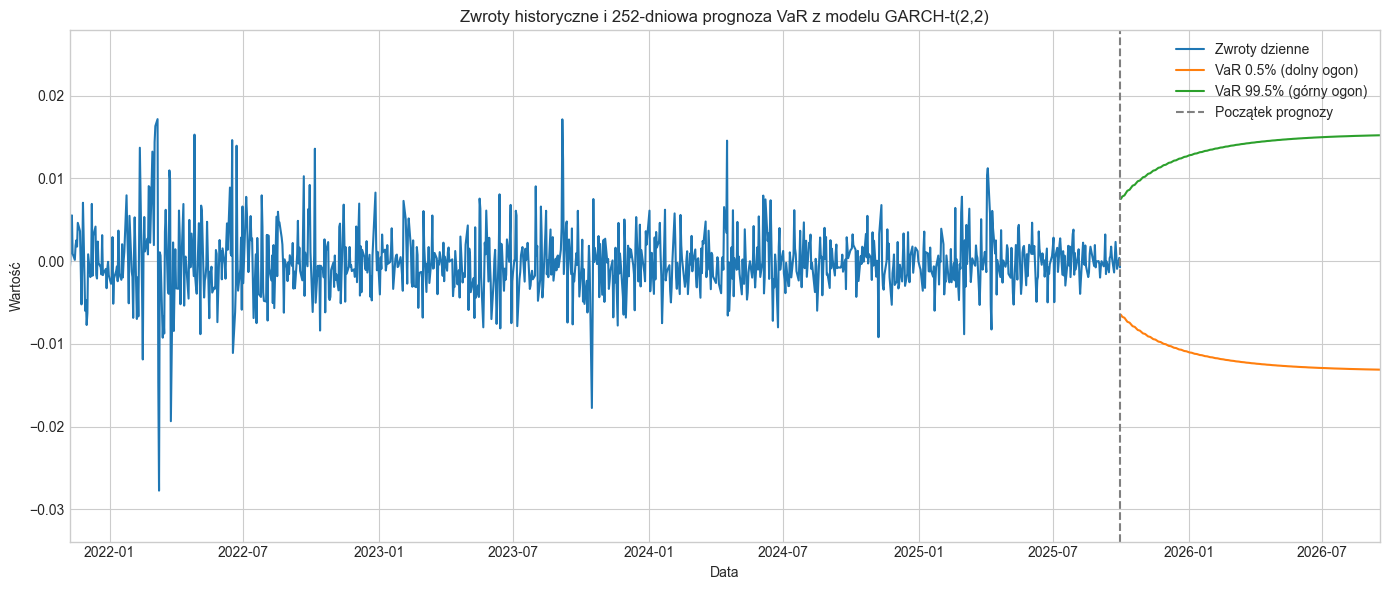

In [ ]:
# --- Przygotowanie zwrotów z datą jako indeksem ---

dt_plot = dt.copy()
dt_plot['Data_helper'] = pd.to_datetime(dt_plot['Data_helper'])   
dt_plot = dt_plot.set_index('Data_helper').sort_index()

returns = dt_plot['r'].dropna()


last_date = returns.index[-1]
forecast_index = pd.bdate_range(
    start=last_date + pd.tseries.offsets.BDay(1),
    periods=horizon,
    freq='B'
)

VaR_005_series = pd.Series(VaR_005_path, index=forecast_index)
VaR_995_series = pd.Series(VaR_995_path, index=forecast_index)

# --- Wykres: historyczne zwroty + prognoza VaR ---

plt.figure(figsize=(14, 6))

plt.plot(returns.index, returns.values, label='Zwroty dzienne')
plt.plot(VaR_005_series.index, VaR_005_series.values, label='VaR 0.5% (dolny ogon)')
plt.plot(VaR_995_series.index, VaR_995_series.values, label='VaR 99.5% (górny ogon)')

plt.axvline(x=last_date, linestyle='--', color='gray', label='Początek prognozy')

plt.xlabel('Data')
plt.ylabel('Wartość')
plt.title('Zwroty historyczne i 252-dniowa prognoza VaR z modelu GARCH-t(2,2)')
plt.legend()
plt.tight_layout()

# Widoczne daty
history_days = 252*4
start_plot = returns.index[-history_days]
end_plot   = VaR_005_series.index[-1]
plt.xlim(start_plot, end_plot)

plt.show()

Widzimy, że prognozy szybko się wypłaszczają, co jest typowym zachowaniem modeli klasy ARIMA/GARCH. Warunkowa wariancja szybko zbiega do bezwarunkowej wariancji. Zatem płaskość, którą obserwujemy od około 2026-07 jest charakterystyczna dla modelu.

## 4.1 Prognoza w horyzoncie rocznym

To są prognozy dziennych $VaR$ natomiast, żeby odpowiedzieć jaka jest maksymalna strata (zysk) w horyzoncie rocznym musimy spojrzeć na roczną logarytmiczną stopę zwrotu - obecnie operowaliśmy na dziennych. Dzięki addytywności logarytmicznych stóp zwrotu wystarczy, że dokonamy takiego przekształcenia (zakładając 252-dniowy rok roboczy):
$$ R^{1Y} = r^d_{t+1} + ... + r^d_{t+252}$$

Nie mamy oczywiście dostępu do zwrotów w przyszłości, ale możemy je wysymulować na podstawie naszego modelu GARCH-t korzystając z symulacji Monte Carlo. Intuicyjnie polega to na tym, że symulujemy zadaną liczbę ścieżek (np. 10000) dniowych zwrotów przez rok (252 dni - 252 zwroty). Wykorzystujemy do tego nasz model GARCH w następujący sposób:

> Warunkowa wariancja:
$$ h_t = \omega + \alpha_1 e^2_{t-1} +\alpha_2 e^2_{t-2} + \beta_1 h_{t-1} + \beta_2h_{t-2}$$

> Reszty:
$$ e_t = \sigma_t z_t, \sigma_t = \sqrt{h_t}, z_t \sim t_\nu (standaryzowany)$$

> Przy mean='zero' (równanie średniej równe 0):
$$ r_t = e_t $$

Dzięki takiej symulacji tworzymy:
* tworzymy ścieżki dniowych zwrotów (przez rok)
* agregujemy je do zwrotu rocznego
* na podstawie wszystkich zwrotów rocznych wyznaczamy $VaR$





Przykładowe, które korzystają z takiego bądź podobnego podejścia:

* [A Monte Carlo Simulation Approach to Forecasting Multi-period Value-at-Risk and Expected Shortfall Using the FIGARCH-skT Specification](https://mpra.ub.uni-muenchen.de/80431/1/MPRA_paper_80431.pdf)
* [A Sequential Importance Sampling for Estimating Multi-Period Tail Risk](https://www.mdpi.com/2227-9091/12/12/201?utm)
* [Fitting and Predicting VaR based on an ARMA-GARCH Process](https://cran.r-project.org/web/packages/qrmtools/vignettes/ARMA_GARCH_VaR.html)
* [Market Risk Analysis Volume II](https://pdfs.semanticscholar.org/159a/c49d31ebb0e594e993935a463c42c97874e6.pdf?utm.com)

In [1162]:
# --- Parametry i ustawienia symulacji ---
horizon = 252        # liczba dni w roku roboczym
n_paths = 10000      # liczba ścieżek Monte Carlo

# Paremetry z wybranego przez nas modelu
params = results_forecast_garcht22.params
omega = params['omega']
alpha1 = params['alpha[1]']
alpha2 = params['alpha[2]']
beta1  = params['beta[1]']
beta2  = params['beta[2]']
nu     = params['nu']

# Ostatnie historyczne warunkowe wariancje i reszty
cond_vol = results_forecast_garcht22.conditional_volatility.dropna()
eps_hist = results_forecast_garcht22.resid.dropna()

h_t_1 = cond_vol.iloc[-1]**2
h_t_2 = cond_vol.iloc[-2]**2
e_t_1 = eps_hist.iloc[-1]
e_t_2 = eps_hist.iloc[-2]

# standaryzowany t-Studenta o wariancji 1:
# scipy.stats.t ma var = nu/(nu-2), więc przeskalujemy
from scipy.stats import t as student_t
scale_std = np.sqrt(nu / (nu - 2.0))

# --- Symulacja ścieżek ---

R_1Y = np.zeros(n_paths)

for i in range(n_paths):
    h1 = h_t_1
    h2 = h_t_2
    e1 = e_t_1
    e2 = e_t_2
    r_sum = 0.0

    for _ in range(horizon):
        z = student_t.rvs(df=nu) / scale_std   # z ma var=1
        h = omega + alpha1 * e1**2 + alpha2 * e2**2 + beta1 * h1 + beta2 * h2
        sigma = np.sqrt(h)
        e = sigma * z      # ponieważ mean='zero', r_t = e_t
        r_sum += e

        # przesuwamy indeksy do przodu
        h2, h1 = h1, h
        e2, e1 = e1, e

    R_1Y[i] = r_sum

# --- Roczny VaR 0.5% i 99.5% ---
VaR_1Y_005 = np.quantile(R_1Y, 0.005)   # strata (dodatnia liczba)
VaR_1Y_995 = np.quantile(R_1Y, 0.995)   # "VaR" dla górnego ogona (zysk)

print("Roczny VaR 0.5% :", VaR_1Y_005)
print("Roczny VaR 99.5%:", VaR_1Y_995)


Roczny VaR 0.5% : -0.1723406617020411
Roczny VaR 99.5%: 0.17954721018325723


Mamy zatem ostateczne wyniki. Podczas naszego testowania wartości tych kwantyli odbiegały o $\pm$ 0.01 - niemniej nie sprawdzaliśmy formalnie stabilnosći wyników. Przeważnie 10 000 symulacji powinno dawać dobre oszacowania.

> Nasze wyniki:

$$ 
VaR^{1Y}_{0.5\%} = -0.17234
$$

$$ 
VaR^{1Y}_{99.5\%} = 0.17955
$$

> Zatem log stopa zwrotu kursu EUR/PLN z prawdopodobieństwem 99.5% nie powinna spaść poniżej -0.17234 w ciągu roku oraz z prawdopodobieństwem 99.5% nie powinna wzrosnąć powyżej 0.17955 w ciągu roku. 

Wyniki są stosunkowo symetryczne w pewnej mierze na pewno poprzez przyjęcie rozkładu t-Studenta w symulacjach, który zakładamy w modelu. Wcześniej pokazaliśmy, że empiryczne kwantyle są mniej symetryczne. Jest to na pewno założenie, które w jakimś stopniu wpływa na wyniki modelu.

Ostatecznie należy też przypomnieć czemu kluczowe jest estymowanie dwóch kwantyli. W przypadku kursu walutowego (u nas kwotowanie bezpośrednie) możemy mieć do czynienia ze spadkiem lub wzrostem. Wzrost kursu oznacza deprecjację złotego względem euro. Zobowiązania stają się droższe, ale aktywa w euro rosną w wartości. Z kolei spadek kursu oznacza aprecjację złotego względem euro. Zobowiązania stają się tańsze, ale aktywa w euro tracą na wartości. Estymujemy oba kwantyle, żeby mieć dane do kwantyfikowania efektów zmiany stopy zwrotu z kursu biorąc pod uwagę nasz portfel w walucie zagranicznej. Jest to kluczowe dla firm przy zarządzaniu zobowiązaniami i aktywami.

# 5. Ograniczenia badania

Staraliśmy się zaznaczać ograniczenia badania w trakcie badania niemniej na końcu podsumujemy najważniejsze aspekty, które mogły wpłynąć na jakość wyników:

* **Wybór modeli GARCH nie był wyczerpujący.** Rozszerzeń GARCH są setki a my sprawdziliśmy tylko kilka typów. Należałoby rozszerzyć horyzont szczególnie w zakresie badań korzystających z GARCH i VaR przy analizie kursów walutowych.
* **Diagnostyka modeli nie była wyczerpująca.** Nie przeprowadzaliśmy, przykładowo, *Nyblom stability test ,Sign Bias test , Adjusted Pearson Goodness-of-Fit test* 
* **Problemy ze zbieżnością były ogromnym problemem w wyborze modelu i przeprowadzaniu prognoz**. Tutaj potencjalnie należało lepiej zbadać dane pod kątem takich problemów czy spróbować manualnie zmienić biblioteki statystyczne, z których korzystaliśmy. Posiłkowaliśmy się dokumentacją, ale nie próbowaliśmy ingerować w kod z bibliotek.
* **Przeprowadziliśmy tylko jedną technikę prognozy - rolling-window**. W celu zmierzenia stabilności naszych wyników należałoby spróbować innych metod i bardziej rozbudować przeprowadzony *cross-validation*.
* **W ocenie modeli korzystaliśmy tylko z jednej metryki - liczby przekroczeń.** Przeważnie repertuar różych funkcji straty w takich badaniach jest większy, żeby zapewnić, że jedna metryka nie jest silnie obciążona. Nie uwzględniliśmy również przedziałów ufności dla prognoz.
* **Korzystaliśmy z metod symulacyjnych przy wyznaczeniu ostatecznych wyników**. Wiele zależy od specyfikacji modelu, procesu symulacji i danych w takim podejściu. Te kwestie mogą potęgować ewentualne błędy.